# Analysis of Functional Connectivity in Line Attractor

By Charles Xu @ Caltech, 2025

## Cell-coupled GLM

### Individual distributions

In [1]:
import os
import numpy as np
from collections import OrderedDict

connectivity_dir = '/home/charlesxu/local/data/JK_functionalConn/connectivity_matrices_glm_pos_and_neg_coef/connectivity_matrices'

# Load the connectivity matrices for the fed state
connectivity_matrices_fed = {}
for file_name in os.listdir(os.path.join(connectivity_dir, 'fed')):
    if file_name.endswith('.npy'):
        matrix_name = os.path.splitext(file_name)[0]
        matrix_key = '_'.join(matrix_name.split('_')[-4:-2])
        file_path = os.path.join(connectivity_dir, 'fed', file_name)
        connectivity_matrices_fed[matrix_key] = np.load(file_path)

# Sort the dictionary by the key
sorted_keys = sorted(connectivity_matrices_fed.keys(), key=lambda x: int(x.split('_')[0][1:]))
connectivity_matrices_fed = OrderedDict((key, connectivity_matrices_fed[key]) for key in sorted_keys)

# Load the connectivity matrices for the fasted state
connectivity_matrices_fasted = {}
for file_name in os.listdir(os.path.join(connectivity_dir, 'fasted')):
    if file_name.endswith('.npy'):
        matrix_name = os.path.splitext(file_name)[0]
        matrix_key = '_'.join(matrix_name.split('_')[-4:-2])
        file_path = os.path.join(connectivity_dir, 'fasted', file_name)
        connectivity_matrices_fasted[matrix_key] = np.load(file_path)

# Sort the dictionary by the key
sorted_keys = sorted(connectivity_matrices_fasted.keys(), key=lambda x: int(x.split('_')[0][1:]))
connectivity_matrices_fasted = OrderedDict((key, connectivity_matrices_fasted[key]) for key in sorted_keys)

#### Histograms and fitted PDFs

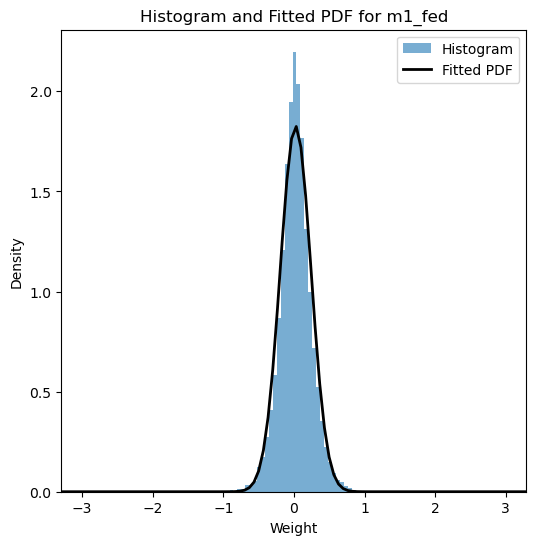

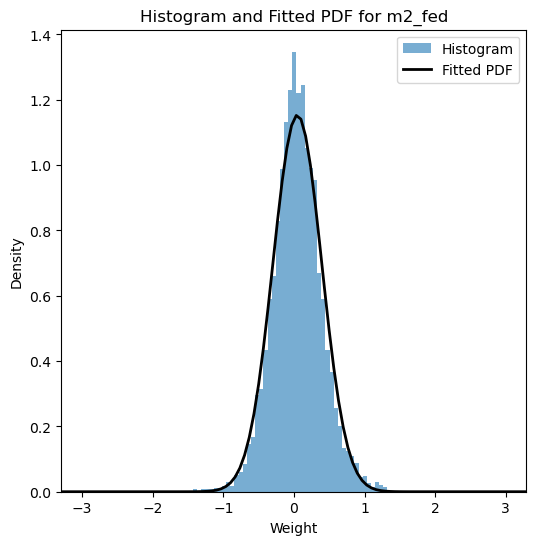

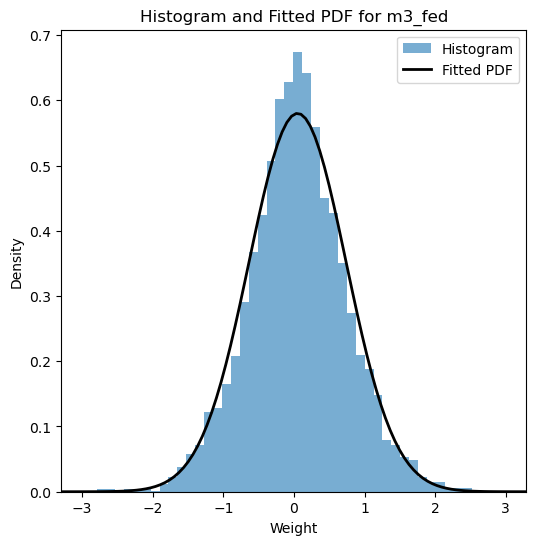

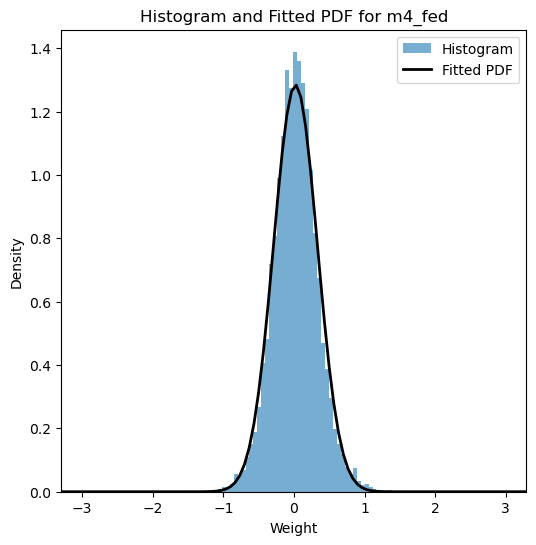

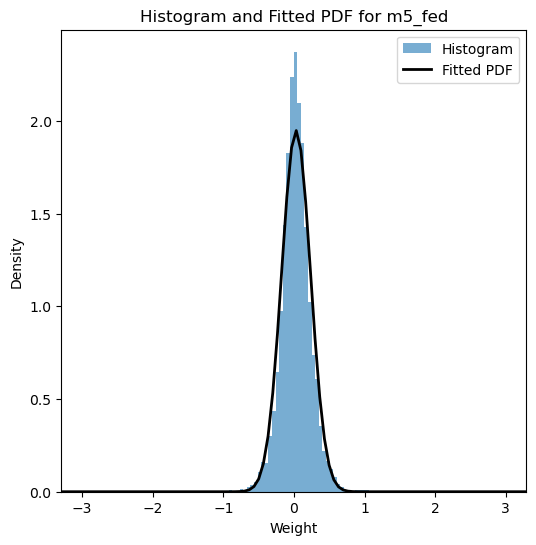

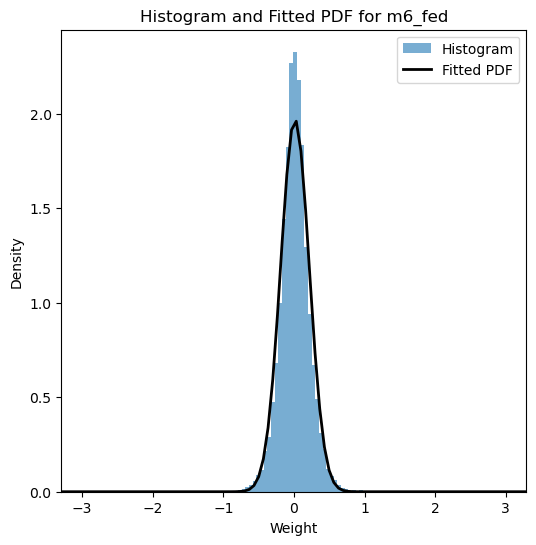

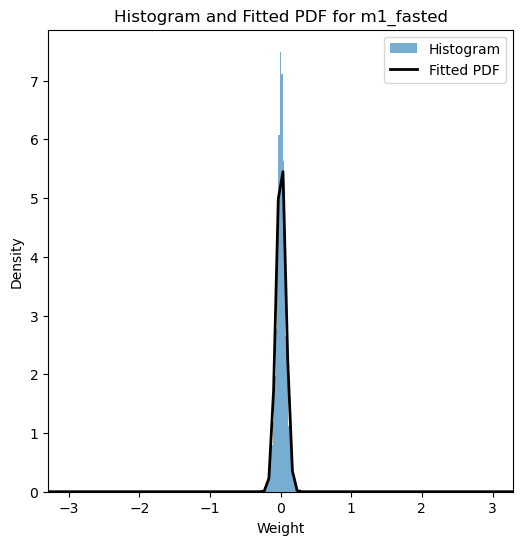

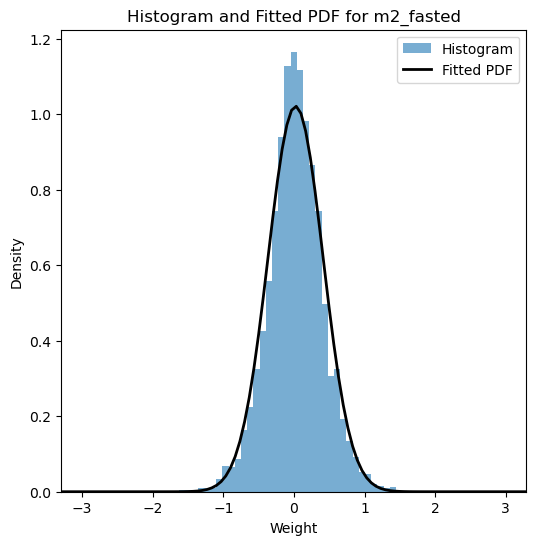

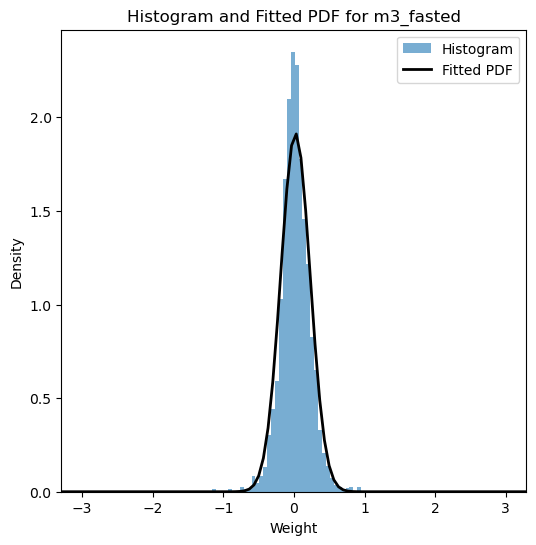

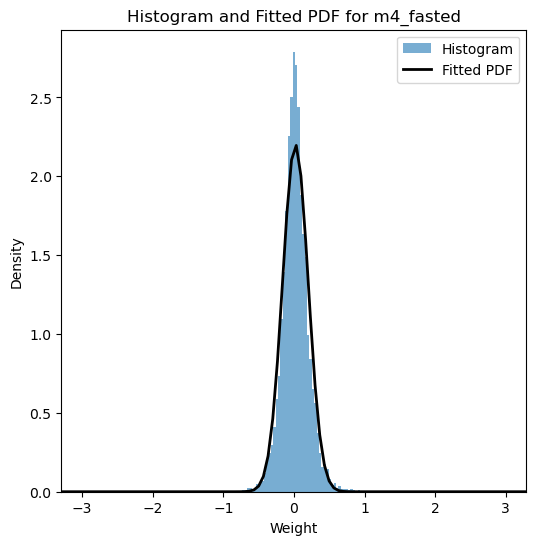

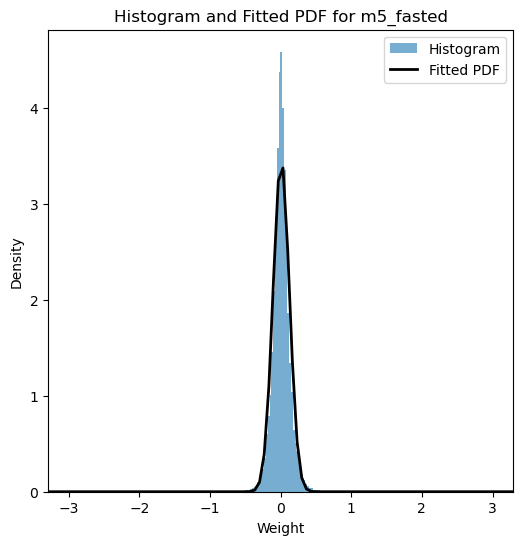

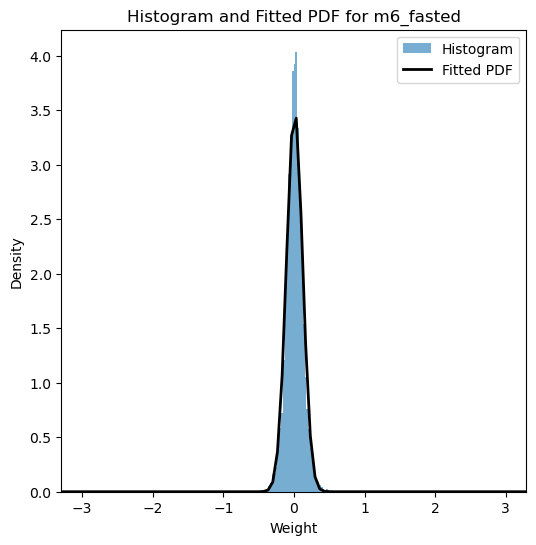

In [2]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Calculate global x-limits
all_weights = np.concatenate([matrix.flatten() for matrix in connectivity_matrices_fed.values()] + 
                             [matrix.flatten() for matrix in connectivity_matrices_fasted.values()])
all_weights = all_weights[all_weights != 0]  # Remove zero weights
global_xmin, global_xmax = min(all_weights), max(all_weights)

# Center the x-axis to zero
global_xmax = max(abs(global_xmin), global_xmax)
global_xmin = -global_xmax

fitted_params_fed = {}
for key, matrix in connectivity_matrices_fed.items():
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization
    
    # Fit a normal distribution to the data
    params = norm.fit(weights)
    fitted_params_fed[key] = (params)
    x = np.linspace(global_xmin, global_xmax, 100)
    p = norm.pdf(x, *params)

    # Plot the histogram and fitted PDF
    plt.figure(figsize=(6, 6))
    plt.hist(weights, bins=50, density=True, alpha=0.6, label='Histogram')
    plt.plot(x, p, 'k', linewidth=2, label='Fitted PDF')
    plt.title(f'Histogram and Fitted PDF for {key}')
    plt.xlabel('Weight')
    plt.ylabel('Density')
    plt.xlim(global_xmin, global_xmax)
    plt.legend()
    plt.show()

fitted_params_fasted = {}
for key, matrix in connectivity_matrices_fasted.items():
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization
    
    # Fit a normal distribution to the data
    params = norm.fit(weights)
    fitted_params_fasted[key] = (params)
    x = np.linspace(global_xmin, global_xmax, 100)
    p = norm.pdf(x, *params)

    # Plot the histogram and fitted PDF
    plt.figure(figsize=(6, 6))
    plt.hist(weights, bins=50, density=True, alpha=0.6, label='Histogram')
    plt.plot(x, p, 'k', linewidth=2, label='Fitted PDF')
    plt.title(f'Histogram and Fitted PDF for {key}')
    plt.xlabel('Weight')
    plt.ylabel('Density')
    plt.xlim(global_xmin, global_xmax)
    plt.legend()
    plt.show()


#### PDFs

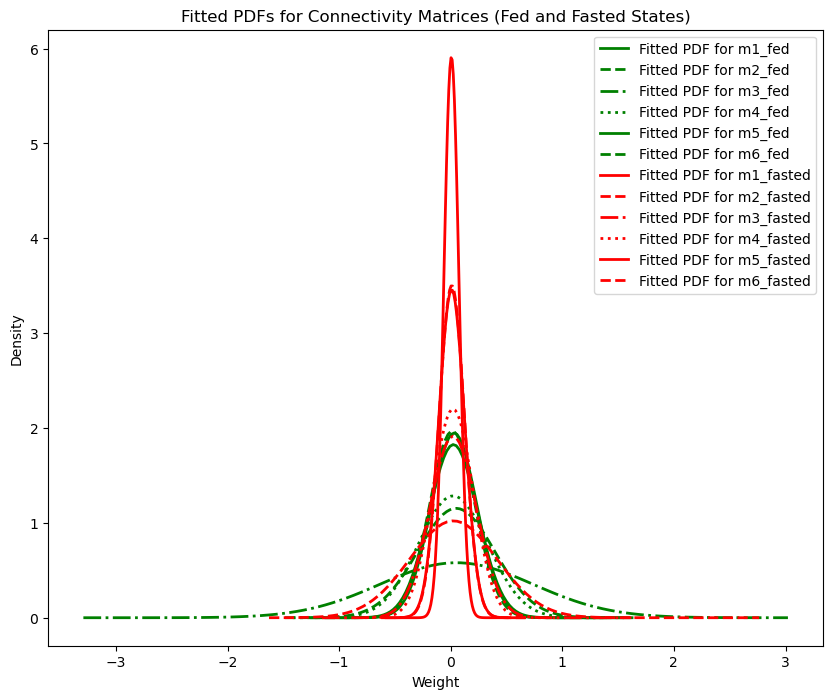

{'m1_fed': (0.02426994642202242, 0.21849315855130927), 'm2_fed': (0.04867144391278663, 0.3459482374859659), 'm3_fed': (0.051784573171178135, 0.6878075748957259), 'm4_fed': (0.021917954082474378, 0.3105792270316971), 'm5_fed': (0.030671735478353352, 0.20483035354319087), 'm6_fed': (0.014547281178154379, 0.2026622735744687)}
{'m1_fasted': (0.006042733278045615, 0.06748648412430394), 'm2_fasted': (0.023606021919420586, 0.3906777520361781), 'm3_fasted': (0.02145858764065402, 0.20843576751529963), 'm4_fasted': (0.02087795868057693, 0.1812781435968035), 'm5_fasted': (0.008141846128558047, 0.11537711079445956), 'm6_fasted': (0.009210998271243635, 0.11387344055230549)}


In [3]:
# Define line styles for different PDFs
line_styles = ['-', '--', '-.', ':', '-', '--']

# Initialize a figure for the plot
plt.figure(figsize=(10, 8))

# Iterate over each connectivity matrix in connectivity_matrices_fed
for i, (key, matrix) in enumerate(connectivity_matrices_fed.items()):
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization
    
    # Use the stored parameters to generate the PDF
    params = fitted_params_fed[key]
    
    # Generate the x values for the PDF
    xmin, xmax = min(weights), max(weights)
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, *params)

    # Plot the PDF in green
    plt.plot(x, p, line_styles[i % len(line_styles)], color='g', linewidth=2, label=f'Fitted PDF for {key}')

# Iterate over each connectivity matrix in connectivity_matrices_fasted
for i, (key, matrix) in enumerate(connectivity_matrices_fasted.items()):
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization
    
    # Use the stored parameters to generate the PDF
    params = fitted_params_fasted[key]
    
    # Generate the x values for the PDF
    xmin, xmax = min(weights), max(weights)
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, *params)
    
    # Plot the PDF in red
    plt.plot(x, p, line_styles[i % len(line_styles)], color='r', linewidth=2, label=f'Fitted PDF for {key}')

# Add title and labels
plt.title('Fitted PDFs for Connectivity Matrices (Fed and Fasted States)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()
plt.show()

# Print the fitted parameters
print(fitted_params_fed)
print(fitted_params_fasted)

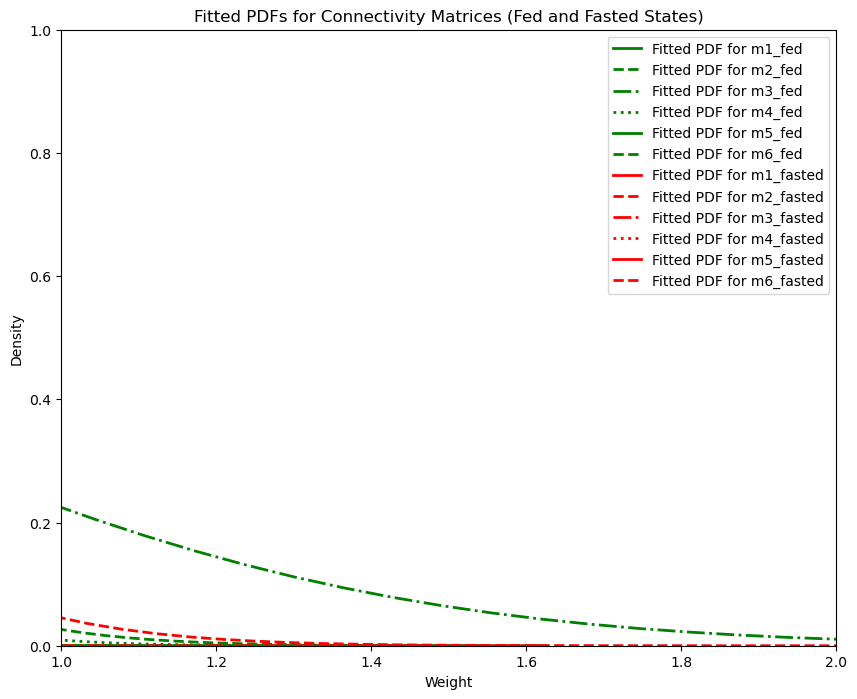

In [4]:
# Initialize a figure for the plot
plt.figure(figsize=(10, 8))

# Iterate over each connectivity matrix in connectivity_matrices_fed
for i, (key, matrix) in enumerate(connectivity_matrices_fed.items()):
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization
    
    # Use the stored parameters to generate the PDF
    params = fitted_params_fed[key]

    # Generate the x values for the PDF
    xmin, xmax = min(weights), max(weights)
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, *params)

    # Plot the PDF in green
    plt.plot(x, p, line_styles[i % len(line_styles)], color='g', linewidth=2, label=f'Fitted PDF for {key}')

# Iterate over each connectivity matrix in connectivity_matrices_fasted
for i, (key, matrix) in enumerate(connectivity_matrices_fasted.items()):
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization
    
    # Use the stored parameters to generate the PDF
    params = fitted_params_fasted[key]
    
    # Generate the x values for the PDF
    xmin, xmax = min(weights), max(weights)
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, *params)
    
    # Plot the PDF in red
    plt.plot(x, p, line_styles[i % len(line_styles)], color='r', linewidth=2, label=f'Fitted PDF for {key}')

# Add title and labels
plt.title('Fitted PDFs for Connectivity Matrices (Fed and Fasted States)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()

# Set the x and y limits to zoom in
plt.xlim(1, 2)
plt.ylim(0, 1)

plt.show()

### Distribution by condition

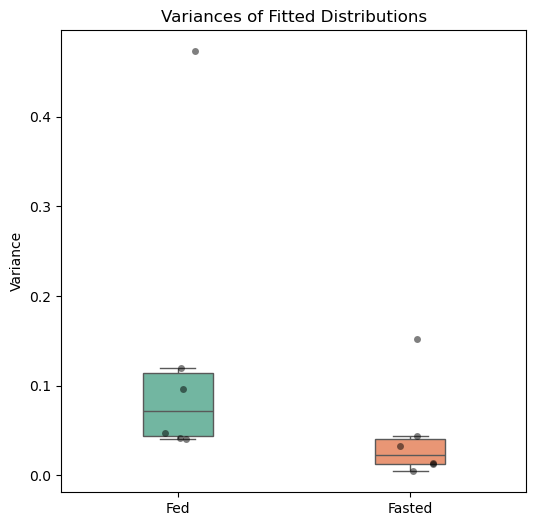

In [5]:
import seaborn as sns

# Extract the variances from the fitted parameters
variances_fed = [std**2 for _, std in fitted_params_fed.values()]
variances_fasted = [std**2 for _, std in fitted_params_fasted.values()]

# Create a box plot
plt.figure(figsize=(6, 6))
sns.boxplot(data=[variances_fed, variances_fasted], palette="Set2", showfliers=False, width=0.3)
sns.stripplot(data=[variances_fed, variances_fasted], color='black', alpha=0.5)
plt.xticks([0, 1], ['Fed', 'Fasted'])
plt.title('Variances of Fitted Distributions')
plt.ylabel('Variance')
plt.show()

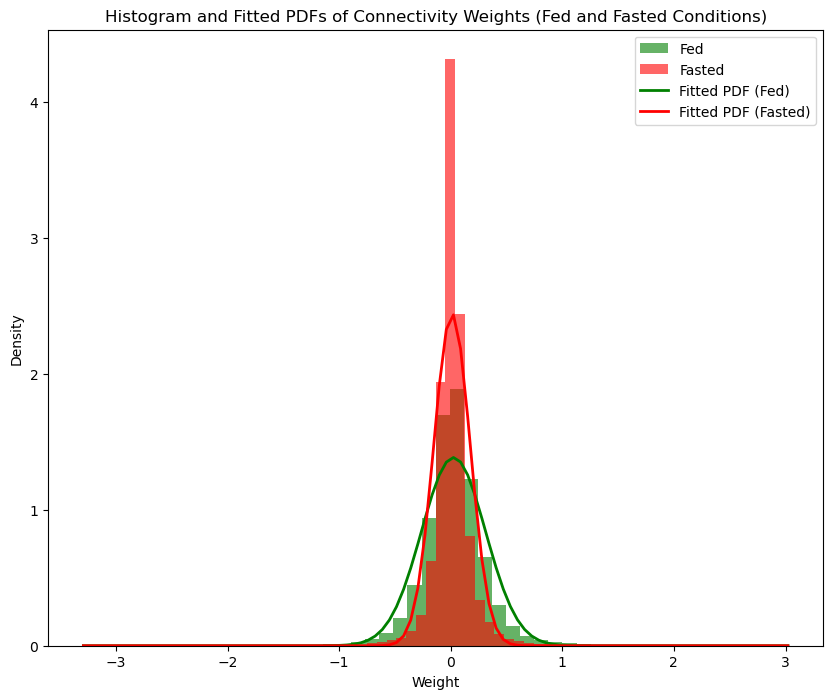

In [6]:
# Aggregate the connectivity weights for fed and fasted conditions
weights_fed = np.concatenate([matrix.flatten() for matrix in connectivity_matrices_fed.values()])
weights_fed = weights_fed[weights_fed != 0]  # Remove zero weights

weights_fasted = np.concatenate([matrix.flatten() for matrix in connectivity_matrices_fasted.values()])
weights_fasted = weights_fasted[weights_fasted != 0]  # Remove zero weights

# Fit a normal distribution to the data
mu_fed, std_fed = norm.fit(weights_fed)
mu_fasted, std_fasted = norm.fit(weights_fasted)

# Generate the x values for the PDF
xmin, xmax = min(min(weights_fed), min(weights_fasted)), max(max(weights_fed), max(weights_fasted))
x = np.linspace(xmin, xmax, 100)
p_fed = norm.pdf(x, mu_fed, std_fed)
p_fasted = norm.pdf(x, mu_fasted, std_fasted)

# Plot histograms for both conditions
plt.figure(figsize=(10, 8))
plt.hist(weights_fed, bins=50, density=True, alpha=0.6, color='g', label='Fed')
plt.hist(weights_fasted, bins=50, density=True, alpha=0.6, color='r', label='Fasted')

# Plot the fitted PDFs
plt.plot(x, p_fed, 'g', linewidth=2, label='Fitted PDF (Fed)')
plt.plot(x, p_fasted, 'r', linewidth=2, label='Fitted PDF (Fasted)')

# Add title and labels
plt.title('Histogram and Fitted PDFs of Connectivity Weights (Fed and Fasted Conditions)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()
plt.show()

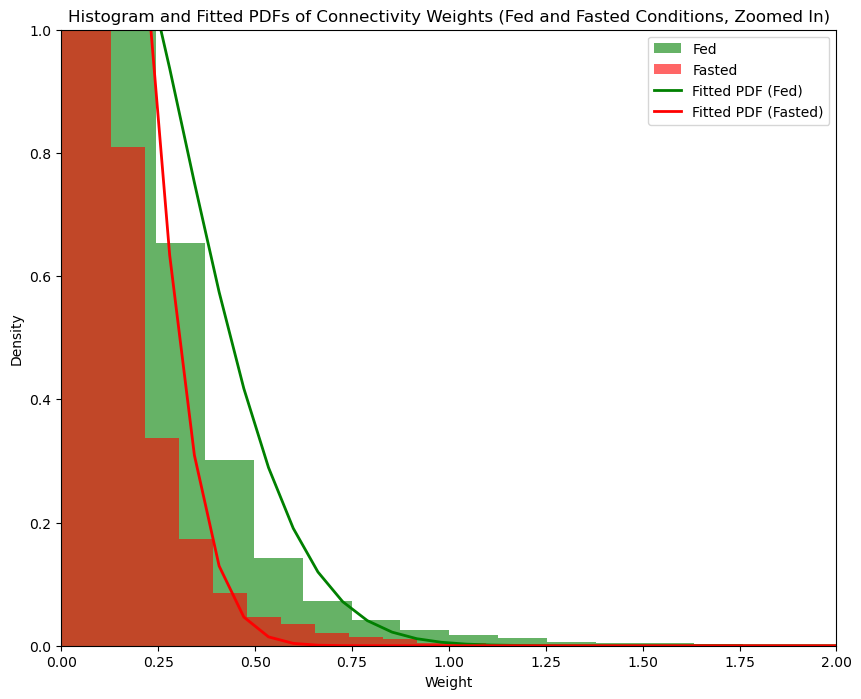

In [7]:
# Plot histograms for both conditions
plt.figure(figsize=(10, 8))
plt.hist(weights_fed, bins=50, density=True, alpha=0.6, color='g', label='Fed')
plt.hist(weights_fasted, bins=50, density=True, alpha=0.6, color='r', label='Fasted')

# Plot the fitted PDFs
plt.plot(x, p_fed, 'g', linewidth=2, label='Fitted PDF (Fed)')
plt.plot(x, p_fasted, 'r', linewidth=2, label='Fitted PDF (Fasted)')

# Add title and labels
plt.title('Histogram and Fitted PDFs of Connectivity Weights (Fed and Fasted Conditions, Zoomed In)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()

# Set the x and y limits to zoom in
plt.xlim(0, 2)
plt.ylim(0, 1)

plt.show()

### Connectivity

In [8]:
# Show the sizes of the connectivity matrices for the fed state
for key, matrix in connectivity_matrices_fed.items():
    print(f'Size of {key}: {matrix.shape}')

# Show the sizes of the connectivity matrices for the fasted state
for key, matrix in connectivity_matrices_fasted.items():
    print(f'Size of {key}: {matrix.shape}')

Size of m1_fed: (155, 155)
Size of m2_fed: (69, 69)
Size of m3_fed: (68, 68)
Size of m4_fed: (97, 97)
Size of m5_fed: (84, 84)
Size of m6_fed: (152, 152)
Size of m1_fasted: (144, 144)
Size of m2_fasted: (73, 73)
Size of m3_fasted: (54, 54)
Size of m4_fasted: (84, 84)
Size of m5_fasted: (97, 97)
Size of m6_fasted: (114, 114)


In [9]:
def is_diagonalizable(matrix):
    """
    A matrix is diagonalizable if the sum of the geometric multiplicities 
    of its eigenvalues equals the size of the matrix (full set of linearly independent eigenvectors).
    """
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    rank = np.linalg.matrix_rank(eigenvectors)
    return rank == matrix.shape[0]

# Check diagonalizability for each connectivity matrix in the fed state
diagonalizable_fed = {}
for key, matrix in connectivity_matrices_fed.items():
    diagonalizable_fed[key] = is_diagonalizable(matrix)
    print(f'{key} is diagonalizable: {diagonalizable_fed[key]}')

# Check diagonalizability for each connectivity matrix in the fasted state
diagonalizable_fasted = {}
for key, matrix in connectivity_matrices_fasted.items():
    diagonalizable_fasted[key] = is_diagonalizable(matrix)
    print(f'{key} is diagonalizable: {diagonalizable_fasted[key]}')

m1_fed is diagonalizable: True
m2_fed is diagonalizable: True
m3_fed is diagonalizable: True
m4_fed is diagonalizable: True
m5_fed is diagonalizable: True
m6_fed is diagonalizable: True
m1_fasted is diagonalizable: True
m2_fasted is diagonalizable: True
m3_fasted is diagonalizable: True
m4_fasted is diagonalizable: True
m5_fasted is diagonalizable: True
m6_fasted is diagonalizable: True


In [10]:
def is_normal_matrix(matrix):
    """
    Check if a matrix is a normal matrix.
    A matrix A is normal if A * A^H = A^H * A, where A^H is the conjugate transpose of A.
    """
    return np.allclose(matrix @ matrix.T.conj(), matrix.T.conj() @ matrix)

# Check normality for each connectivity matrix in the fed state
normal_matrices_fed = {}
for key, matrix in connectivity_matrices_fed.items():
    normal_matrices_fed[key] = is_normal_matrix(matrix)
    print(f'{key} is a normal matrix: {normal_matrices_fed[key]}')

# Check normality for each connectivity matrix in the fasted state
normal_matrices_fasted = {}
for key, matrix in connectivity_matrices_fasted.items():
    normal_matrices_fasted[key] = is_normal_matrix(matrix)
    print(f'{key} is a normal matrix: {normal_matrices_fasted[key]}')

m1_fed is a normal matrix: False
m2_fed is a normal matrix: False
m3_fed is a normal matrix: False
m4_fed is a normal matrix: False
m5_fed is a normal matrix: False
m6_fed is a normal matrix: False
m1_fasted is a normal matrix: False
m2_fasted is a normal matrix: False
m3_fasted is a normal matrix: False
m4_fasted is a normal matrix: False
m5_fasted is a normal matrix: False
m6_fasted is a normal matrix: False


#### Eigendecomposition

/home/charlesxu/anaconda3/envs/neuraldynamics/lib/python3.9/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/charlesxu/anaconda3/envs/neuraldynamics/lib/python3.9/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


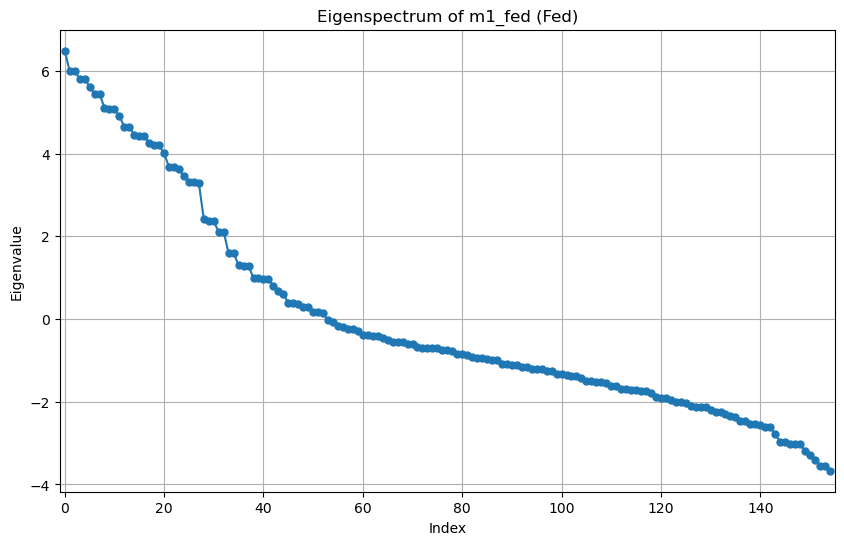

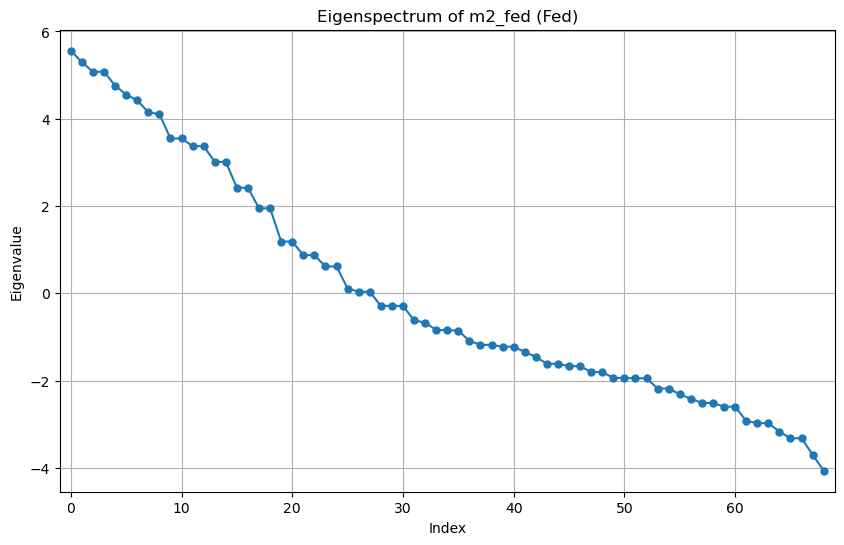

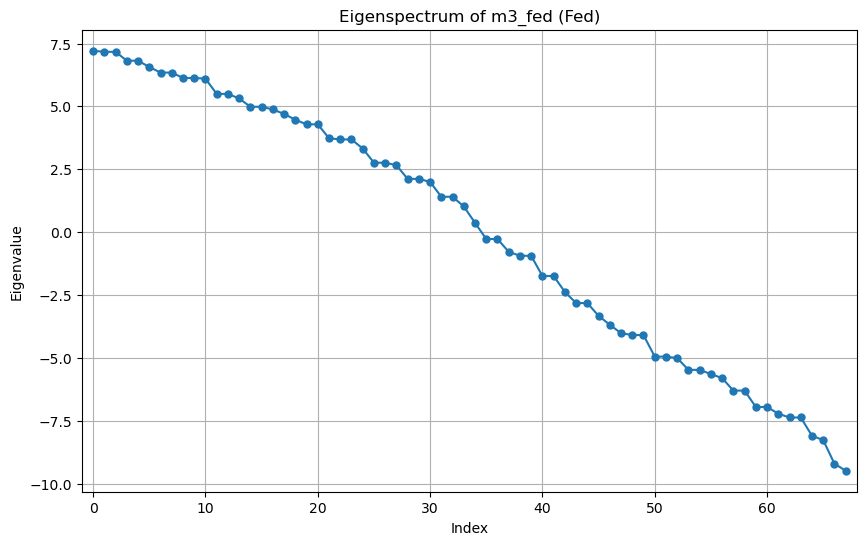

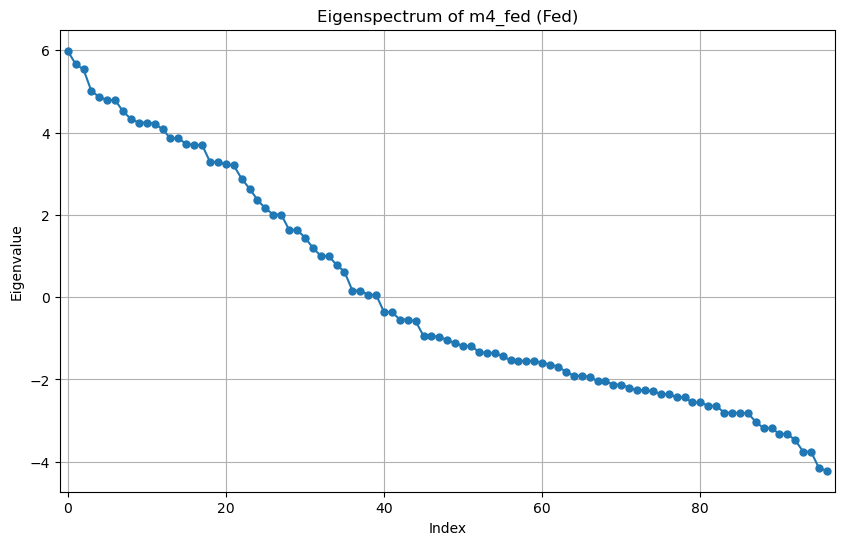

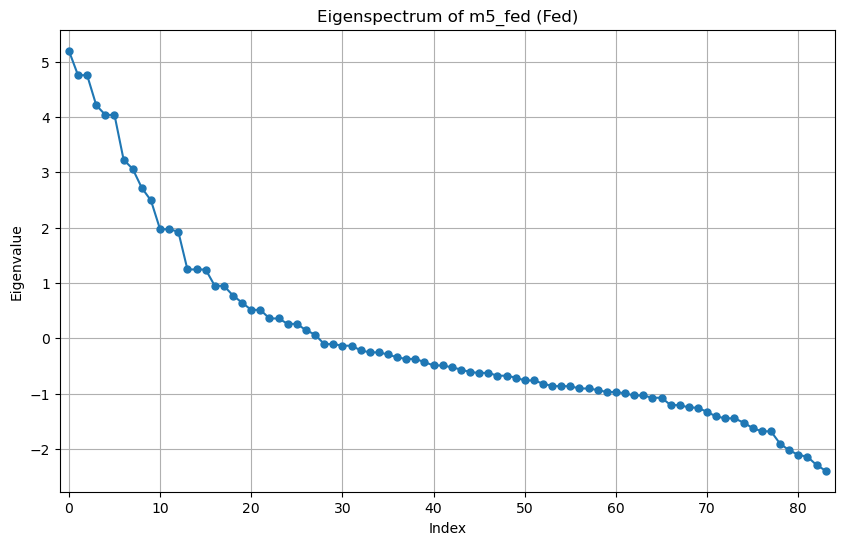

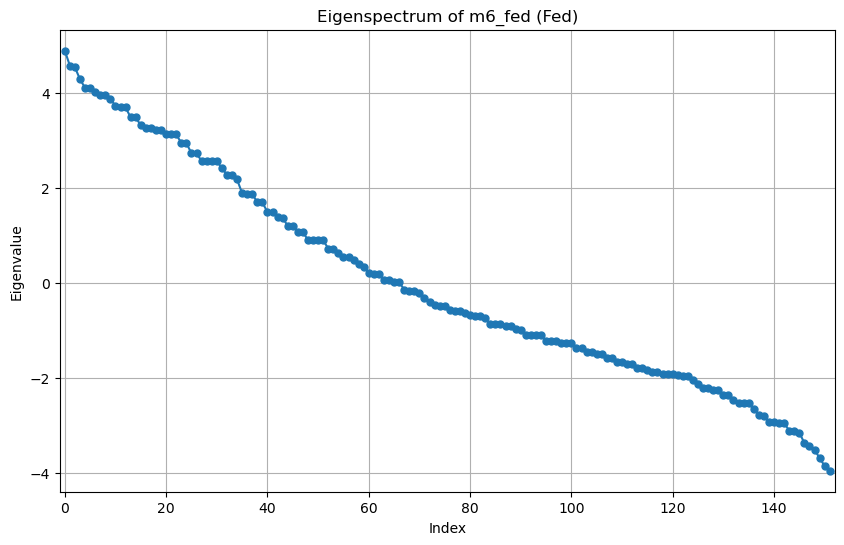

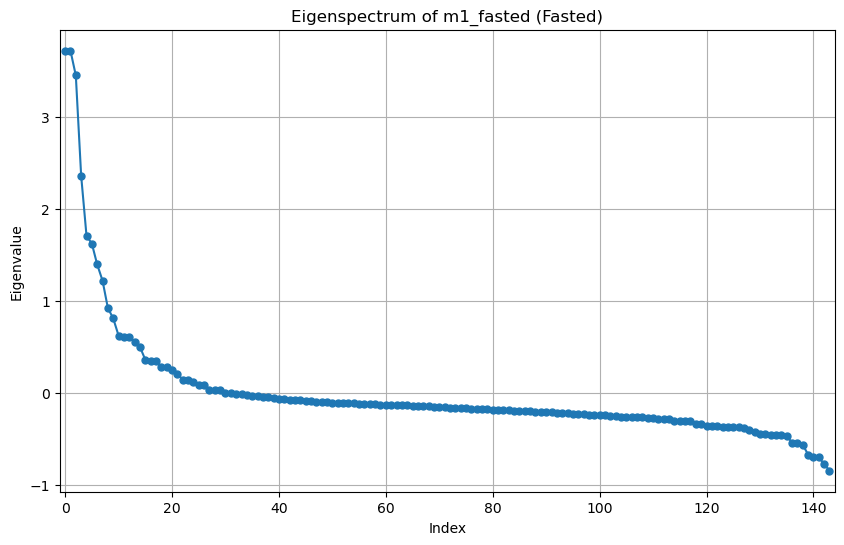

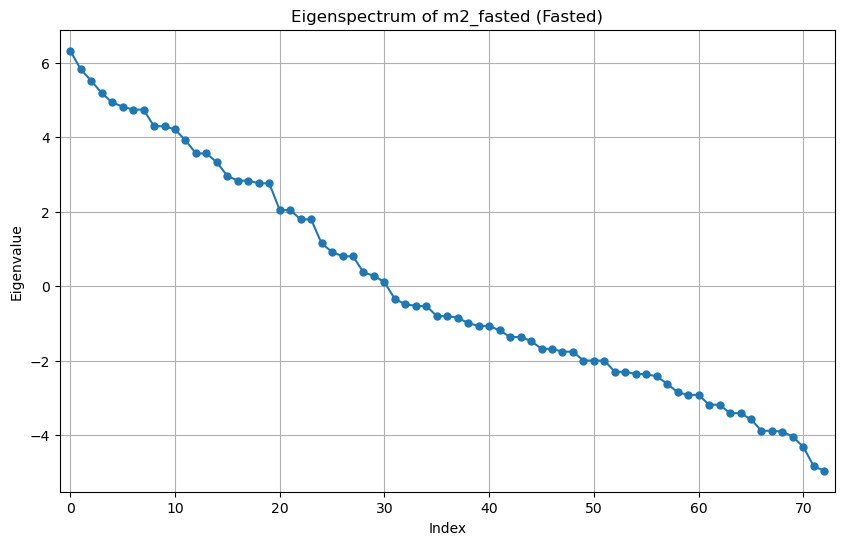

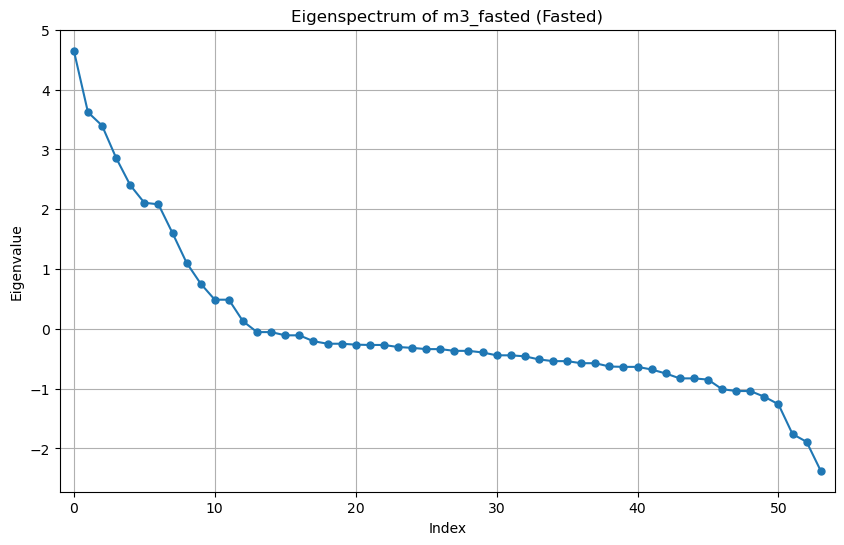

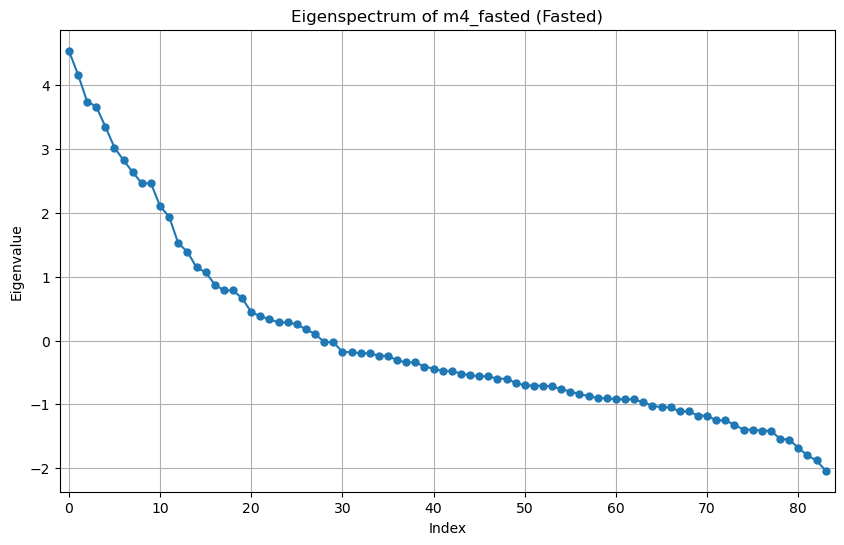

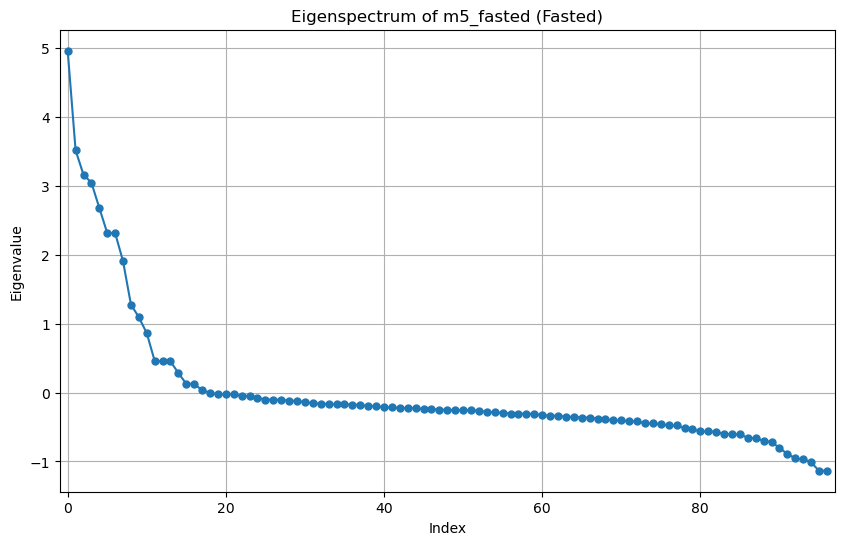

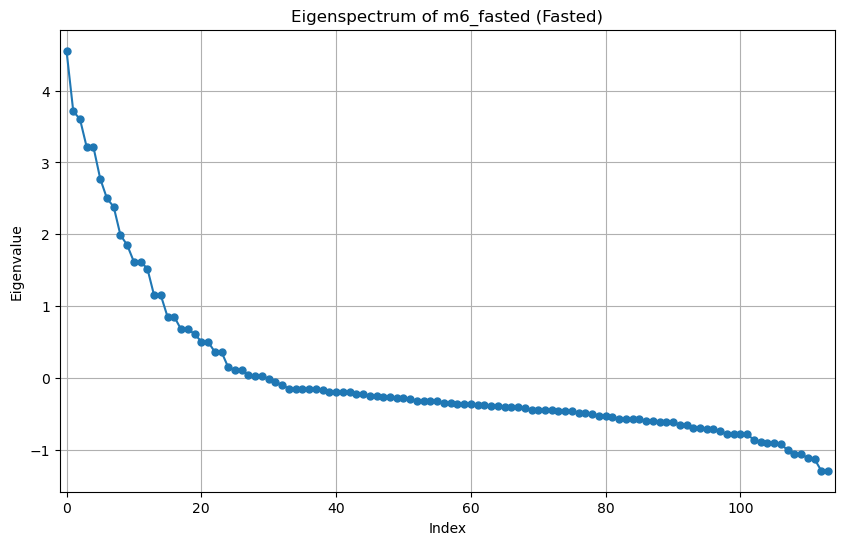

In [11]:
def plot_eigenspectrum(matrix, title):
    # Perform eigendocomposition
    eigenvalues, _ = np.linalg.eig(matrix)
    
    # Sort eigenvalues in descending order
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    # Plot the eigenspectrum
    plt.figure(figsize=(10, 6))
    plt.plot(eigenvalues, 'o-', markersize=5)
    plt.title(f'Eigenspectrum of {title}')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.xlim(-1, len(eigenvalues))  # Set x-axis limits
    plt.grid(True)
    plt.show()

# Plot eigenspectrum for each connectivity matrix in the fed state
for key, matrix in connectivity_matrices_fed.items():
    plot_eigenspectrum(matrix, f'{key} (Fed)')

# Plot eigenspectrum for each connectivity matrix in the fasted state
for key, matrix in connectivity_matrices_fasted.items():
    plot_eigenspectrum(matrix, f'{key} (Fasted)')

/home/charlesxu/anaconda3/envs/neuraldynamics/lib/python3.9/site-packages/matplotlib/transforms.py:2855: ComplexWarning: Casting complex values to real discards the imaginary part
  vmin, vmax = map(float, [vmin, vmax])


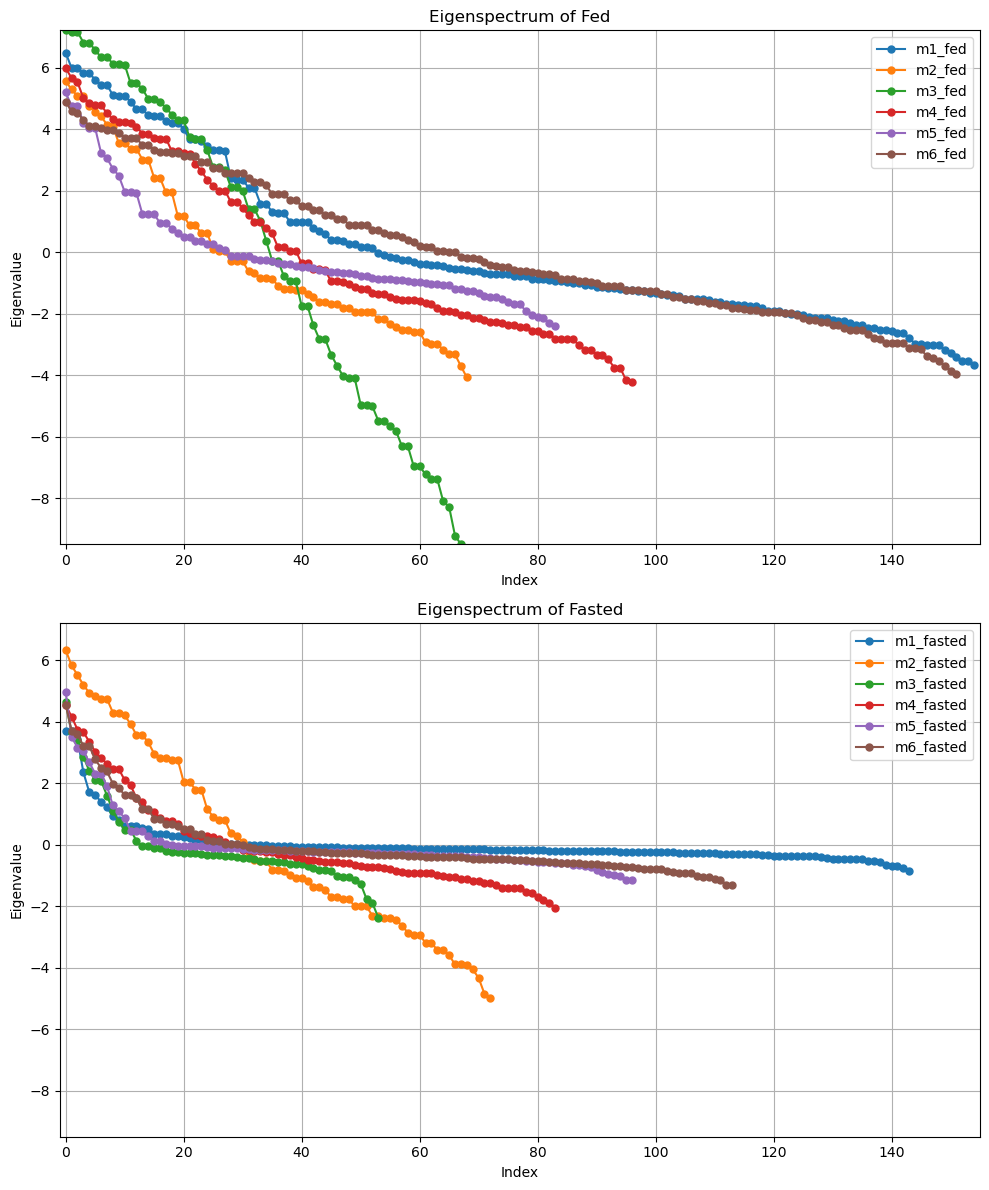

In [12]:
def plot_eigenspectrum(matrix, title, ax, label):
    # Perform eigendocomposition
    eigenvalues, _ = np.linalg.eig(matrix)
    
    # Sort eigenvalues in descending order
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    # Plot the eigenspectrum
    ax.plot(eigenvalues, 'o-', markersize=5, label=label)
    ax.set_title(f'Eigenspectrum of {title}')
    ax.set_xlabel('Index')
    ax.set_ylabel('Eigenvalue')
    ax.grid(True)
    return eigenvalues

# Initialize the figure and axes
fig, axs = plt.subplots(2, 1, figsize=(10, 12))

# Collect all eigenvalues to determine global min and max
all_eigenvalues = []
max_length = 0

# Plot eigenspectrum for each connectivity matrix in the fed state
for key, matrix in connectivity_matrices_fed.items():
    eigenvalues = plot_eigenspectrum(matrix, f'Fed', axs[0], key)
    all_eigenvalues.extend(eigenvalues)
    max_length = max(max_length, len(eigenvalues))

# Plot eigenspectrum for each connectivity matrix in the fasted state
for key, matrix in connectivity_matrices_fasted.items():
    eigenvalues = plot_eigenspectrum(matrix, f'Fasted', axs[1], key)
    all_eigenvalues.extend(eigenvalues)
    max_length = max(max_length, len(eigenvalues))

# Determine global min and max for eigenvalues
global_ymin, global_ymax = min(all_eigenvalues), max(all_eigenvalues)

# Set the same x and y limits for both subplots
for ax in axs:
    ax.set_xlim(-1, max_length)
    ax.set_ylim(global_ymin, global_ymax)

# Add legends
axs[0].legend()
axs[1].legend()

plt.tight_layout()
plt.show()

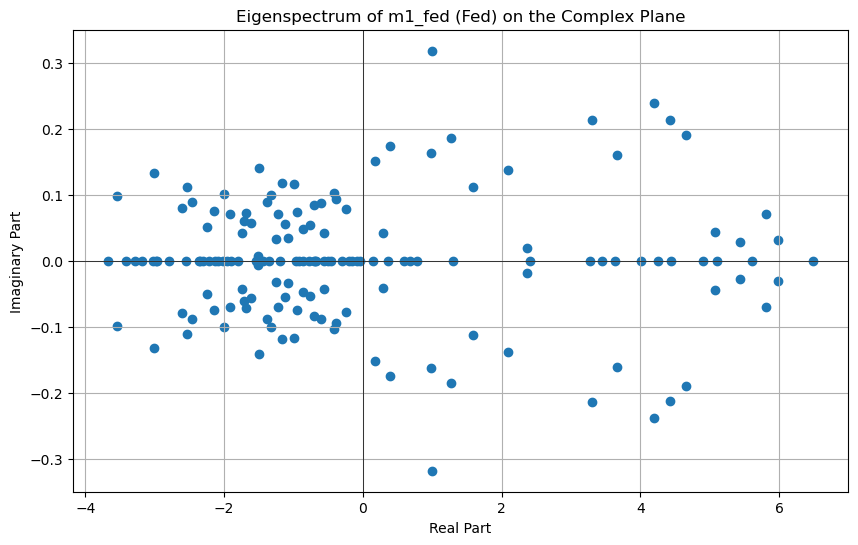

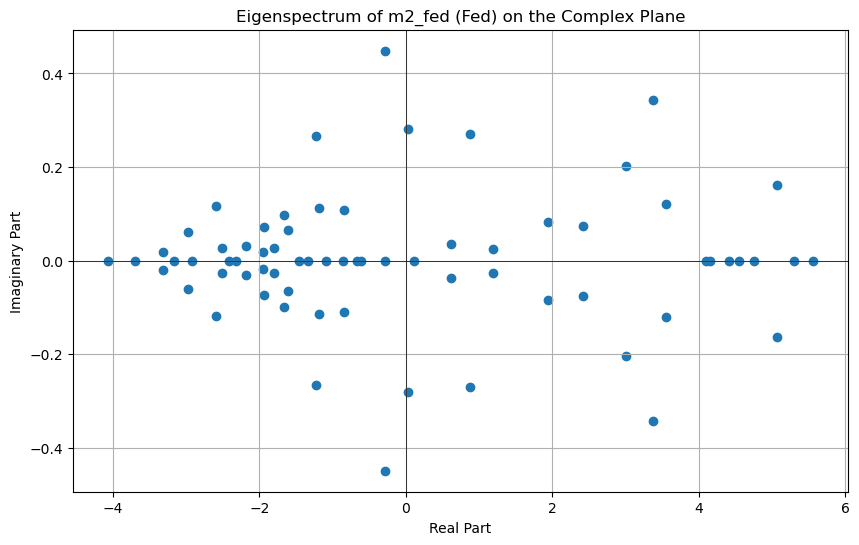

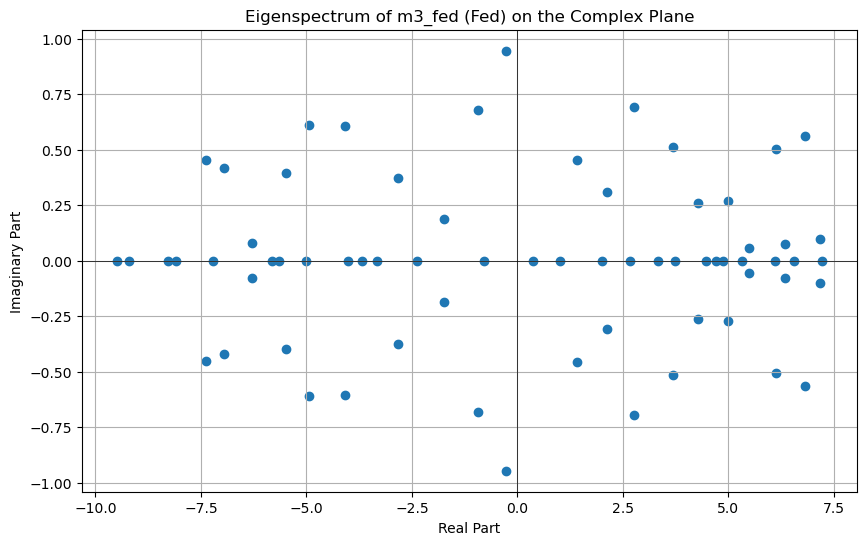

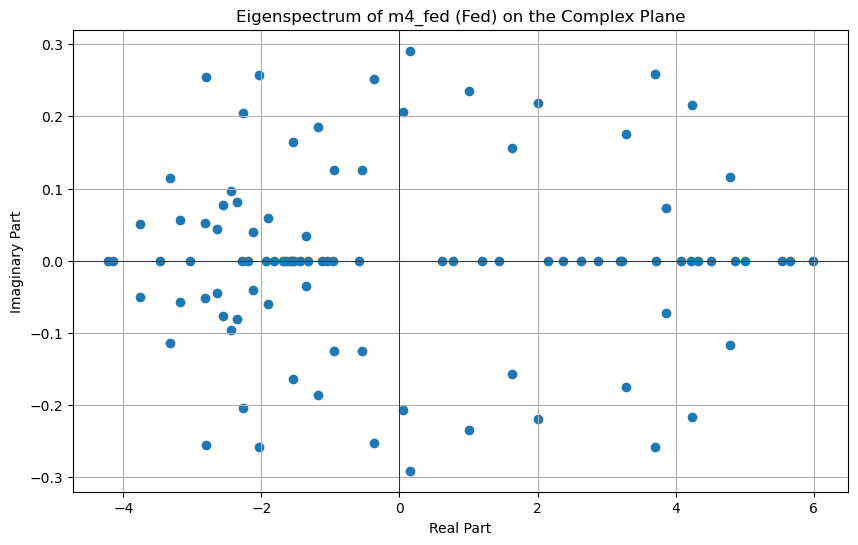

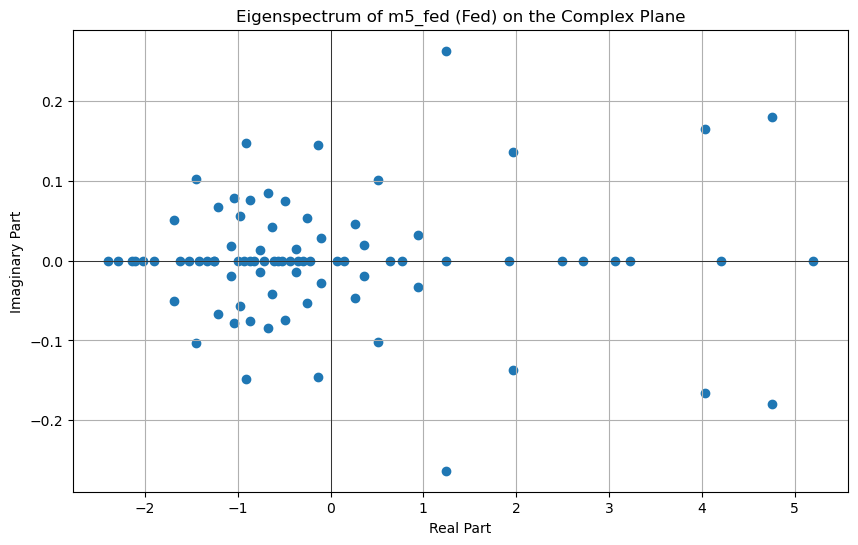

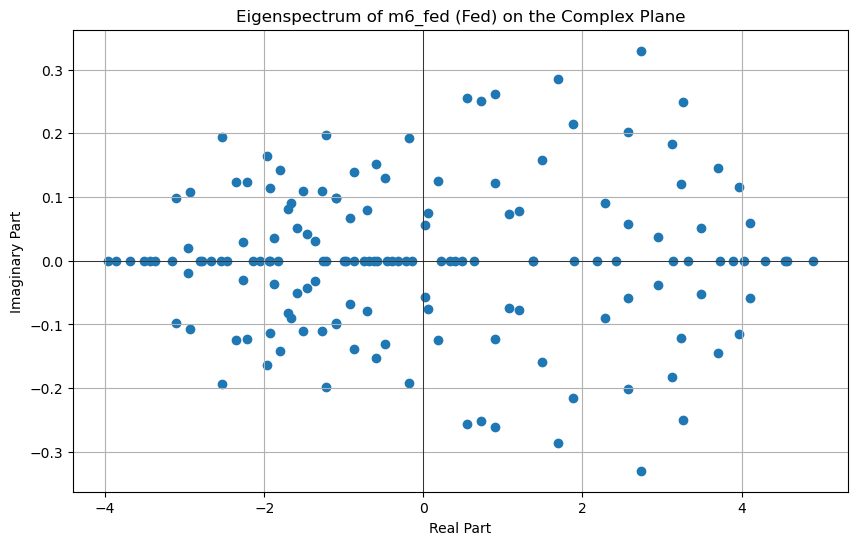

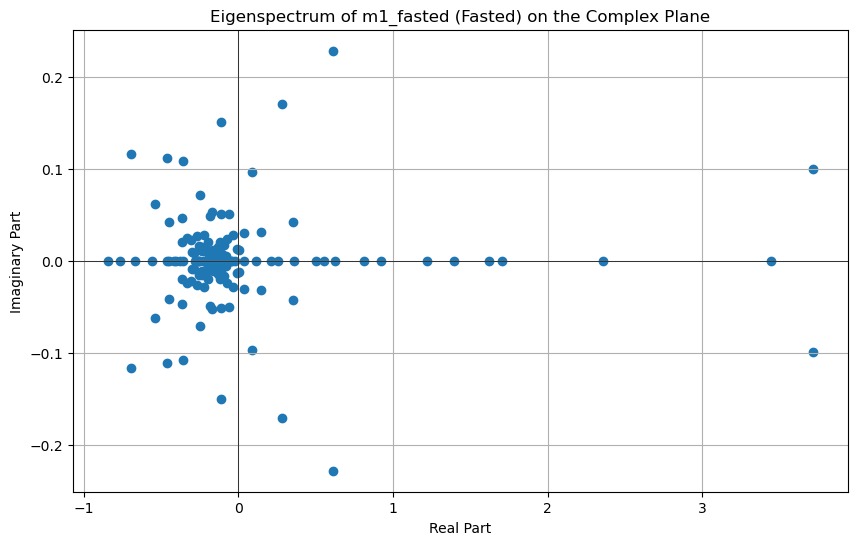

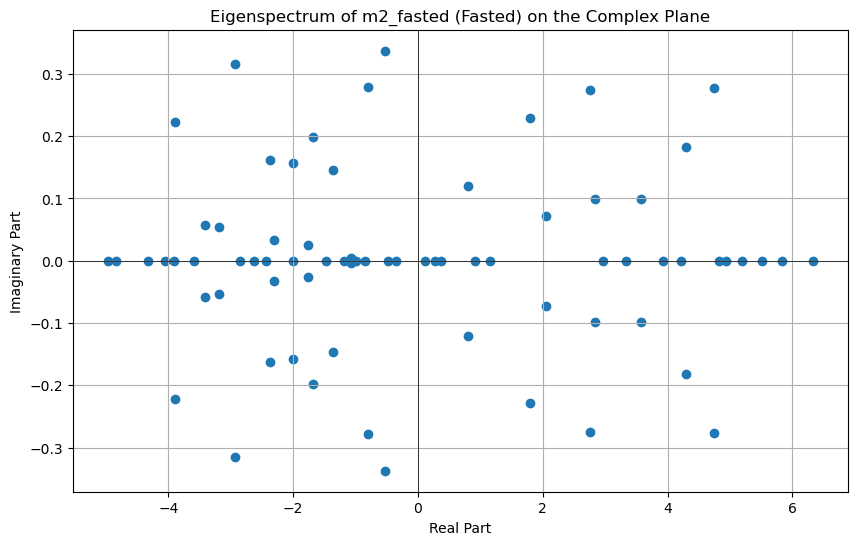

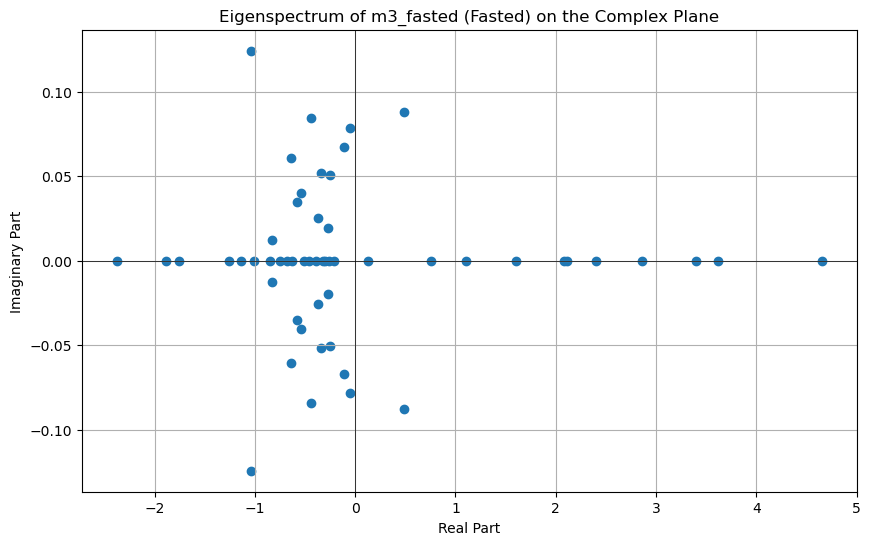

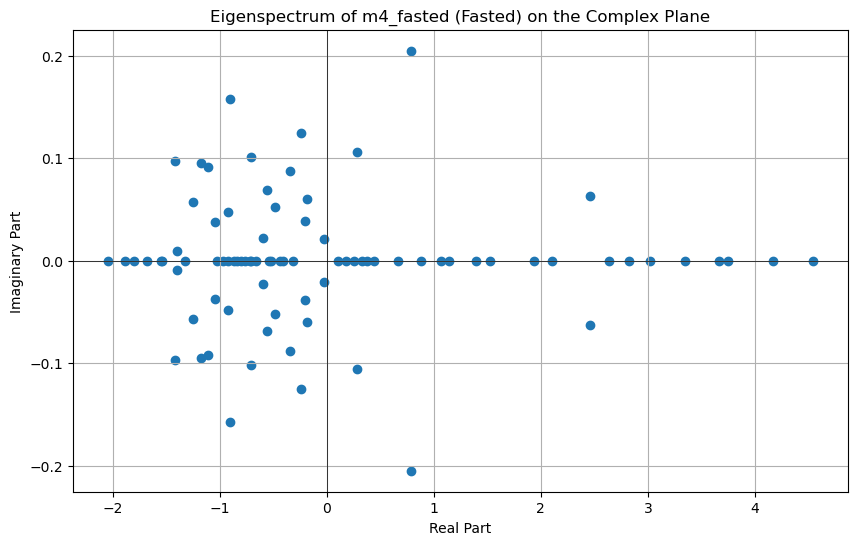

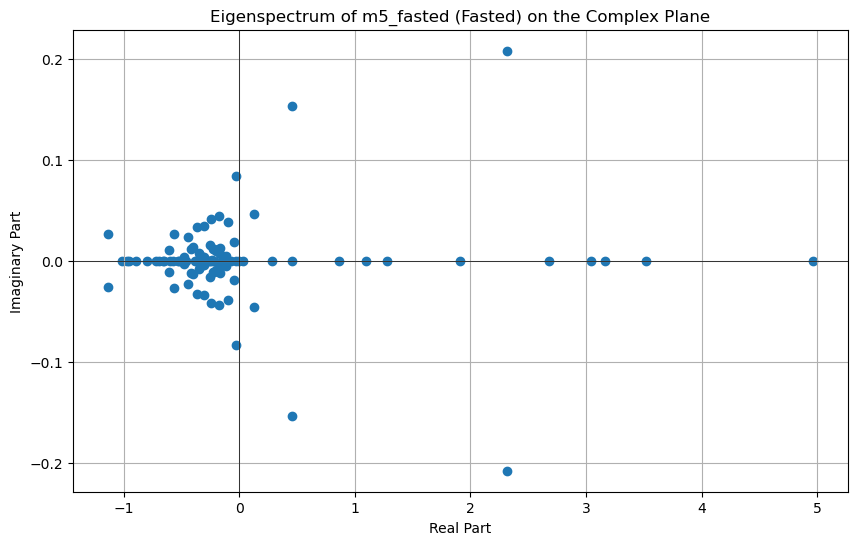

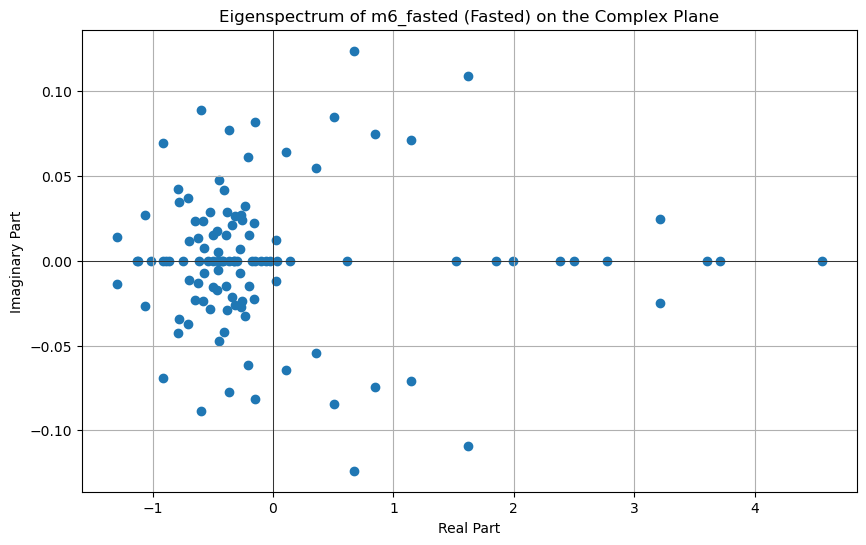

In [13]:
def plot_eigenspectrum_complex(matrix, title):
    # Perform eigendocomposition
    eigenvalues, _ = np.linalg.eig(matrix)
    
    # Plot the eigenvalues on the complex plane
    plt.figure(figsize=(10, 6))
    plt.scatter(eigenvalues.real, eigenvalues.imag, marker='o')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title(f'Eigenspectrum of {title} on the Complex Plane')
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.grid(True)
    plt.show()

# Plot eigenspectrum for each connectivity matrix in the fed state
for key, matrix in connectivity_matrices_fed.items():
    plot_eigenspectrum_complex(matrix, f'{key} (Fed)')

# Plot eigenspectrum for each connectivity matrix in the fasted state
for key, matrix in connectivity_matrices_fasted.items():
    plot_eigenspectrum_complex(matrix, f'{key} (Fasted)')

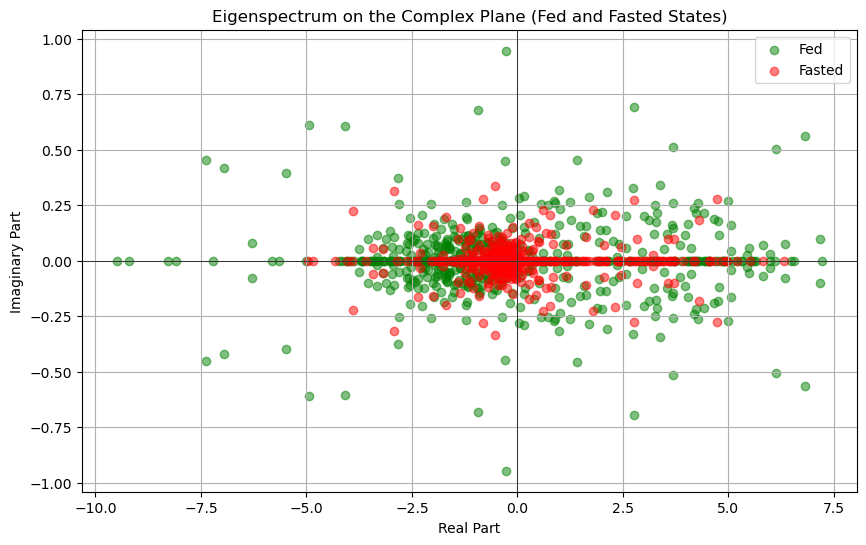

In [14]:
# Initialize a figure for the plot
plt.figure(figsize=(10, 6))

# Scatter all the eigenvalues for fed in green
for key, matrix in connectivity_matrices_fed.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    plt.scatter(eigenvalues.real, eigenvalues.imag, color='g', alpha=0.5, label='Fed' if key == 'm1_fed' else "")

# Scatter all the eigenvalues for fasted in red
for key, matrix in connectivity_matrices_fasted.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    plt.scatter(eigenvalues.real, eigenvalues.imag, color='r', alpha=0.5, label='Fasted' if key == 'm1_fasted' else "")

# Add title and labels
plt.title('Eigenspectrum on the Complex Plane (Fed and Fasted States)')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.show()

##### Time constants

In [15]:
def calculate_time_constants(eigenvalues):
    """
    Calculate the time constants for each eigenmode.
    
    Parameters:
    eigenvalues (numpy.ndarray): Array of eigenvalues.
    
    Returns:
    numpy.ndarray: Array of time constants.
    """
    real_parts = np.real(eigenvalues)
    time_constants = np.abs(1 / np.log(np.abs(real_parts)))
    return time_constants

# Calculate time constants for each connectivity matrix in the fed state
time_constants_fed = {}
for key, matrix in connectivity_matrices_fed.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
    time_constants_fed[key] = calculate_time_constants(eigenvalues)

# Calculate time constants for each connectivity matrix in the fasted state
time_constants_fasted = {}
for key, matrix in connectivity_matrices_fasted.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
    time_constants_fasted[key] = calculate_time_constants(eigenvalues)

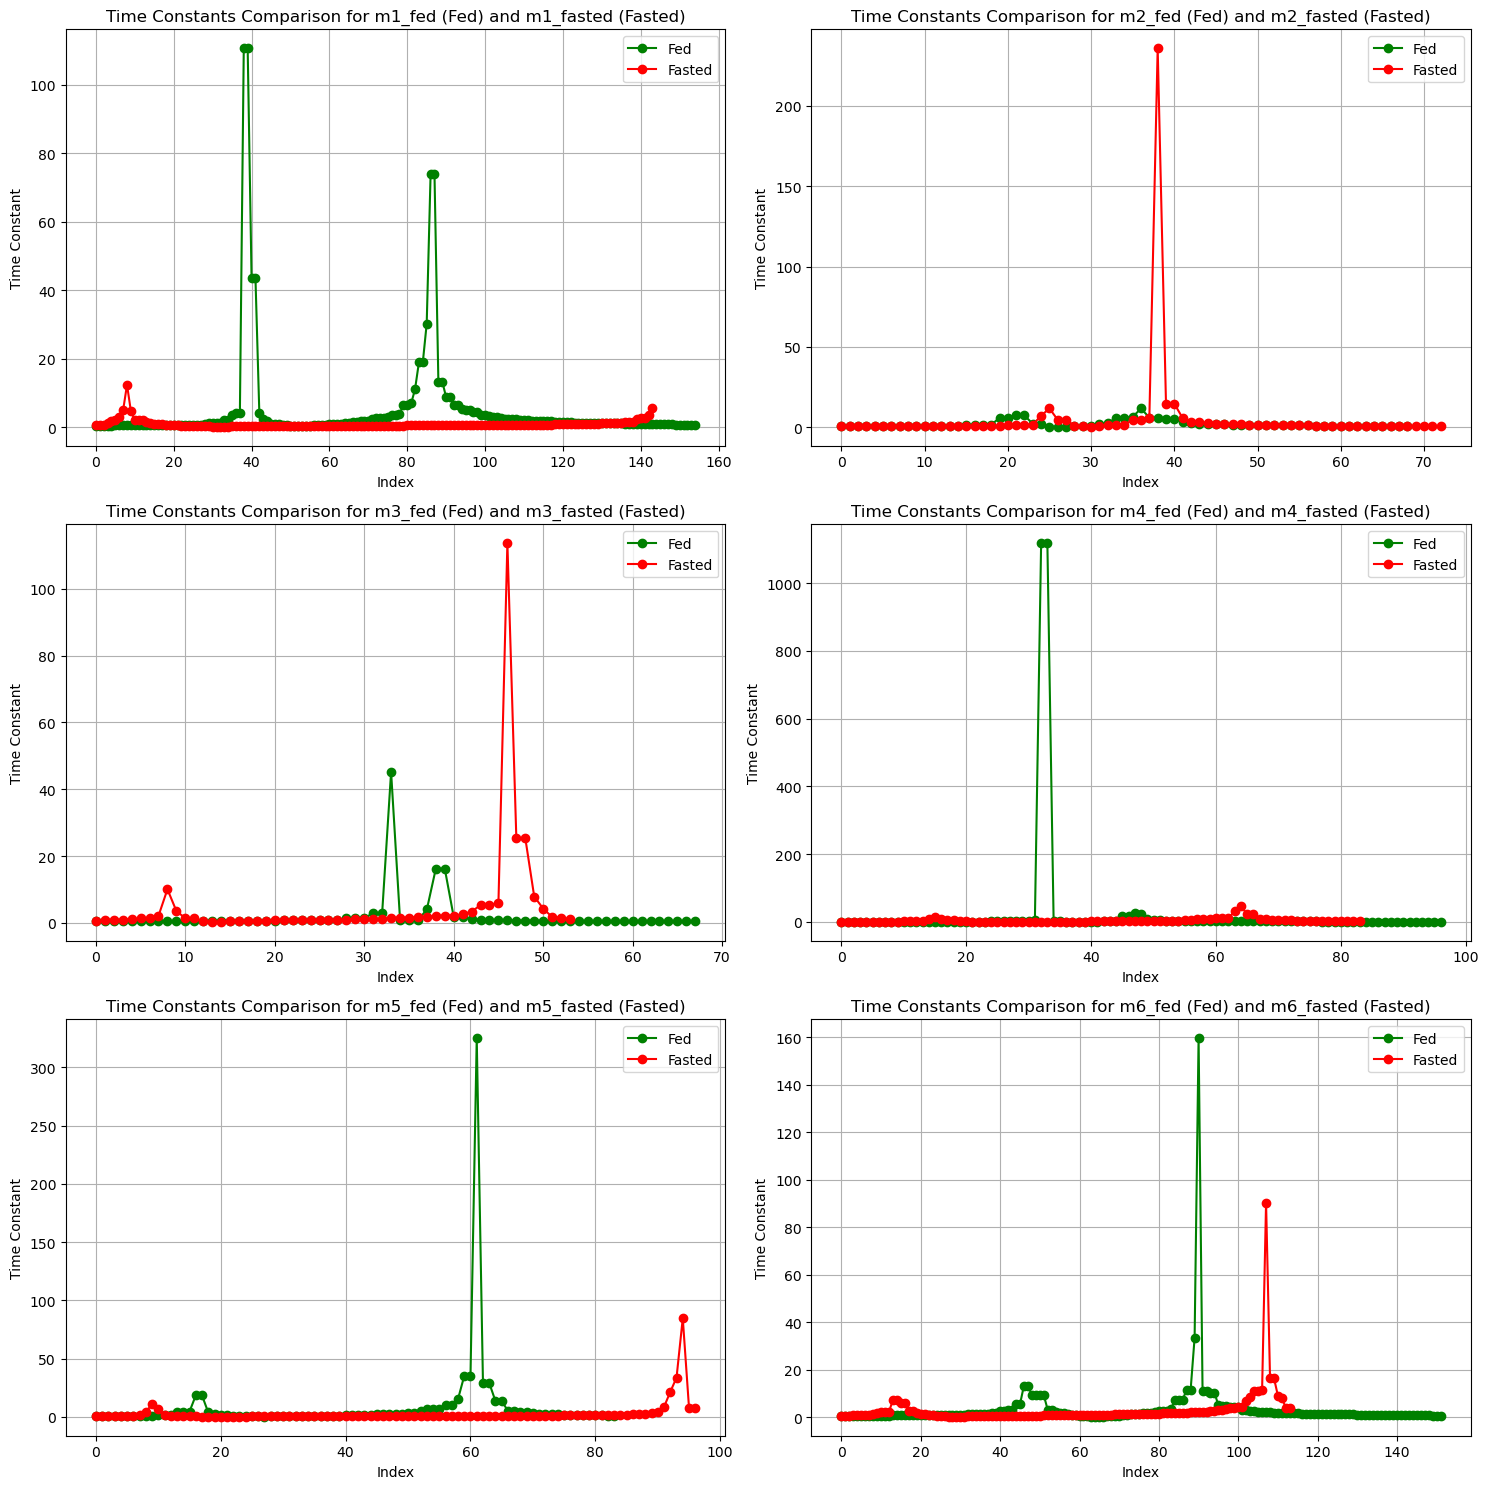

In [16]:
# List of animal keys for fed and fasted states
animal_keys_fed = list(time_constants_fed.keys())
animal_keys_fasted = list(time_constants_fasted.keys())

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each animal and plot the time constants
for i, (key_fed, key_fasted) in enumerate(zip(animal_keys_fed, animal_keys_fasted)):
    # Get the time constants for the current animal in fed and fasted states
    time_constants_fed_animal = time_constants_fed[key_fed]
    time_constants_fasted_animal = time_constants_fasted[key_fasted]
    
    # Plot the time constants for fed state
    axs[i].plot(time_constants_fed_animal, 'o-', color='g', label='Fed')
    
    # Plot the time constants for fasted state
    axs[i].plot(time_constants_fasted_animal, 'o-', color='r', label='Fasted')
    
    # Add title and labels
    axs[i].set_title(f'Time Constants Comparison for {key_fed} (Fed) and {key_fasted} (Fasted)')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Time Constant')
    axs[i].legend()
    axs[i].grid(True)
    
# Adjust layout
plt.tight_layout()
plt.show()

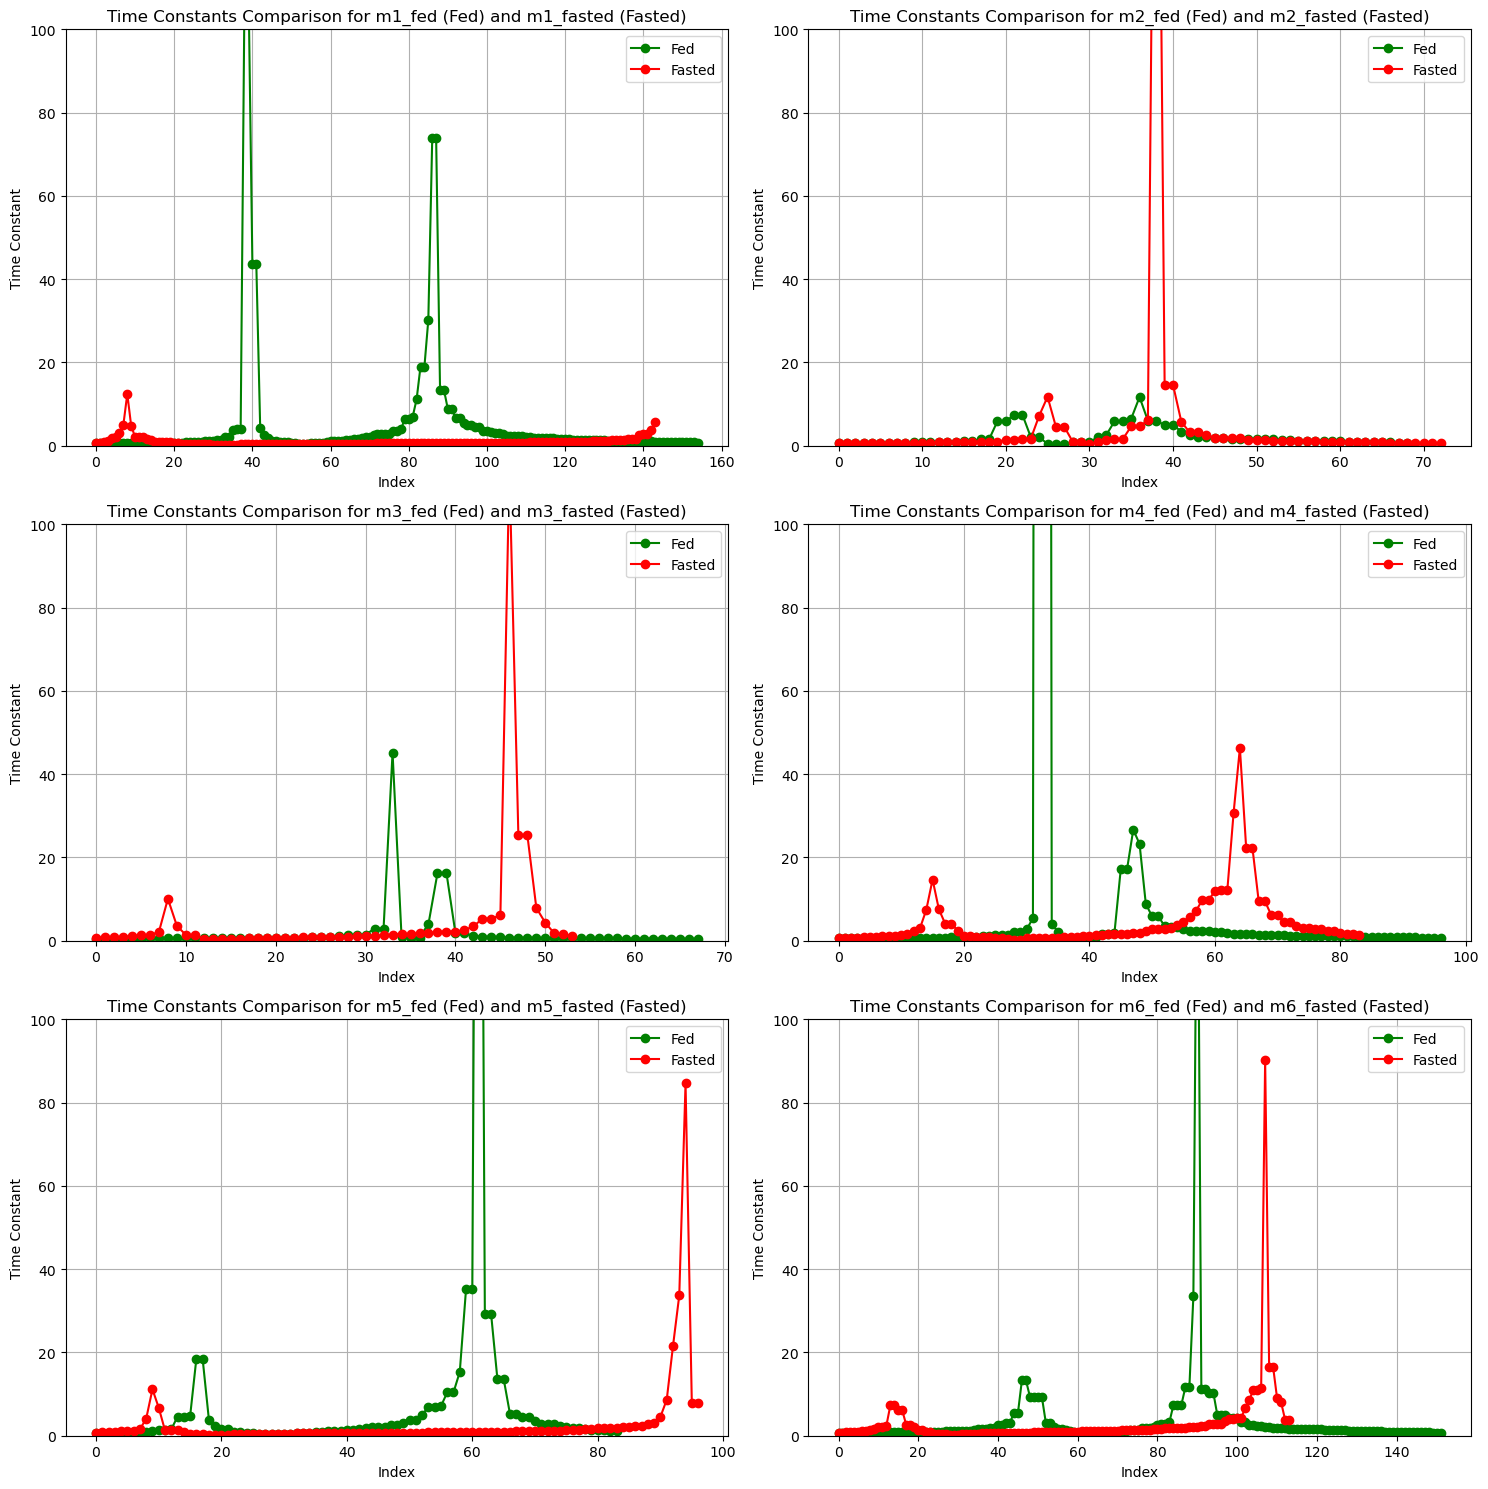

In [17]:
# List of animal keys for fed and fasted states
animal_keys_fed = list(time_constants_fed.keys())
animal_keys_fasted = list(time_constants_fasted.keys())

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each animal and plot the time constants
for i, (key_fed, key_fasted) in enumerate(zip(animal_keys_fed, animal_keys_fasted)):
    # Get the time constants for the current animal in fed and fasted states
    time_constants_fed_animal = time_constants_fed[key_fed]
    time_constants_fasted_animal = time_constants_fasted[key_fasted]
    
    # Plot the time constants for fed state
    axs[i].plot(time_constants_fed_animal, 'o-', color='g', label='Fed')
    
    # Plot the time constants for fasted state
    axs[i].plot(time_constants_fasted_animal, 'o-', color='r', label='Fasted')
    
    # Add title and labels
    axs[i].set_title(f'Time Constants Comparison for {key_fed} (Fed) and {key_fasted} (Fasted)')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Time Constant')
    axs[i].legend()
    axs[i].grid(True)
    
    # Set y-axis limits
    axs[i].set_ylim(0, 100)

# Adjust layout
plt.tight_layout()
plt.show()

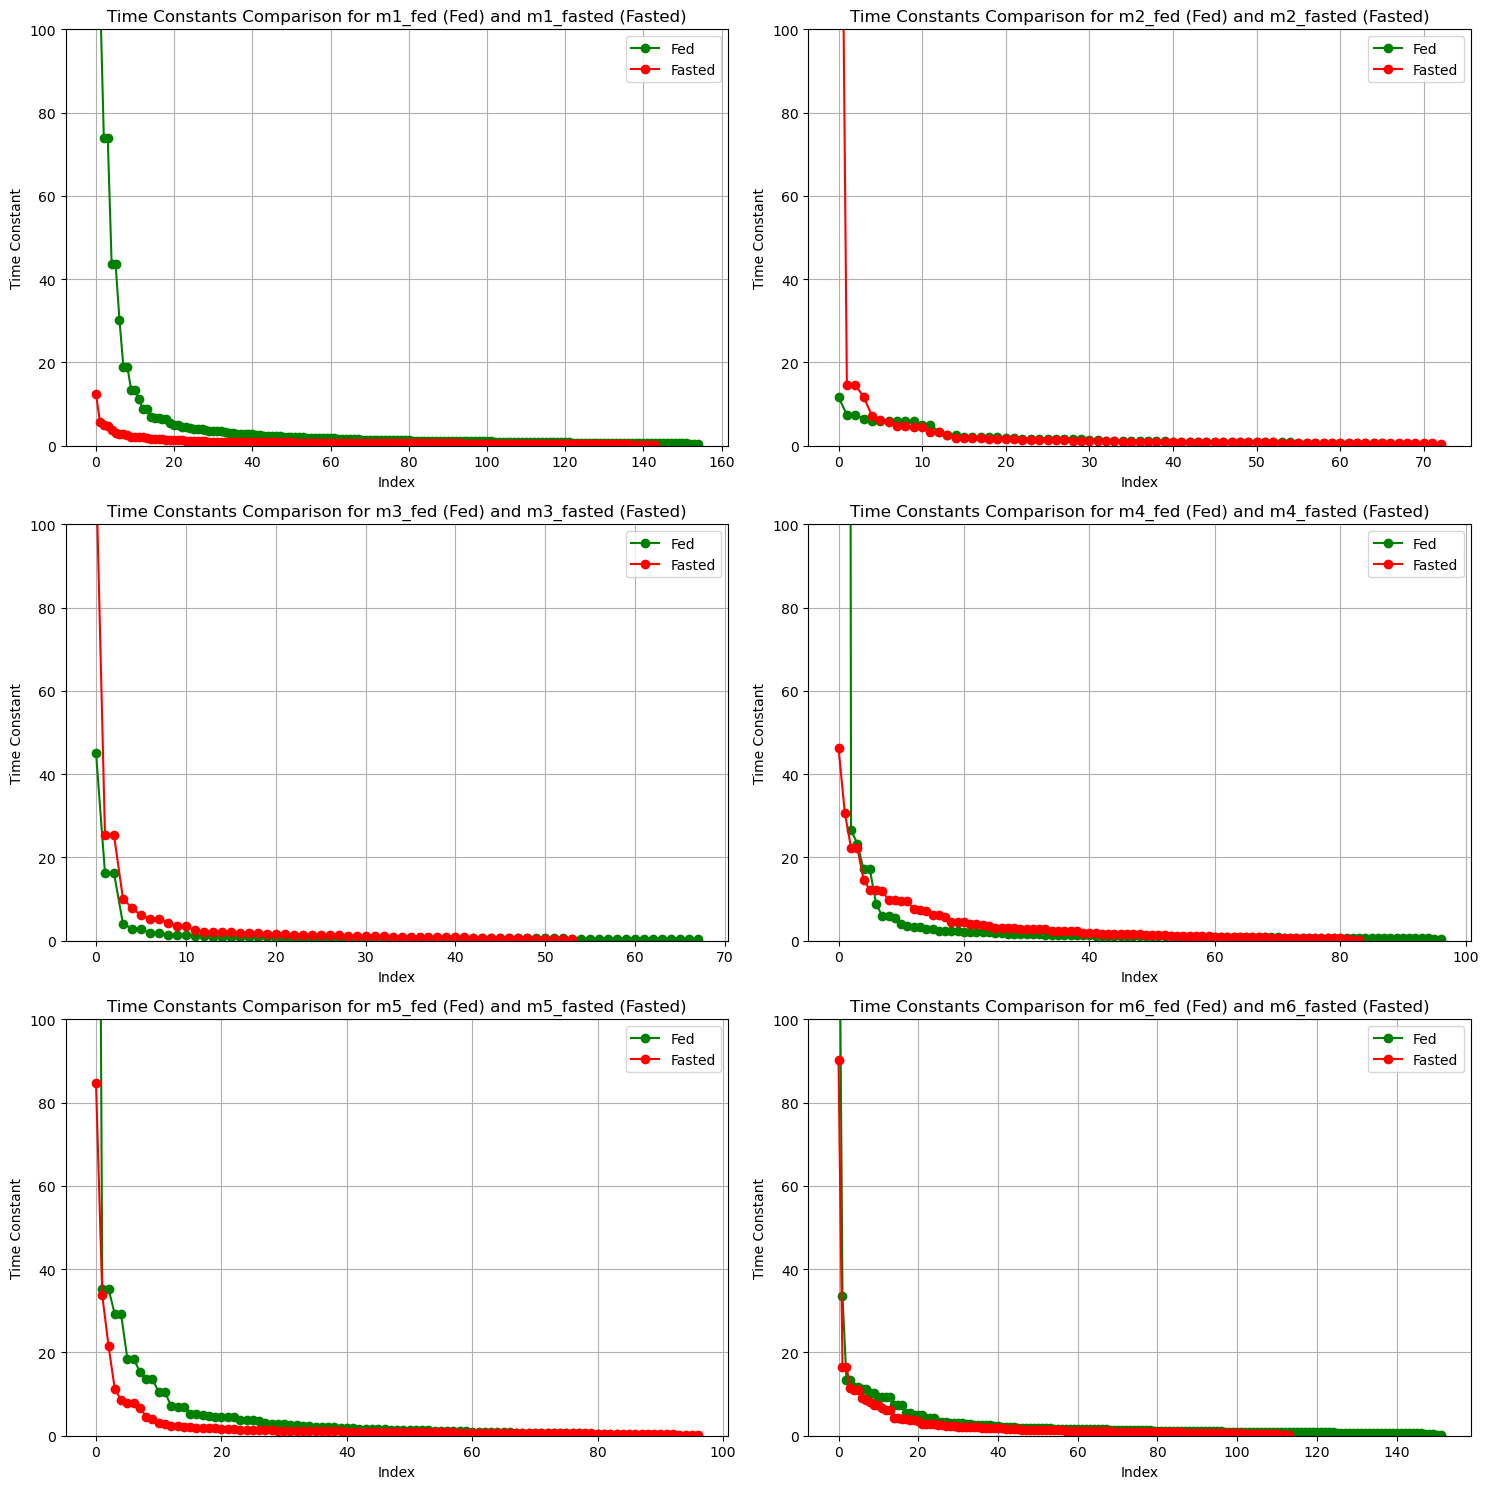

In [18]:
# List of animal keys for fed and fasted states
animal_keys_fed = list(time_constants_fed.keys())
animal_keys_fasted = list(time_constants_fasted.keys())

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each animal and plot the time constants
for i, (key_fed, key_fasted) in enumerate(zip(animal_keys_fed, animal_keys_fasted)):
    # Get the time constants for the current animal in fed and fasted states
    time_constants_fed_animal = np.sort(time_constants_fed[key_fed])[::-1]
    time_constants_fasted_animal = np.sort(time_constants_fasted[key_fasted])[::-1]
    
    # Plot the time constants for fed state
    axs[i].plot(time_constants_fed_animal, 'o-', color='g', label='Fed')
    
    # Plot the time constants for fasted state
    axs[i].plot(time_constants_fasted_animal, 'o-', color='r', label='Fasted')
    
    # Add title and labels
    axs[i].set_title(f'Time Constants Comparison for {key_fed} (Fed) and {key_fasted} (Fasted)')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Time Constant')
    axs[i].legend()
    axs[i].grid(True)
    
    # Set y-axis limits
    axs[i].set_ylim(0, 100)

# Adjust layout
plt.tight_layout()
plt.show()

#### Singular value decomposition

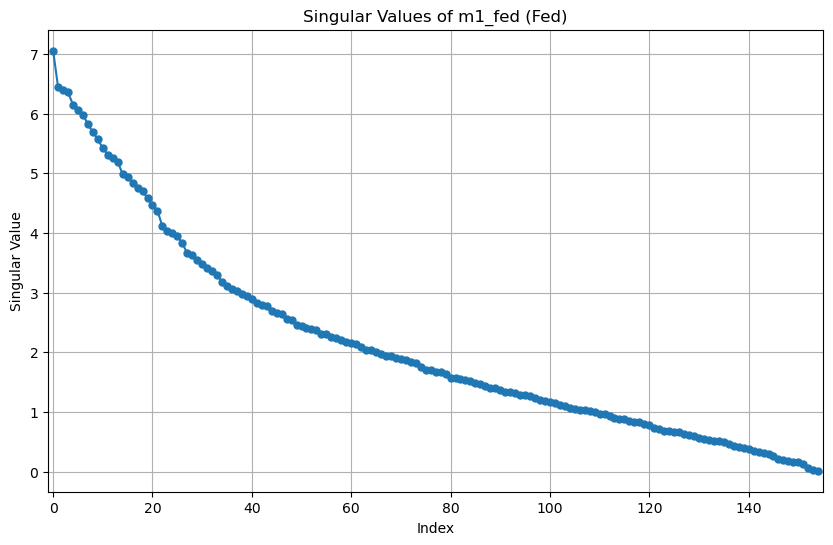

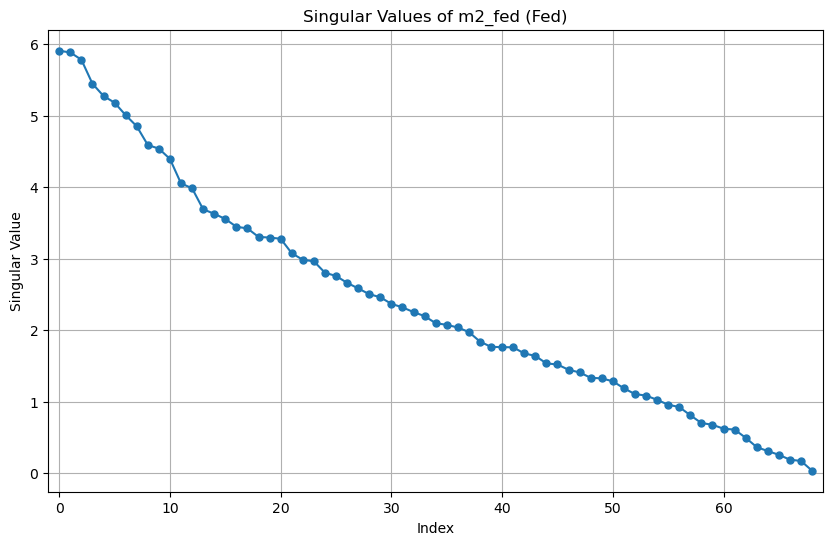

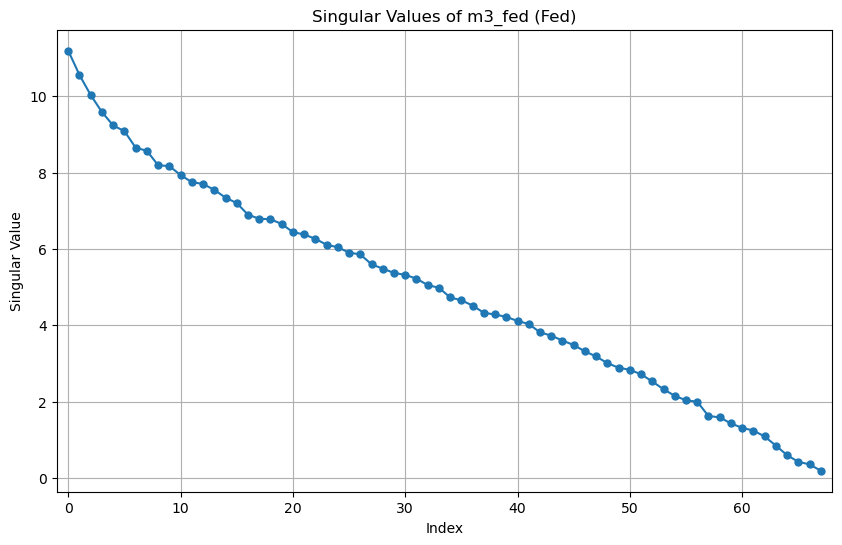

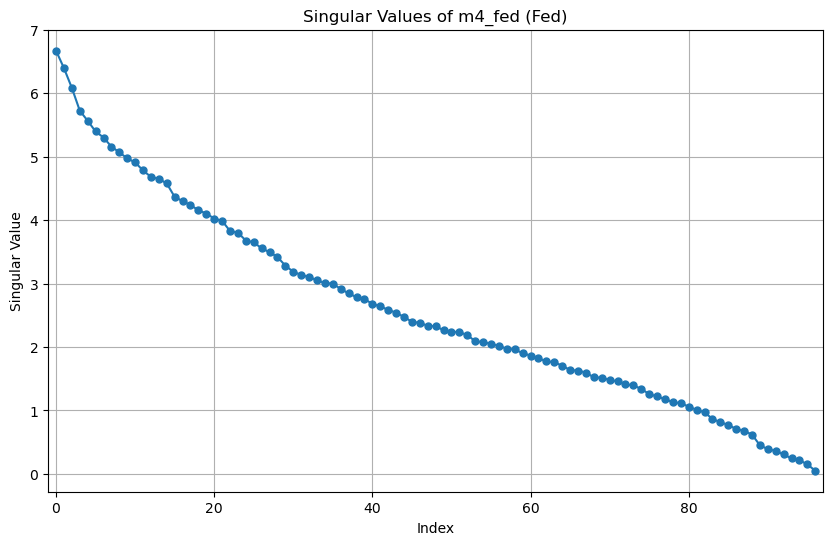

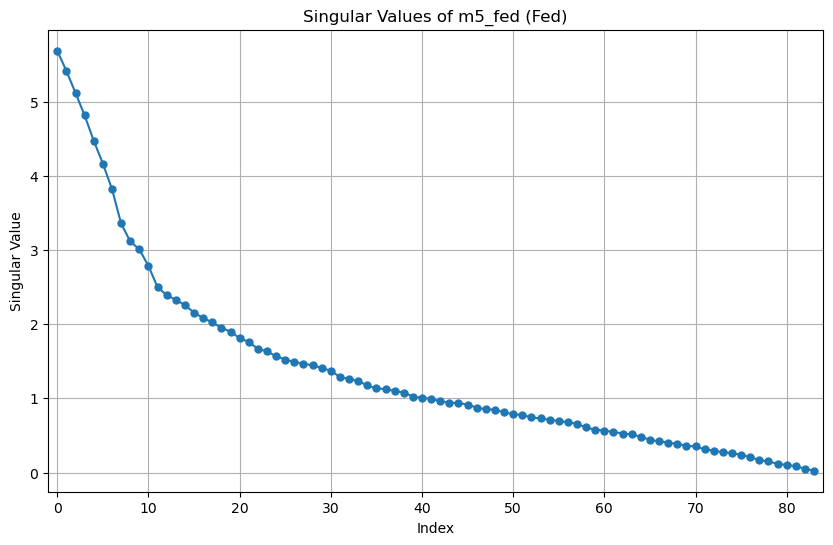

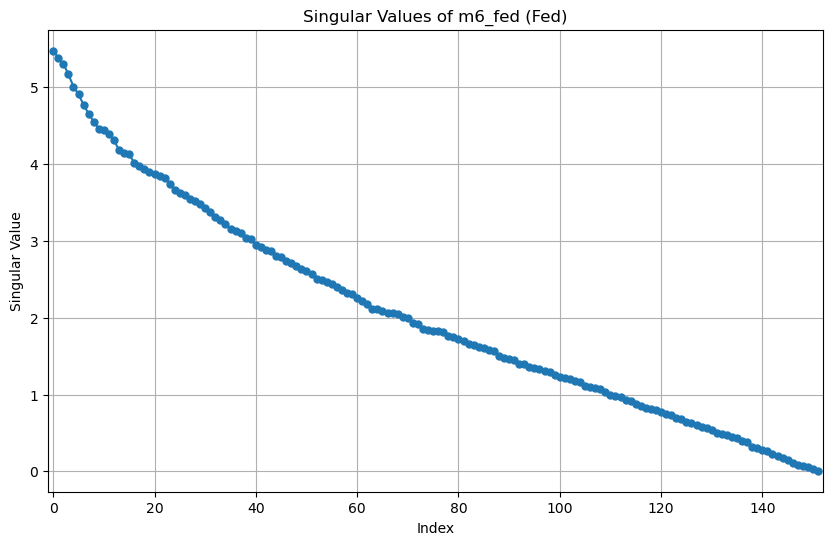

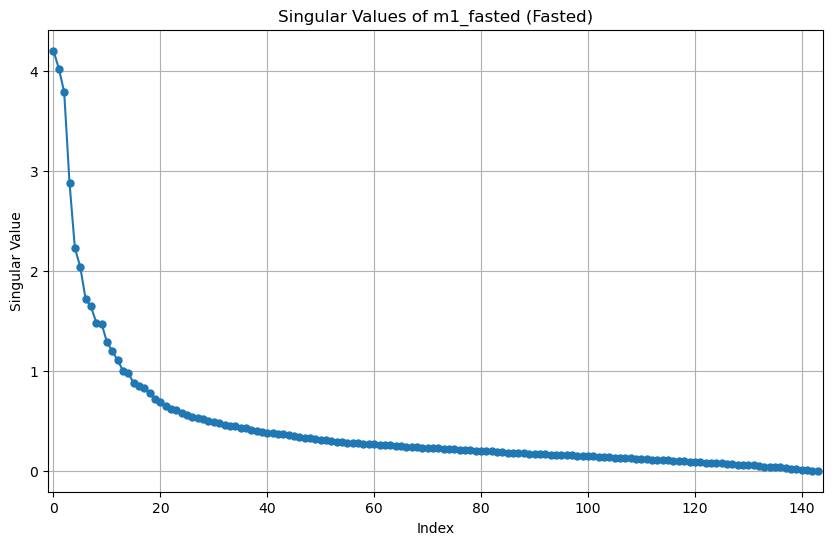

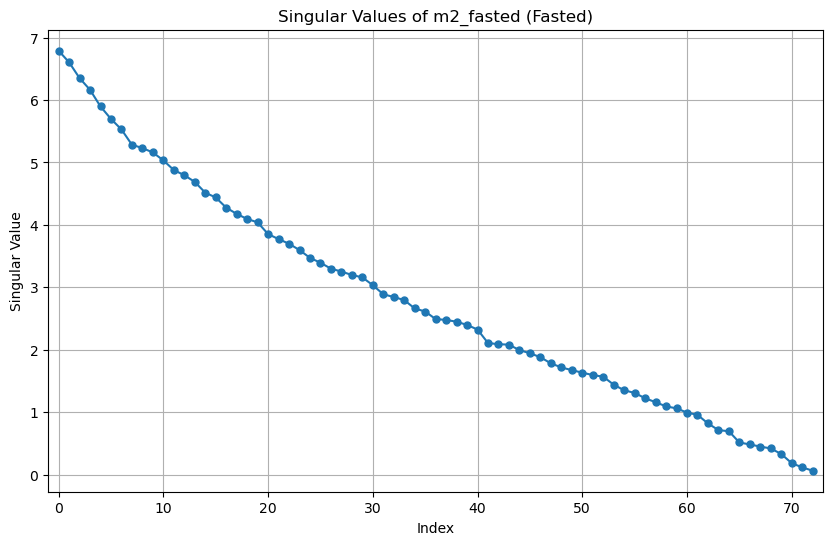

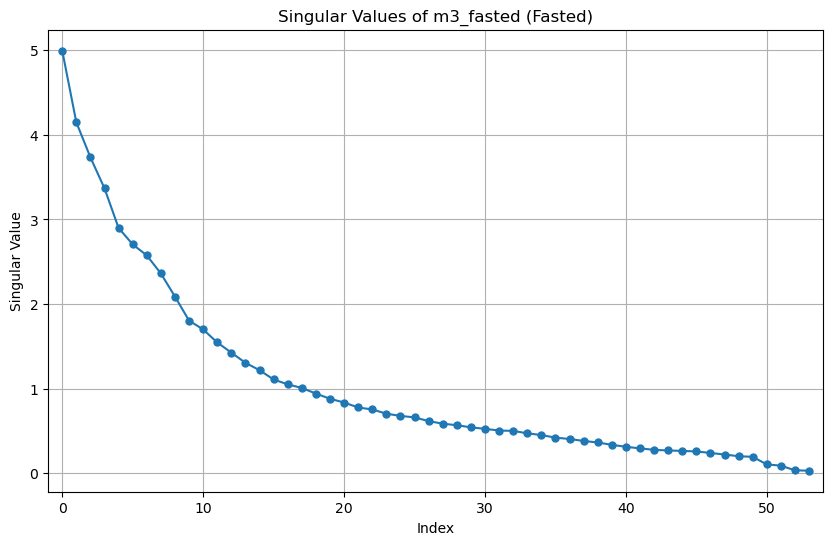

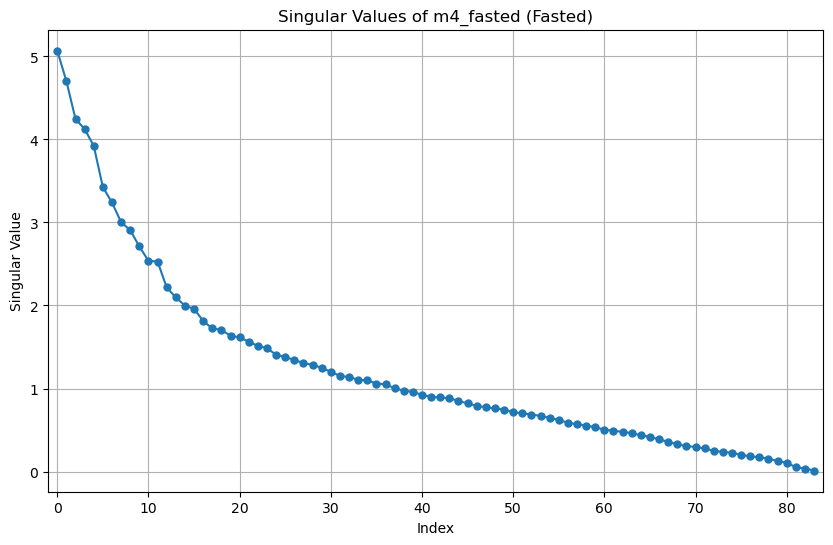

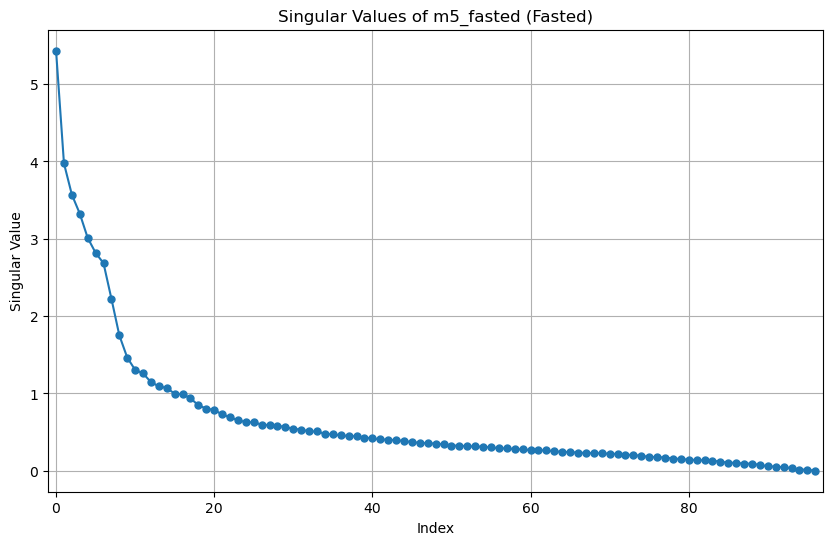

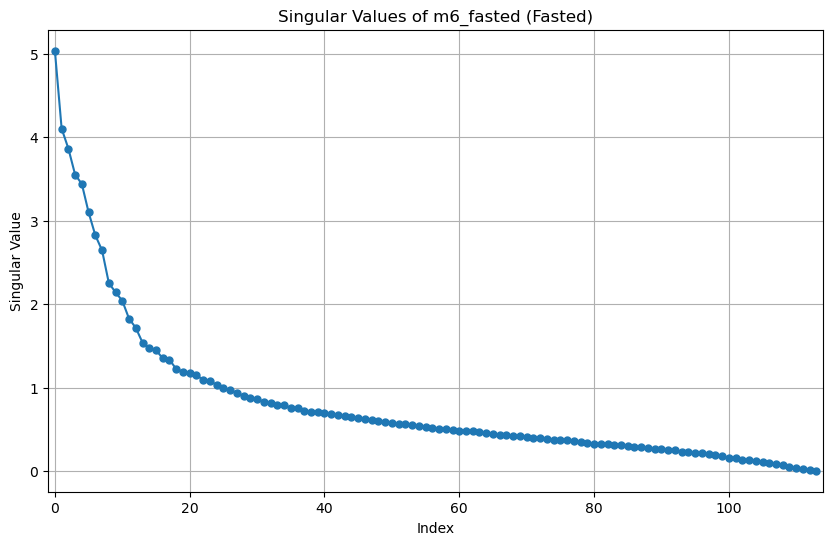

In [19]:
def plot_singular_values(matrix, title):
    # Perform Singular Value Decomposition
    U, s, Vt = np.linalg.svd(matrix)
    
    # Plot the singular values
    plt.figure(figsize=(10, 6))
    plt.plot(s, 'o-', markersize=5)
    plt.title(f'Singular Values of {title}')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.xlim(-1, len(s))  # Set x-axis limits
    plt.grid(True)
    plt.show()

# Plot singular values for each connectivity matrix in the fed state
for key, matrix in connectivity_matrices_fed.items():
    plot_singular_values(matrix, f'{key} (Fed)')

# Plot singular values for each connectivity matrix in the fasted state
for key, matrix in connectivity_matrices_fasted.items():
    plot_singular_values(matrix, f'{key} (Fasted)')

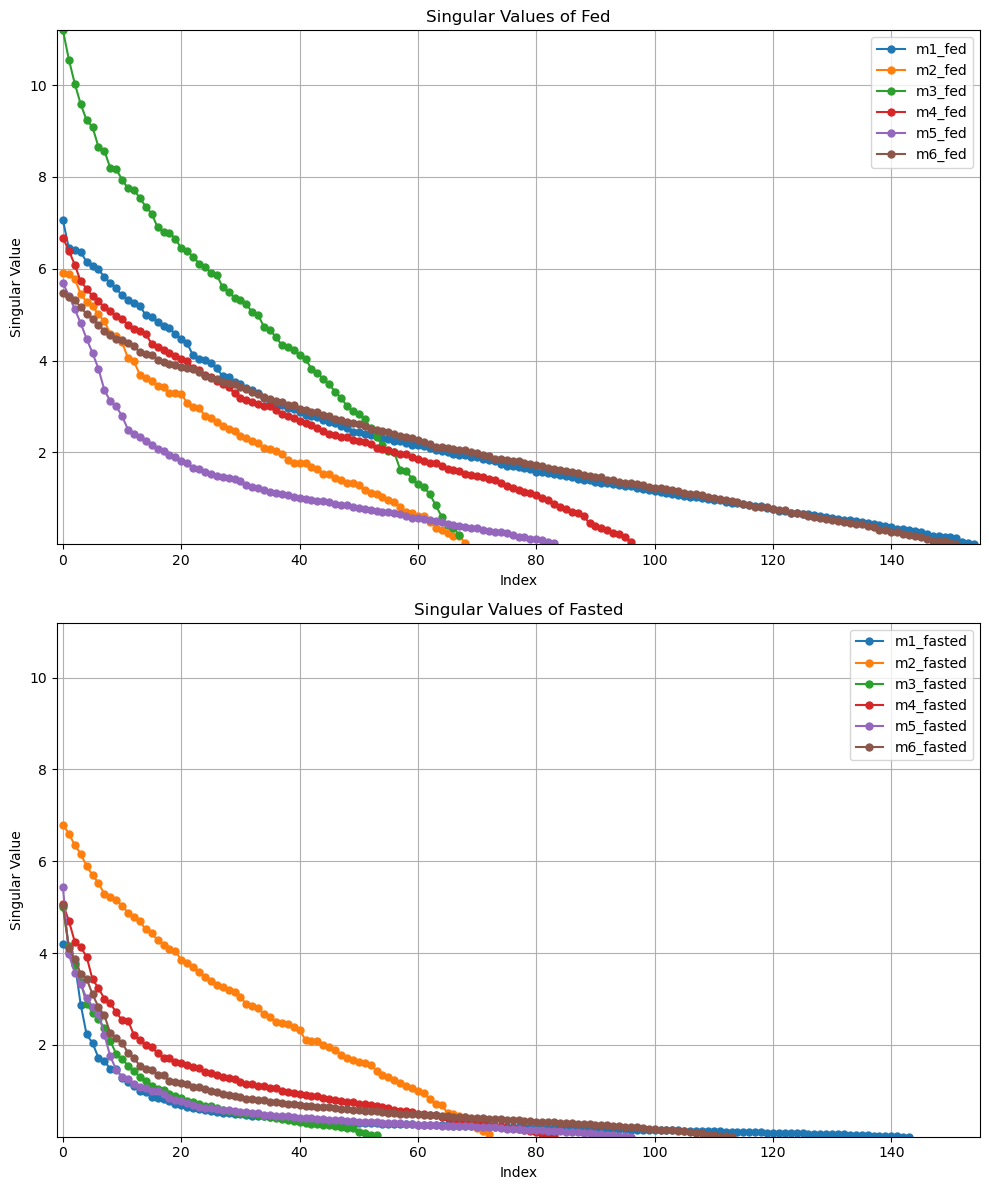

In [20]:
def plot_singular_values(matrix, title, ax, label):
    # Perform Singular Value Decomposition
    U, s, Vt = np.linalg.svd(matrix)
    
    # Plot the singular values
    ax.plot(s, 'o-', markersize=5, label=label)
    ax.set_title(f'Singular Values of {title}')
    ax.set_xlabel('Index')
    ax.set_ylabel('Singular Value')
    ax.grid(True)
    return s

# Initialize the figure and axes
fig, axs = plt.subplots(2, 1, figsize=(10, 12))

# Collect all singular values to determine global min and max
all_singular_values = []
max_length = 0

# Plot singular values for each connectivity matrix in the fed state
for key, matrix in connectivity_matrices_fed.items():
    singular_values = plot_singular_values(matrix, f'Fed', axs[0], key)
    all_singular_values.extend(singular_values)
    max_length = max(max_length, len(singular_values))

# Plot singular values for each connectivity matrix in the fasted state
for key, matrix in connectivity_matrices_fasted.items():
    singular_values = plot_singular_values(matrix, f'Fasted', axs[1], key)
    all_singular_values.extend(singular_values)
    max_length = max(max_length, len(singular_values))

# Determine global min and max for singular values
global_ymin, global_ymax = min(all_singular_values), max(all_singular_values)

# Set the same x and y limits for both subplots
for ax in axs:
    ax.set_xlim(-1, max_length)
    ax.set_ylim(global_ymin, global_ymax)

# Add legends
axs[0].legend()
axs[1].legend()

plt.tight_layout()
plt.show()

## Non-negative cell-coupled GLM

In [21]:
connectivity_nn_dir = '/home/charlesxu/local/data/JK_functionalConn/connectivity_matrices_pos_coef/connectivity_matrices'

# Load the non-negative connectivity matrices for the fed state
connectivity_matrices_nn_fed = {}
for file_name in os.listdir(os.path.join(connectivity_nn_dir, 'fed')):
    if file_name.endswith('.npy'):
        matrix_name = os.path.splitext(file_name)[0]
        matrix_key = '_'.join(matrix_name.split('_')[-4:-2])
        file_path = os.path.join(connectivity_nn_dir, 'fed', file_name)
        connectivity_matrices_nn_fed[matrix_key] = np.load(file_path)

# Sort the dictionary by the key
sorted_keys = sorted(connectivity_matrices_nn_fed.keys(), key=lambda x: int(x.split('_')[0][1:]))
connectivity_matrices_nn_fed = OrderedDict((key, connectivity_matrices_nn_fed[key]) for key in sorted_keys)

# Load the non-negative connectivity matrices for the fasted state
connectivity_matrices_nn_fasted = {}
for file_name in os.listdir(os.path.join(connectivity_nn_dir, 'fasted')):
    if file_name.endswith('.npy'):
        matrix_name = os.path.splitext(file_name)[0]
        matrix_key = '_'.join(matrix_name.split('_')[-4:-2])
        file_path = os.path.join(connectivity_nn_dir, 'fasted', file_name)
        connectivity_matrices_nn_fasted[matrix_key] = np.load(file_path)

# Sort the dictionary by the key
sorted_keys = sorted(connectivity_matrices_nn_fasted.keys(), key=lambda x: int(x.split('_')[0][1:]))
connectivity_matrices_nn_fasted = OrderedDict((key, connectivity_matrices_nn_fasted[key]) for key in sorted_keys)

### Individual distributions

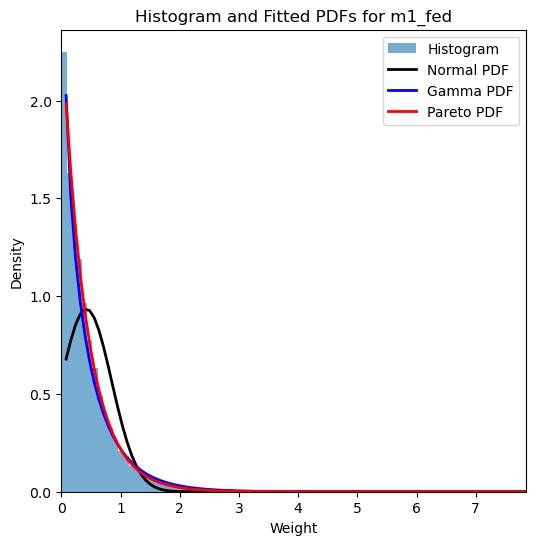

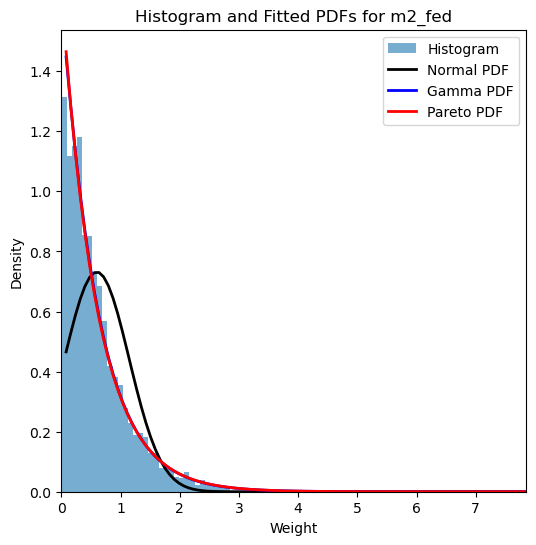

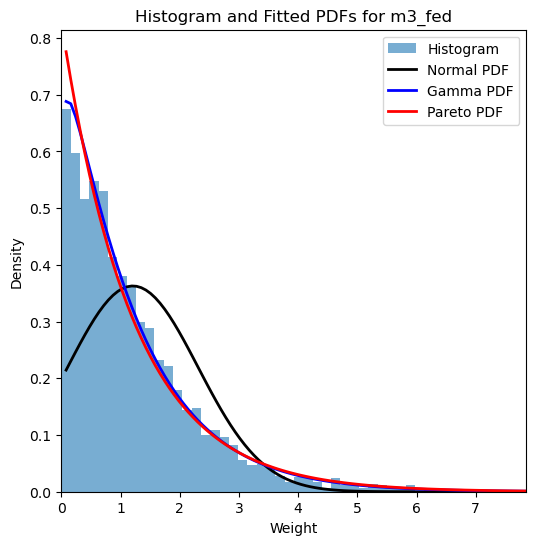

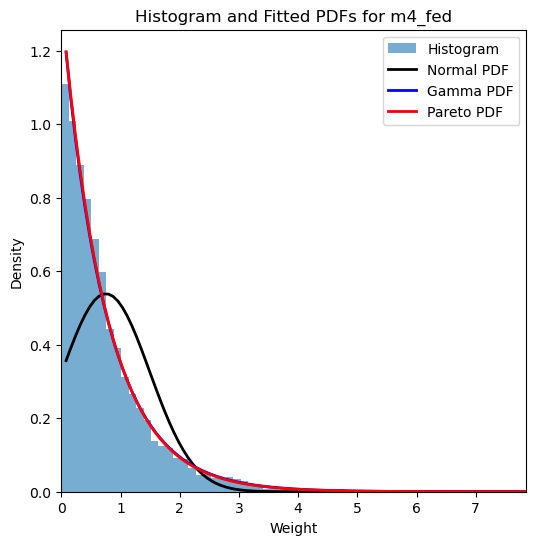

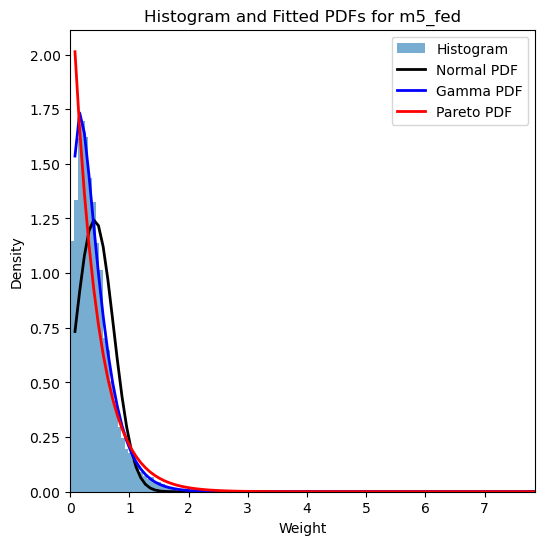

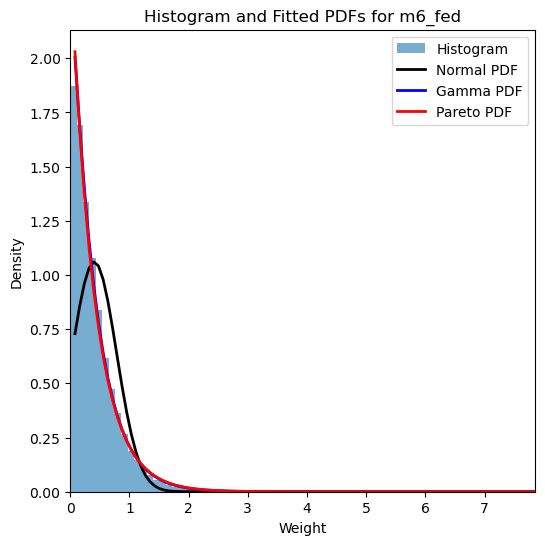

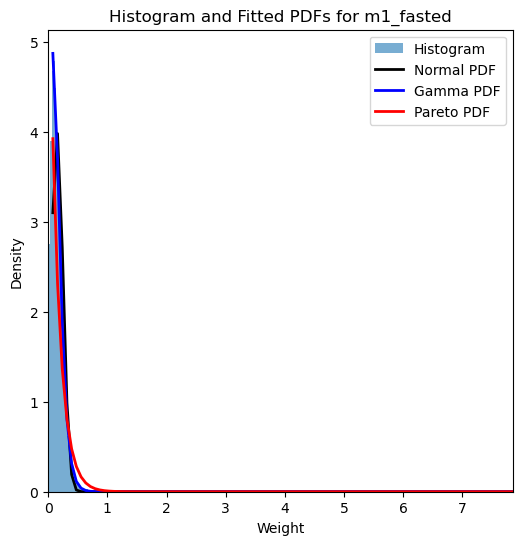

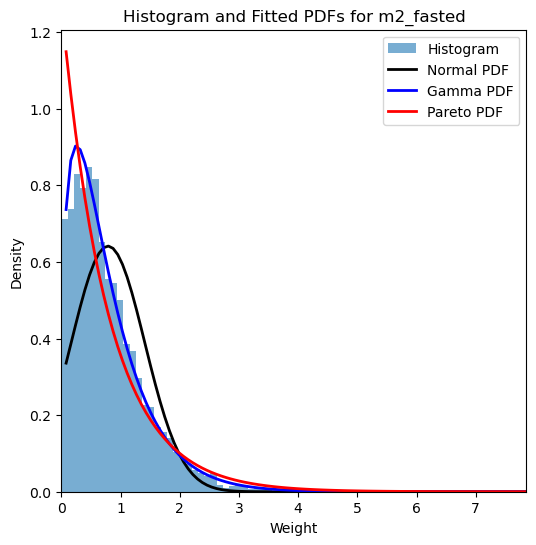

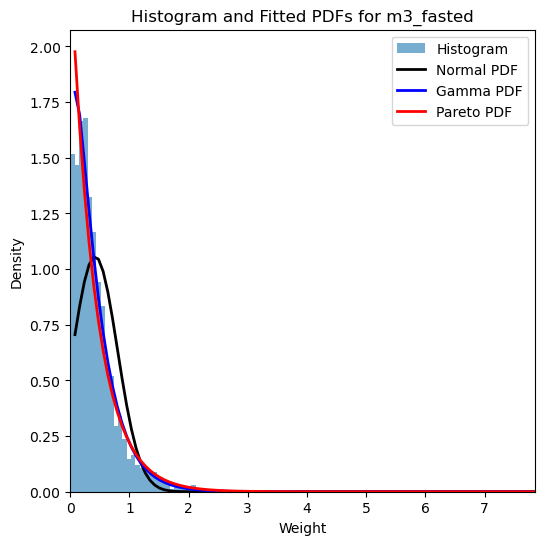

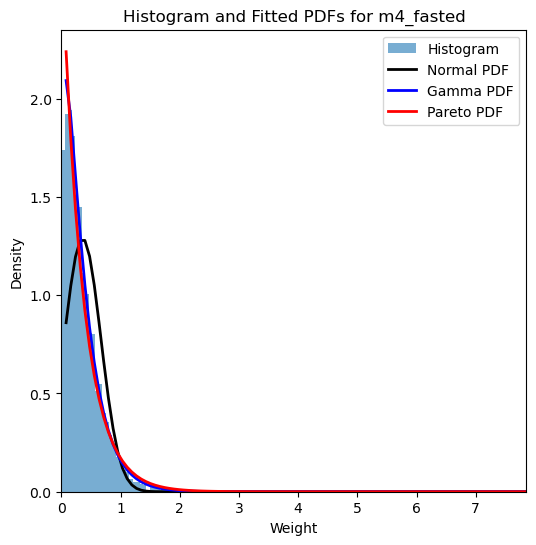

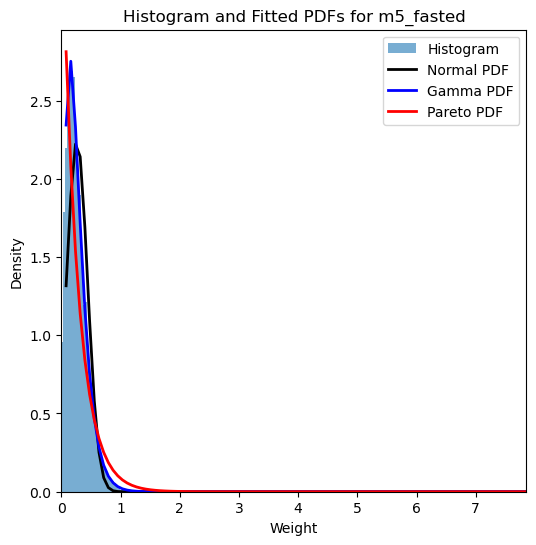

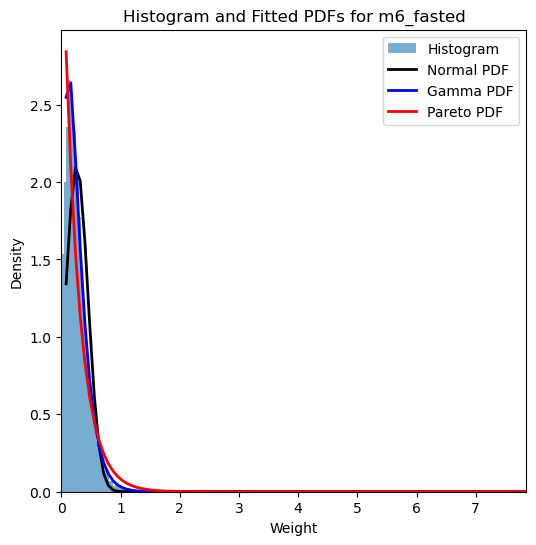

{'m1_fed': {'normal': 26353.37936979158, 'gamma': 5379.937750401894, 'pareto': 6261.680159156089}, 'm2_fed': {'normal': 7326.6665905449045, 'gamma': 4380.899652361266, 'pareto': 4381.328886674781}, 'm3_fed': {'normal': 12993.072300503618, 'gamma': 10183.599871464463, 'pareto': 10200.180186872885}, 'm4_fed': {'normal': 19294.5485362251, 'gamma': 12322.000076500171, 'pareto': 12321.937693622918}, 'm5_fed': {'normal': 3885.2885759759765, 'gamma': 782.3537403861033, 'pareto': 1473.7690246783243}, 'm6_fed': {'normal': 19699.175417761224, 'gamma': 4275.920979582323, 'pareto': 4291.430290793685}}
{'m1_fasted': {'normal': -36348.42112527869, 'gamma': -42708.82593187625, 'pareto': -36744.72403814039}, 'm2_fasted': {'normal': 9829.604005608806, 'gamma': 7650.088159215634, 'pareto': 7920.978677037043}, 'm3_fasted': {'normal': 2539.63670077845, 'gamma': 677.4562560164496, 'pareto': 742.1185107634769}, 'm4_fasted': {'normal': 3388.5758996934997, 'gamma': -537.5805424607729, 'pareto': -379.018917304

In [22]:
from scipy.stats import norm, gamma, pareto
import numpy as np
import matplotlib.pyplot as plt

# Calculate global x-limits
all_weights_nn = np.concatenate([matrix.flatten() for matrix in connectivity_matrices_nn_fed.values()] +
                                [matrix.flatten() for matrix in connectivity_matrices_nn_fasted.values()])
all_weights_nn = all_weights_nn[all_weights_nn != 0]  # Remove zero weights
global_xmin_nn, global_xmax_nn = 0, max(all_weights_nn)

fitted_params_nn_fed = {}
aic_results_nn_fed = {}
for key, matrix in connectivity_matrices_nn_fed.items():
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization
    
    # Fit a normal distribution to the data
    params_normal = norm.fit(weights)
    fitted_params_nn_fed[key] = {'normal': params_normal}
    
    # Fit a gamma distribution to the data
    params_gamma = gamma.fit(weights)
    fitted_params_nn_fed[key]['gamma'] = params_gamma
    
    # Fit a power law (Pareto) distribution to the data
    params_pareto = pareto.fit(weights)
    fitted_params_nn_fed[key]['pareto'] = params_pareto
    
    x = np.linspace(global_xmin_nn, global_xmax_nn, 100)
    
    # Plot the histogram and fitted PDFs
    plt.figure(figsize=(6, 6))
    plt.hist(weights, bins=50, density=True, alpha=0.6, label='Histogram')
    
    p_norm = norm.pdf(x[1:], *fitted_params_nn_fed[key]['normal'])
    plt.plot(x[1:], p_norm, 'k', linewidth=2, label='Normal PDF')
    
    p_gamma = gamma.pdf(x[1:], *fitted_params_nn_fed[key]['gamma'])
    plt.plot(x[1:], p_gamma, 'b', linewidth=2, label='Gamma PDF')
    
    p_pareto = pareto.pdf(x[1:], *params_pareto)
    plt.plot(x[1:], p_pareto, 'r', linewidth=2, label='Pareto PDF')
    
    plt.title(f'Histogram and Fitted PDFs for {key}')
    plt.xlabel('Weight')
    plt.ylabel('Density')
    plt.xlim(global_xmin_nn, global_xmax_nn)
    plt.legend()
    plt.show()
    
    # Calculate AIC
    log_likelihood_normal = np.sum(np.log(norm.pdf(weights, *params_normal)))
    log_likelihood_gamma = np.sum(np.log(gamma.pdf(weights, *params_gamma)))
    log_likelihood_pareto = np.sum(np.log(pareto.pdf(weights, *params_pareto)))
    
    aic_normal = 2 * len(params_normal) - 2 * log_likelihood_normal
    aic_gamma = 2 * len(params_gamma) - 2 * log_likelihood_gamma
    aic_pareto = 2 * len(params_pareto) - 2 * log_likelihood_pareto
    
    aic_results_nn_fed[key] = {'normal': aic_normal, 'gamma': aic_gamma, 'pareto': aic_pareto}

fitted_params_nn_fasted = {}
aic_results_nn_fasted = {}
for key, matrix in connectivity_matrices_nn_fasted.items():
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization
    
    # Fit a normal distribution to the data
    params_normal = norm.fit(weights)
    fitted_params_nn_fasted[key] = {'normal': params_normal}
    
    # Fit a gamma distribution to the data
    params_gamma = gamma.fit(weights)
    fitted_params_nn_fasted[key]['gamma'] = params_gamma
    
    # Fit a power law (Pareto) distribution to the data
    params_pareto = pareto.fit(weights)
    fitted_params_nn_fasted[key]['pareto'] = params_pareto
    
    x = np.linspace(global_xmin_nn, global_xmax_nn, 100)
    
    # Plot the histogram and fitted PDFs
    plt.figure(figsize=(6, 6))
    plt.hist(weights, bins=50, density=True, alpha=0.6, label='Histogram')
    
    p_norm = norm.pdf(x[1:], *params_normal)
    plt.plot(x[1:], p_norm, 'k', linewidth=2, label='Normal PDF')
    
    p_gamma = gamma.pdf(x[1:], *params_gamma)
    plt.plot(x[1:], p_gamma, 'b', linewidth=2, label='Gamma PDF')
    
    p_pareto = pareto.pdf(x[1:], *params_pareto)
    plt.plot(x[1:], p_pareto, 'r', linewidth=2, label='Pareto PDF')
    
    plt.title(f'Histogram and Fitted PDFs for {key}')
    plt.xlabel('Weight')
    plt.ylabel('Density')
    plt.xlim(global_xmin_nn, global_xmax_nn)
    plt.legend()
    plt.show()
    
    # Calculate AIC
    log_likelihood_normal = np.sum(np.log(norm.pdf(weights, *params_normal)))
    log_likelihood_gamma = np.sum(np.log(gamma.pdf(weights, *params_gamma)))
    log_likelihood_pareto = np.sum(np.log(pareto.pdf(weights, *params_pareto)))
    
    aic_normal = 2 * len(params_normal) - 2 * log_likelihood_normal
    aic_gamma = 2 * len(params_gamma) - 2 * log_likelihood_gamma
    aic_pareto = 2 * len(params_pareto) - 2 * log_likelihood_pareto
    
    aic_results_nn_fasted[key] = {'normal': aic_normal, 'gamma': aic_gamma, 'pareto': aic_pareto}

# Save the AIC results
print(aic_results_nn_fed)
print(aic_results_nn_fasted)


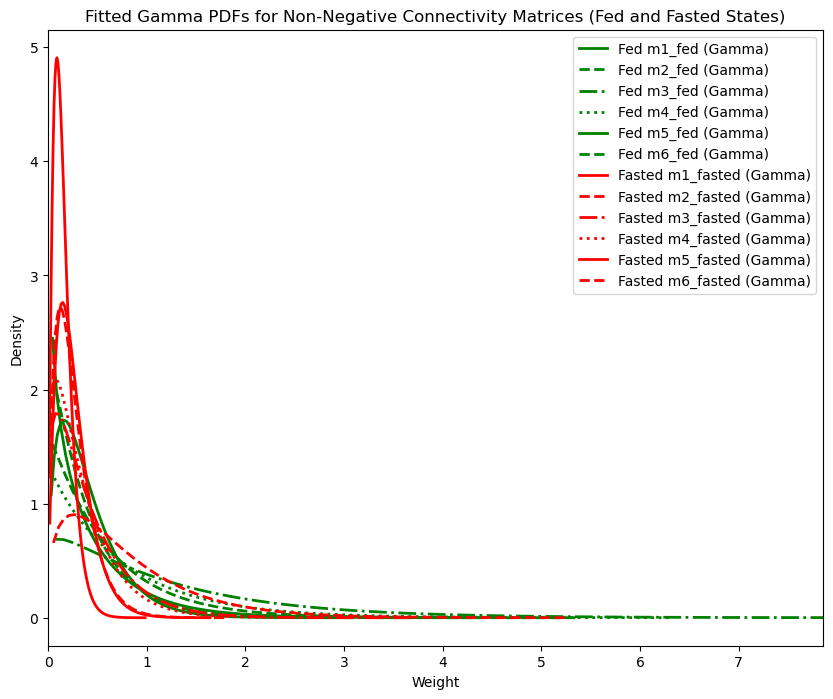

In [23]:
# Define line styles for different PDFs
line_styles = ['-', '--', '-.', ':', '-', '--']

# Initialize a figure for the plot
plt.figure(figsize=(10, 8))

# Iterate over each non-negative connectivity matrix in connectivity_matrices_nn_fed
for i, (key, matrix) in enumerate(connectivity_matrices_nn_fed.items()):
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization

    # Generate the x values for the PDF
    xmin, xmax = min(weights), max(weights)
    x = np.linspace(xmin, xmax, 100)
    p = gamma.pdf(x[1:], *fitted_params_nn_fed[key]['gamma'])

    # Plot the PDF in green
    plt.plot(x[1:], p, line_styles[i % len(line_styles)], color='g', linewidth=2, label=f'Fed {key} (Gamma)')

# Iterate over each non-negative connectivity matrix in connectivity_matrices_nn_fasted
for i, (key, matrix) in enumerate(connectivity_matrices_nn_fasted.items()):
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization

    # Generate the x values for the PDF
    xmin, xmax = min(weights), max(weights)
    x = np.linspace(xmin, xmax, 100)
    p = gamma.pdf(x[1:], *fitted_params_nn_fasted[key]['gamma'])
    
    # Plot the PDF in red
    plt.plot(x[1:], p, line_styles[i % len(line_styles)], color='r', linewidth=2, label=f'Fasted {key} (Gamma)')

# Add title and labels
plt.title('Fitted Gamma PDFs for Non-Negative Connectivity Matrices (Fed and Fasted States)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()
# plt.ylim(0, 6)
plt.xlim(0, global_xmax_nn)
plt.show()

### Distribution by condition

#### Gamma distribution

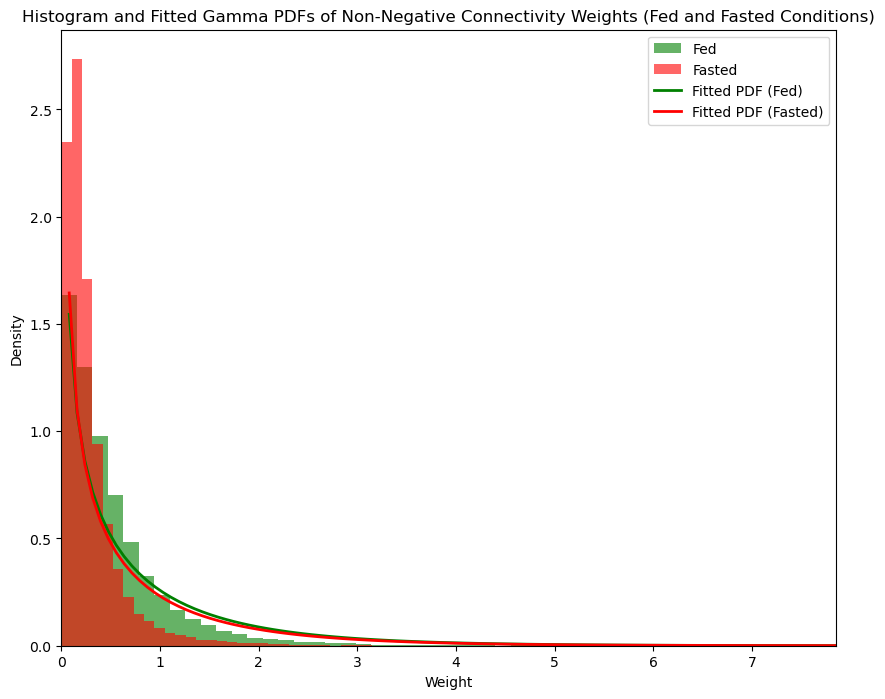

In [24]:
# Aggregate the connectivity weights for fed and fasted conditions
weights_nn_fed = np.concatenate([matrix.flatten() for matrix in connectivity_matrices_nn_fed.values()])
weights_nn_fed = weights_nn_fed[weights_nn_fed != 0]  # Remove zero weights

weights_nn_fasted = np.concatenate([matrix.flatten() for matrix in connectivity_matrices_nn_fasted.values()])
weights_nn_fasted = weights_nn_fasted[weights_nn_fasted != 0]  # Remove zero weights

# Fit a gamma distribution to the data
params_gamma_fed = gamma.fit(weights_nn_fed)
params_gamma_fasted = gamma.fit(weights_nn_fasted)

# Generate the x values for the PDF
xmin, xmax = min(min(weights_nn_fed), min(weights_nn_fasted)), max(max(weights_nn_fed), max(weights_nn_fasted))
x = np.linspace(xmin, xmax, 100)
p_gamma_fed = gamma.pdf(x, *params_gamma_fed)
p_gamma_fasted = gamma.pdf(x, *params_gamma_fasted)

# Plot histograms for both conditions
plt.figure(figsize=(10, 8))
plt.hist(weights_nn_fed, bins=50, density=True, alpha=0.6, color='g', label='Fed')
plt.hist(weights_nn_fasted, bins=50, density=True, alpha=0.6, color='r', label='Fasted')

# Plot the fitted PDFs
plt.plot(x[1:], p_gamma_fed[1:], 'g', linewidth=2, label='Fitted PDF (Fed)')
plt.plot(x[1:], p_gamma_fasted[1:], 'r', linewidth=2, label='Fitted PDF (Fasted)')
plt.title('Histogram and Fitted Gamma PDFs of Non-Negative Connectivity Weights (Fed and Fasted Conditions)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, global_xmax_nn)
plt.show()


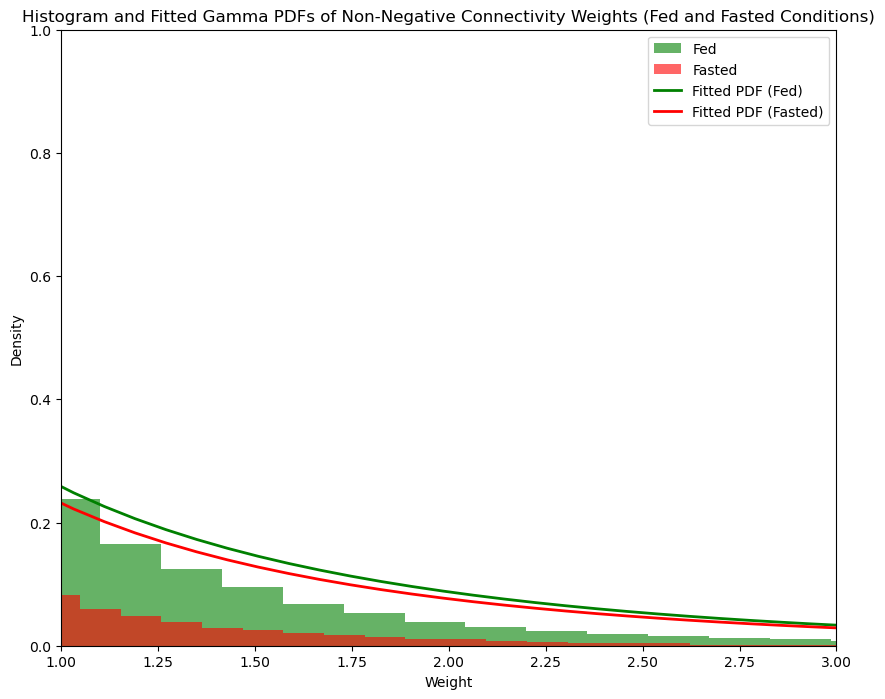

In [25]:
# Plot histograms for both conditions
plt.figure(figsize=(10, 8))
plt.hist(weights_nn_fed, bins=50, density=True, alpha=0.6, color='g', label='Fed')
plt.hist(weights_nn_fasted, bins=50, density=True, alpha=0.6, color='r', label='Fasted')

# Plot the fitted PDFs
plt.plot(x[1:], p_gamma_fed[1:], 'g', linewidth=2, label='Fitted PDF (Fed)')
plt.plot(x[1:], p_gamma_fasted[1:], 'r', linewidth=2, label='Fitted PDF (Fasted)')
plt.title('Histogram and Fitted Gamma PDFs of Non-Negative Connectivity Weights (Fed and Fasted Conditions)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()

# Set the x and y limits to zoom in
plt.xlim(1, 3)
plt.ylim(0, 1)

plt.show()

#### Power law distribution

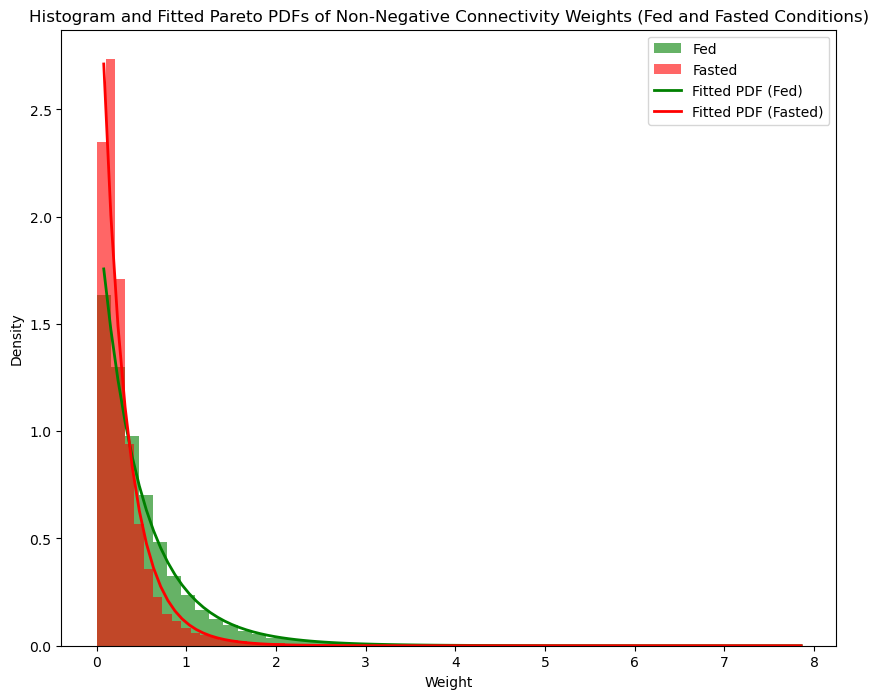

In [26]:
# Fit a Pareto distribution to the data
params_pareto_fed = pareto.fit(weights_nn_fed)
params_pareto_fasted = pareto.fit(weights_nn_fasted)

# Generate the x values for the PDF
xmin, xmax = min(min(weights_nn_fed), min(weights_nn_fasted)), max(max(weights_nn_fed), max(weights_nn_fasted))
x = np.linspace(xmin, xmax, 100)
p_pareto_fed = pareto.pdf(x[1:], *params_pareto_fed)
p_pareto_fasted = pareto.pdf(x[1:], *params_pareto_fasted)

# Plot histograms for both conditions
plt.figure(figsize=(10, 8))
plt.hist(weights_nn_fed, bins=50, density=True, alpha=0.6, color='g', label='Fed')
plt.hist(weights_nn_fasted, bins=50, density=True, alpha=0.6, color='r', label='Fasted')

# Plot the fitted PDFs
plt.plot(x[1:], p_pareto_fed, 'g', linewidth=2, label='Fitted PDF (Fed)')
plt.plot(x[1:], p_pareto_fasted, 'r', linewidth=2, label='Fitted PDF (Fasted)')
plt.title('Histogram and Fitted Pareto PDFs of Non-Negative Connectivity Weights (Fed and Fasted Conditions)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()
# plt.ylim(0, 6)
plt.show()


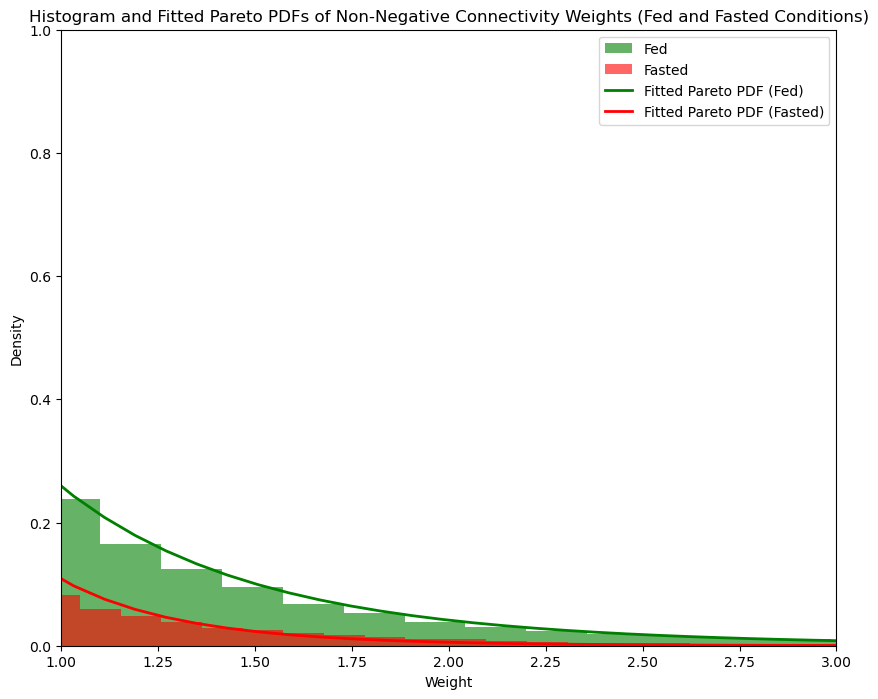

In [27]:
# Plot histograms for both conditions
plt.figure(figsize=(10, 8))
plt.hist(weights_nn_fed, bins=50, density=True, alpha=0.6, color='g', label='Fed')
plt.hist(weights_nn_fasted, bins=50, density=True, alpha=0.6, color='r', label='Fasted')

# Plot the fitted Pareto PDFs
plt.plot(x[1:], p_pareto_fed, 'g', linewidth=2, label='Fitted Pareto PDF (Fed)')
plt.plot(x[1:], p_pareto_fasted, 'r', linewidth=2, label='Fitted Pareto PDF (Fasted)')
plt.title('Histogram and Fitted Pareto PDFs of Non-Negative Connectivity Weights (Fed and Fasted Conditions)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()

# Set the x and y limits to zoom in
plt.xlim(1, 3)
plt.ylim(0, 1)

plt.show()

### Connectivity

In [28]:
# Show the sizes of the non-negative connectivity matrices for the fed state
for key, matrix in connectivity_matrices_nn_fed.items():
    print(f'Size of {key}: {matrix.shape}')

# Show the sizes of the non-negative connectivity matrices for the fasted state
for key, matrix in connectivity_matrices_nn_fasted.items():
    print(f'Size of {key}: {matrix.shape}')

Size of m1_fed: (155, 155)
Size of m2_fed: (69, 69)
Size of m3_fed: (68, 68)
Size of m4_fed: (97, 97)
Size of m5_fed: (84, 84)
Size of m6_fed: (152, 152)
Size of m1_fasted: (144, 144)
Size of m2_fasted: (73, 73)
Size of m3_fasted: (54, 54)
Size of m4_fasted: (84, 84)
Size of m5_fasted: (97, 97)
Size of m6_fasted: (114, 114)


In [29]:
def is_diagonalizable(matrix):
    """
    A matrix is diagonalizable if the sum of the geometric multiplicities 
    of its eigenvalues equals the size of the matrix (full set of linearly independent eigenvectors).
    """
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    rank = np.linalg.matrix_rank(eigenvectors)
    return rank == matrix.shape[0]

# Check diagonalizability for each non-negative connectivity matrix in the fed state
diagonalizable_nn_fed = {}
for key, matrix in connectivity_matrices_nn_fed.items():
    diagonalizable_nn_fed[key] = is_diagonalizable(matrix)
    print(f'{key} is diagonalizable: {diagonalizable_nn_fed[key]}')

# Check diagonalizability for each non-negative connectivity matrix in the fasted state
diagonalizable_nn_fasted = {}
for key, matrix in connectivity_matrices_nn_fasted.items():
    diagonalizable_nn_fasted[key] = is_diagonalizable(matrix)
    print(f'{key} is diagonalizable: {diagonalizable_nn_fasted[key]}')


m1_fed is diagonalizable: True
m2_fed is diagonalizable: True
m3_fed is diagonalizable: True
m4_fed is diagonalizable: True
m5_fed is diagonalizable: True
m6_fed is diagonalizable: True
m1_fasted is diagonalizable: True
m2_fasted is diagonalizable: True
m3_fasted is diagonalizable: True
m4_fasted is diagonalizable: True
m5_fasted is diagonalizable: True
m6_fasted is diagonalizable: True


In [30]:
def is_normal_matrix(matrix):
    """
    Check if a matrix is a normal matrix.
    A matrix A is normal if A * A^H = A^H * A, where A^H is the conjugate transpose of A.
    """
    return np.allclose(matrix @ matrix.T.conj(), matrix.T.conj() @ matrix)

# Check normality for each non-negative connectivity matrix in the fed state
normal_matrices_nn_fed = {}
for key, matrix in connectivity_matrices_nn_fed.items():
    normal_matrices_nn_fed[key] = is_normal_matrix(matrix)
    print(f'{key} is a normal matrix: {normal_matrices_nn_fed[key]}')

# Check normality for each non-negative connectivity matrix in the fasted state
normal_matrices_nn_fasted = {}
for key, matrix in connectivity_matrices_nn_fasted.items():
    normal_matrices_nn_fasted[key] = is_normal_matrix(matrix)
    print(f'{key} is a normal matrix: {normal_matrices_nn_fasted[key]}')

m1_fed is a normal matrix: False
m2_fed is a normal matrix: False
m3_fed is a normal matrix: False
m4_fed is a normal matrix: False
m5_fed is a normal matrix: False
m6_fed is a normal matrix: False
m1_fasted is a normal matrix: False
m2_fasted is a normal matrix: False
m3_fasted is a normal matrix: False
m4_fasted is a normal matrix: False
m5_fasted is a normal matrix: False
m6_fasted is a normal matrix: False


#### Eigendecomposition

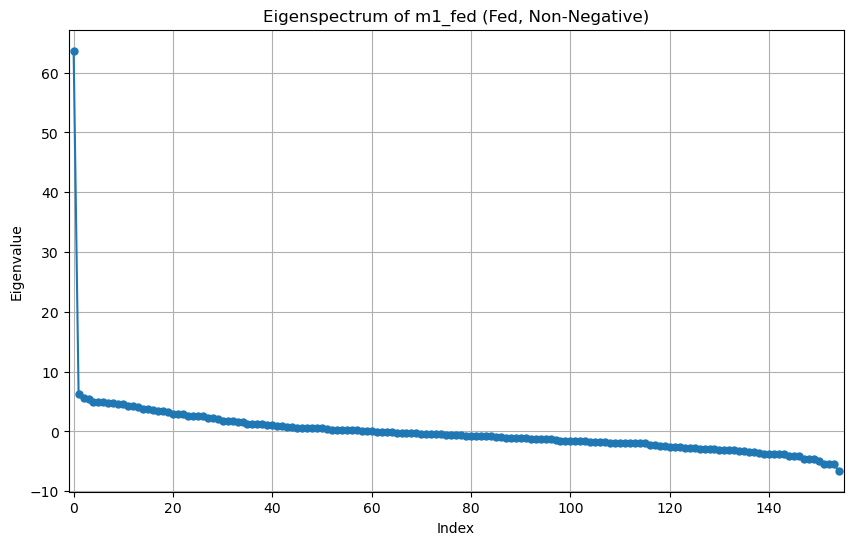

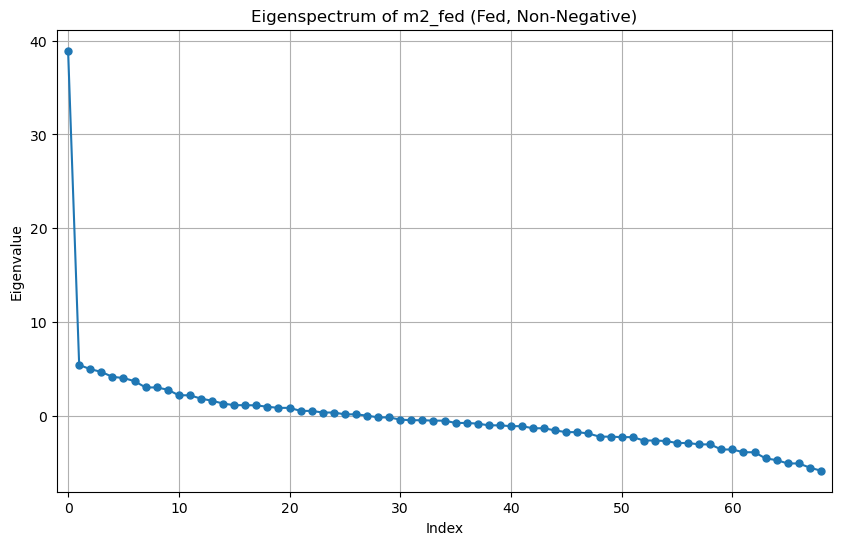

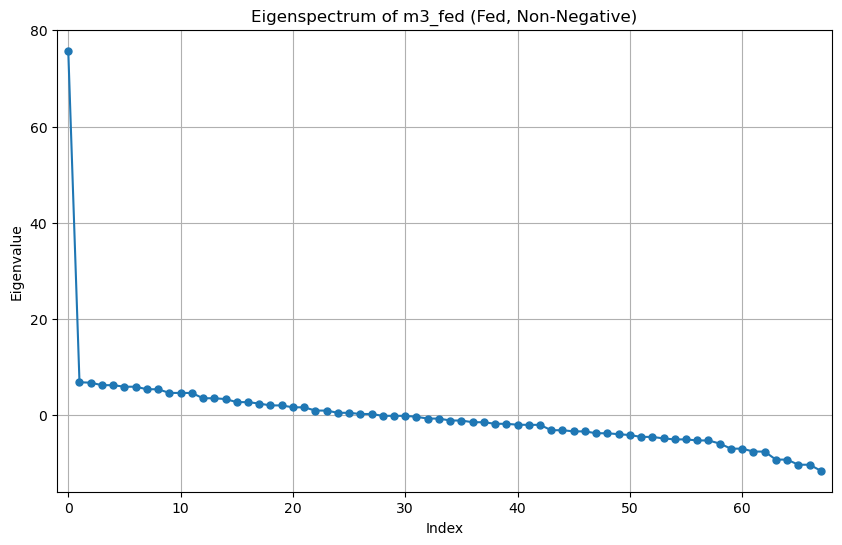

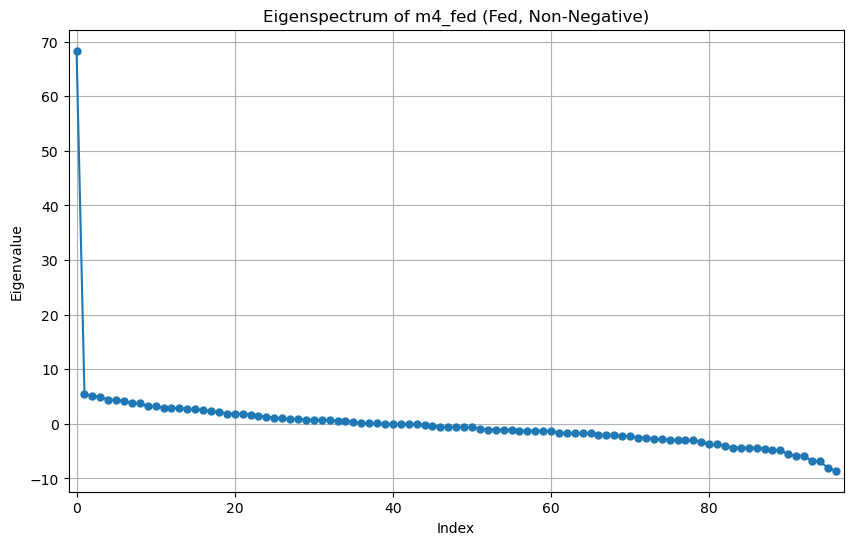

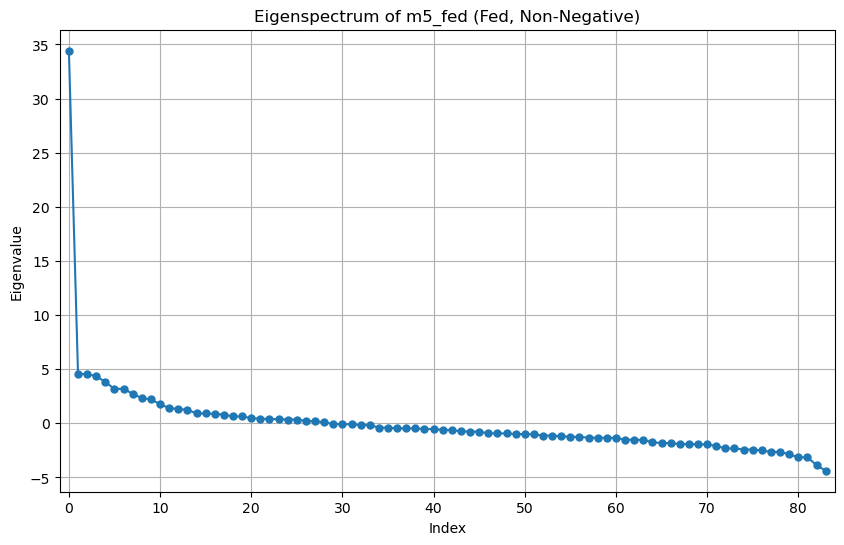

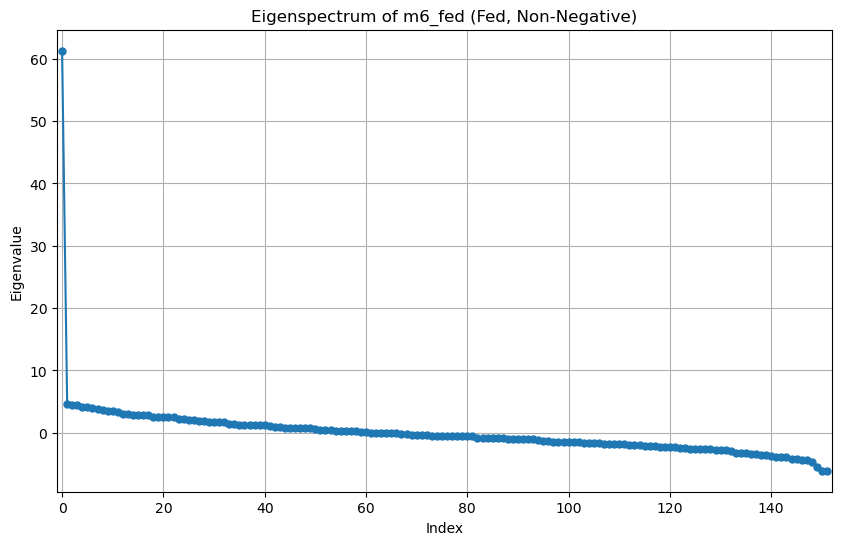

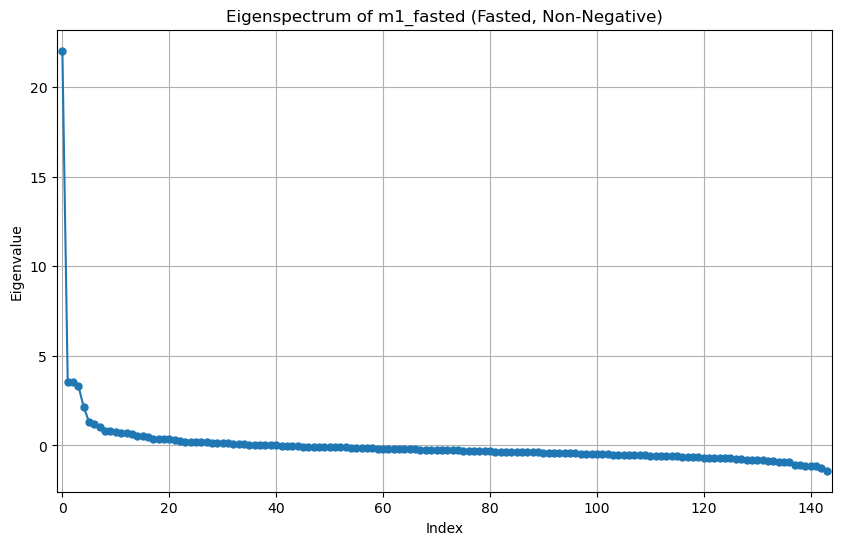

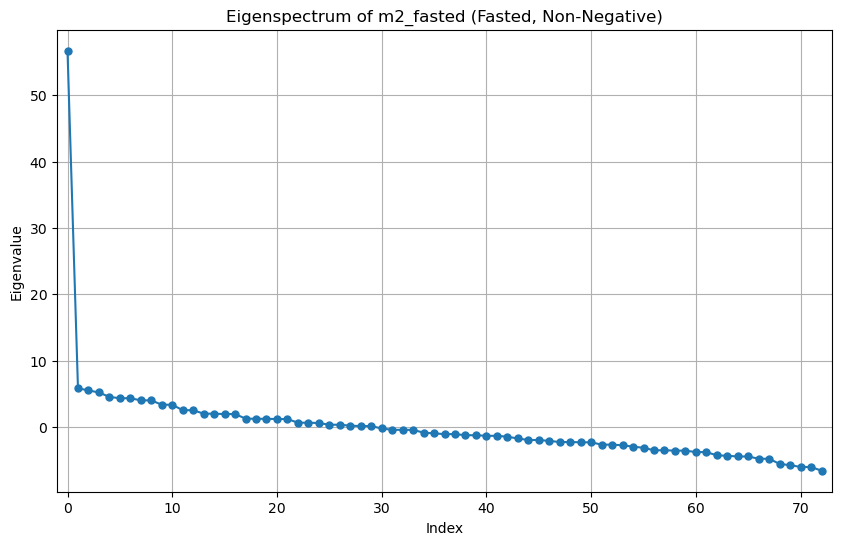

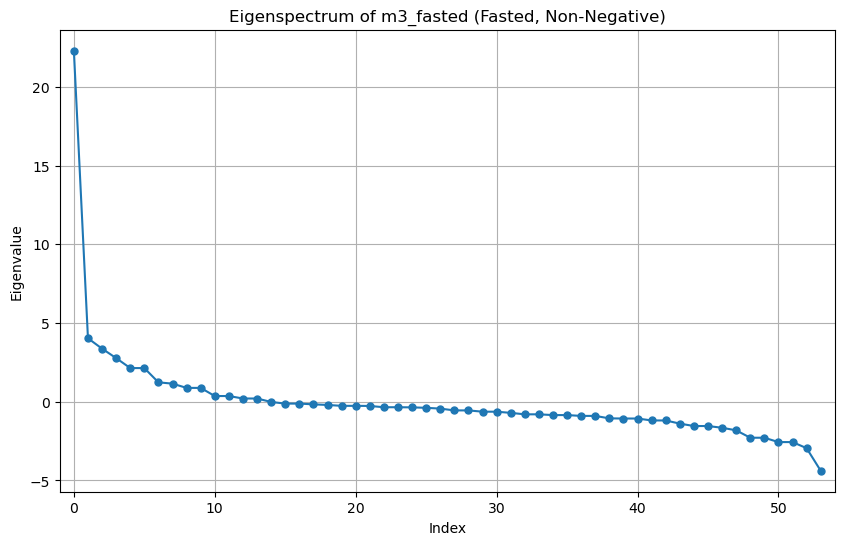

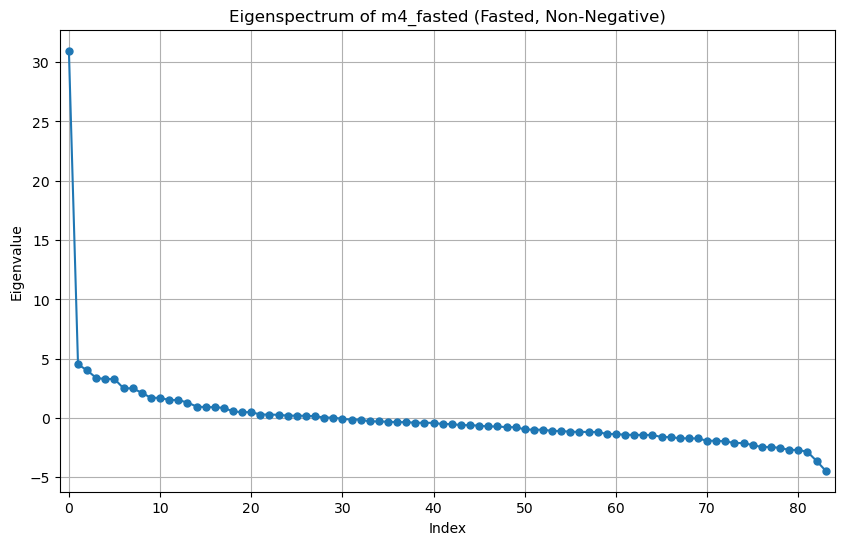

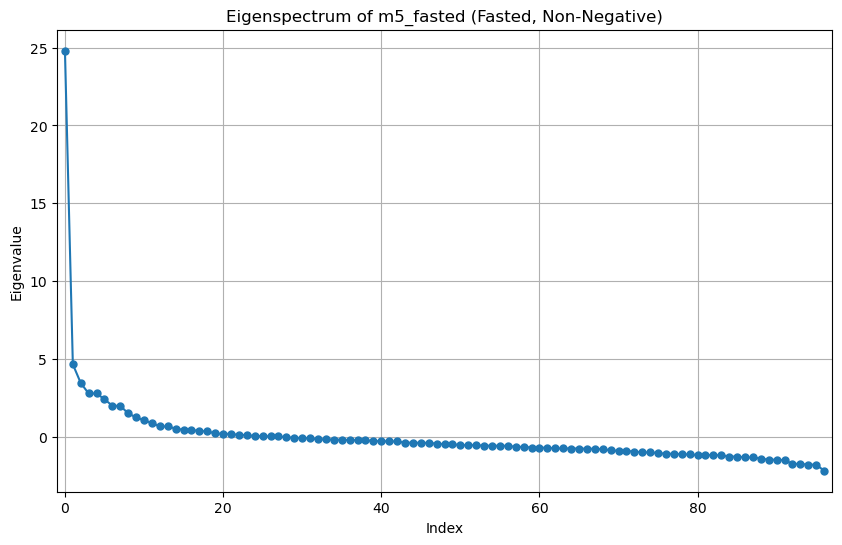

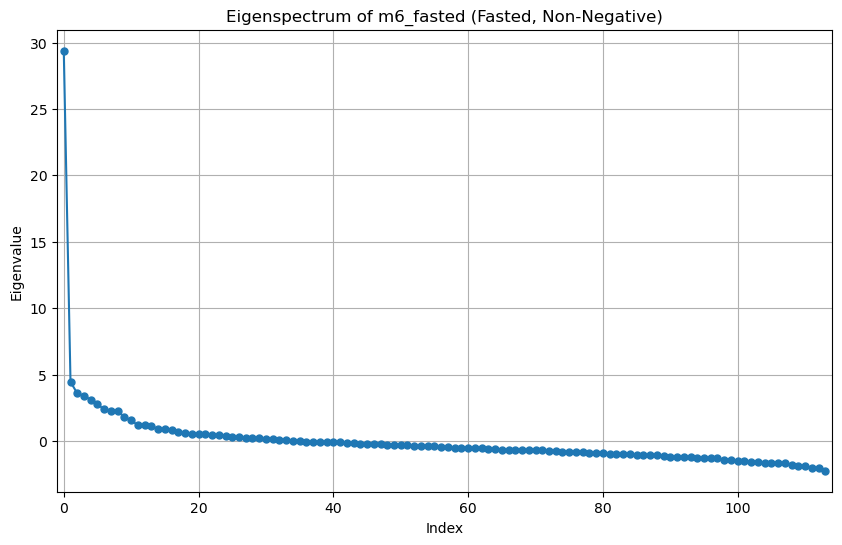

In [31]:
def plot_eigenspectrum(matrix, title):
    # Perform eigendocomposition
    eigenvalues, _ = np.linalg.eig(matrix)
    
    # Sort eigenvalues in descending order
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    # Plot the eigenspectrum
    plt.figure(figsize=(10, 6))
    plt.plot(eigenvalues, 'o-', markersize=5)
    plt.title(f'Eigenspectrum of {title}')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.xlim(-1, len(eigenvalues))  # Set x-axis limits
    plt.grid(True)
    plt.show()

# Plot eigenspectrum for each non-negative connectivity matrix in the fed state
for key, matrix in connectivity_matrices_nn_fed.items():
    plot_eigenspectrum(matrix, f'{key} (Fed, Non-Negative)')

# Plot eigenspectrum for each non-negative connectivity matrix in the fasted state
for key, matrix in connectivity_matrices_nn_fasted.items():
    plot_eigenspectrum(matrix, f'{key} (Fasted, Non-Negative)')

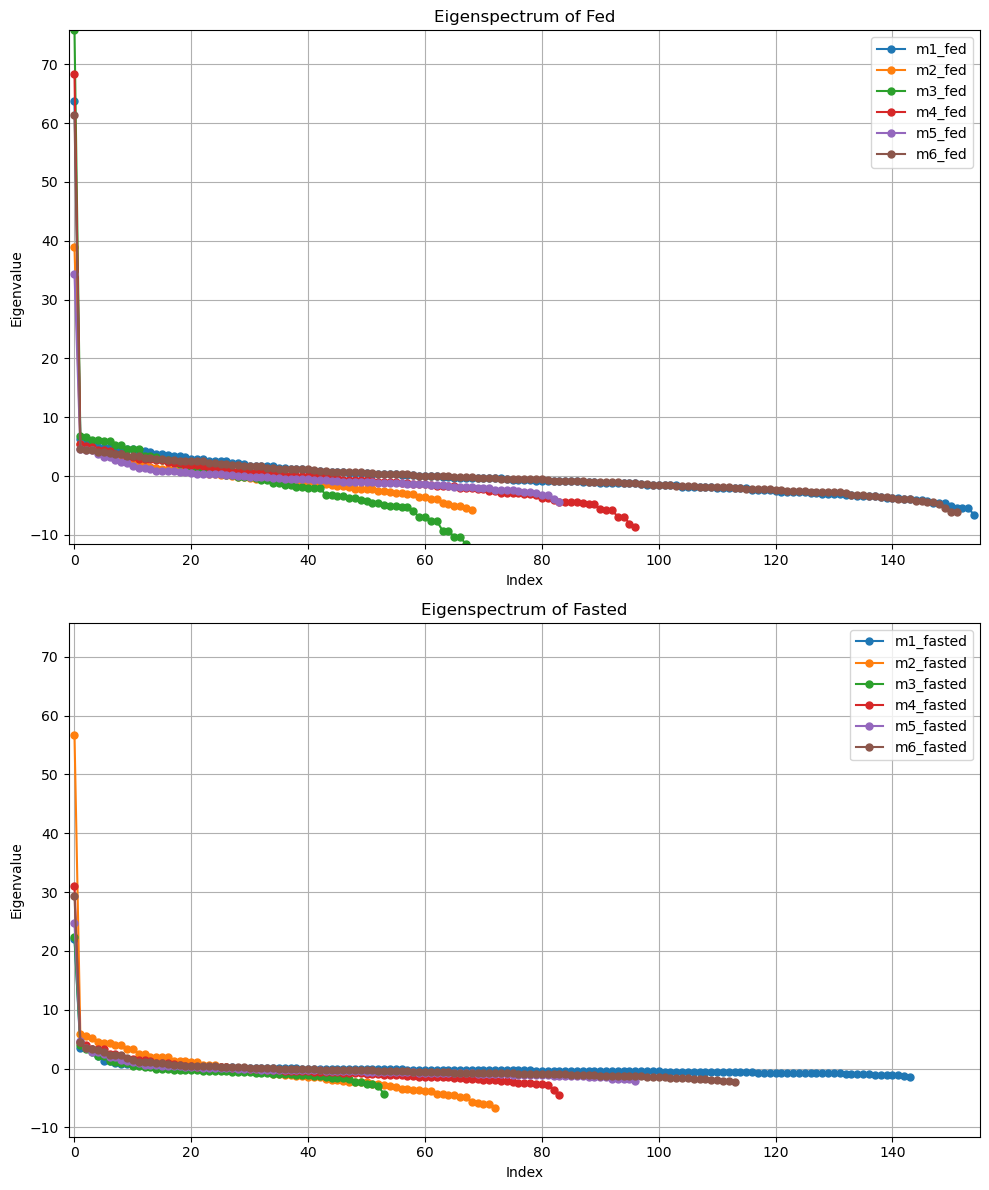

In [57]:
def plot_eigenspectrum(matrix, title, ax, label):
    # Perform eigendocomposition
    eigenvalues, _ = np.linalg.eig(matrix)
    
    # Sort eigenvalues in descending order
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    # Plot the eigenspectrum
    ax.plot(eigenvalues, 'o-', markersize=5, label=label)
    ax.set_title(f'Eigenspectrum of {title}')
    ax.set_xlabel('Index')
    ax.set_ylabel('Eigenvalue')
    ax.grid(True)
    return eigenvalues

# Initialize the figure and axes
fig, axs = plt.subplots(2, 1, figsize=(10, 12))

# Collect all eigenvalues to determine global min and max
all_eigenvalues = []
max_length = 0

# Plot eigenspectrum for each non-negative connectivity matrix in the fed state
for key, matrix in connectivity_matrices_nn_fed.items():
    eigenvalues = plot_eigenspectrum(matrix, f'Fed', axs[0], key)
    all_eigenvalues.extend(eigenvalues)
    max_length = max(max_length, len(eigenvalues))

# Plot eigenspectrum for each non-negative connectivity matrix in the fasted state
for key, matrix in connectivity_matrices_nn_fasted.items():
    eigenvalues = plot_eigenspectrum(matrix, f'Fasted', axs[1], key)
    all_eigenvalues.extend(eigenvalues)
    max_length = max(max_length, len(eigenvalues))

# Determine global min and max for eigenvalues
global_ymin, global_ymax = min(all_eigenvalues), max(all_eigenvalues)

# Set the same x and y limits for both subplots
for ax in axs:
    ax.set_xlim(-1, max_length)
    ax.set_ylim(global_ymin, global_ymax)

# Add legends
axs[0].legend()
axs[1].legend()

plt.tight_layout()
plt.show()

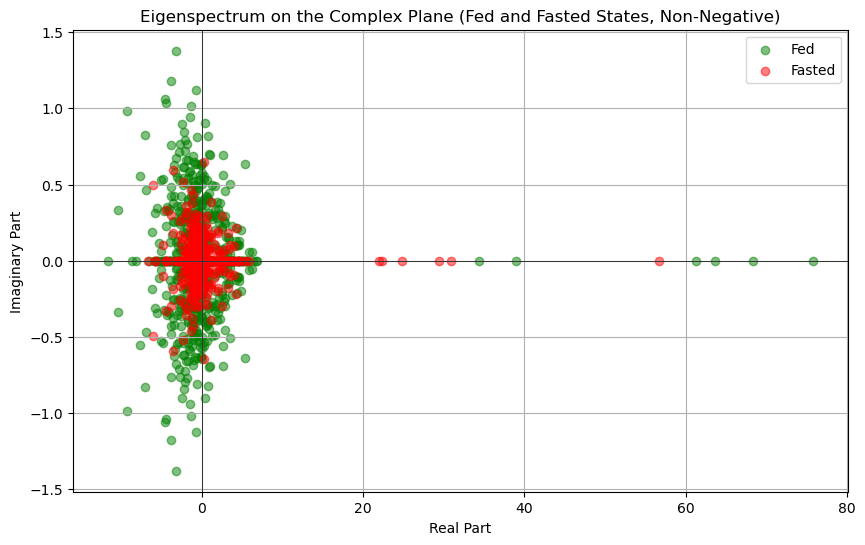

In [32]:
# Initialize a figure for the plot
plt.figure(figsize=(10, 6))

# Scatter all the eigenvalues for fed in green
for key, matrix in connectivity_matrices_nn_fed.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    plt.scatter(eigenvalues.real, eigenvalues.imag, color='g', alpha=0.5, label='Fed' if key == 'm1_fed' else "")

# Scatter all the eigenvalues for fasted in red
for key, matrix in connectivity_matrices_nn_fasted.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    plt.scatter(eigenvalues.real, eigenvalues.imag, color='r', alpha=0.5, label='Fasted' if key == 'm1_fasted' else "")

# Add title and labels
plt.title('Eigenspectrum on the Complex Plane (Fed and Fasted States, Non-Negative)')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.show()

##### Time constants

In [33]:
def calculate_time_constants(eigenvalues):
    """
    Calculate the time constants for each eigenmode.
    
    Parameters:
    eigenvalues (numpy.ndarray): Array of eigenvalues.
    
    Returns:
    numpy.ndarray: Array of time constants.
    """
    real_parts = np.real(eigenvalues)
    time_constants = np.abs(1 / np.log(np.abs(real_parts)))
    return time_constants

# Calculate time constants for each non-negaitve connectivity matrix in the fed state
time_constants_nn_fed = {}
for key, matrix in connectivity_matrices_nn_fed.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
    time_constants_nn_fed[key] = calculate_time_constants(eigenvalues)

# Calculate time constants for each non-negaitve connectivity matrix in the fasted state
time_constants_nn_fasted = {}
for key, matrix in connectivity_matrices_nn_fasted.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
    time_constants_nn_fasted[key] = calculate_time_constants(eigenvalues)

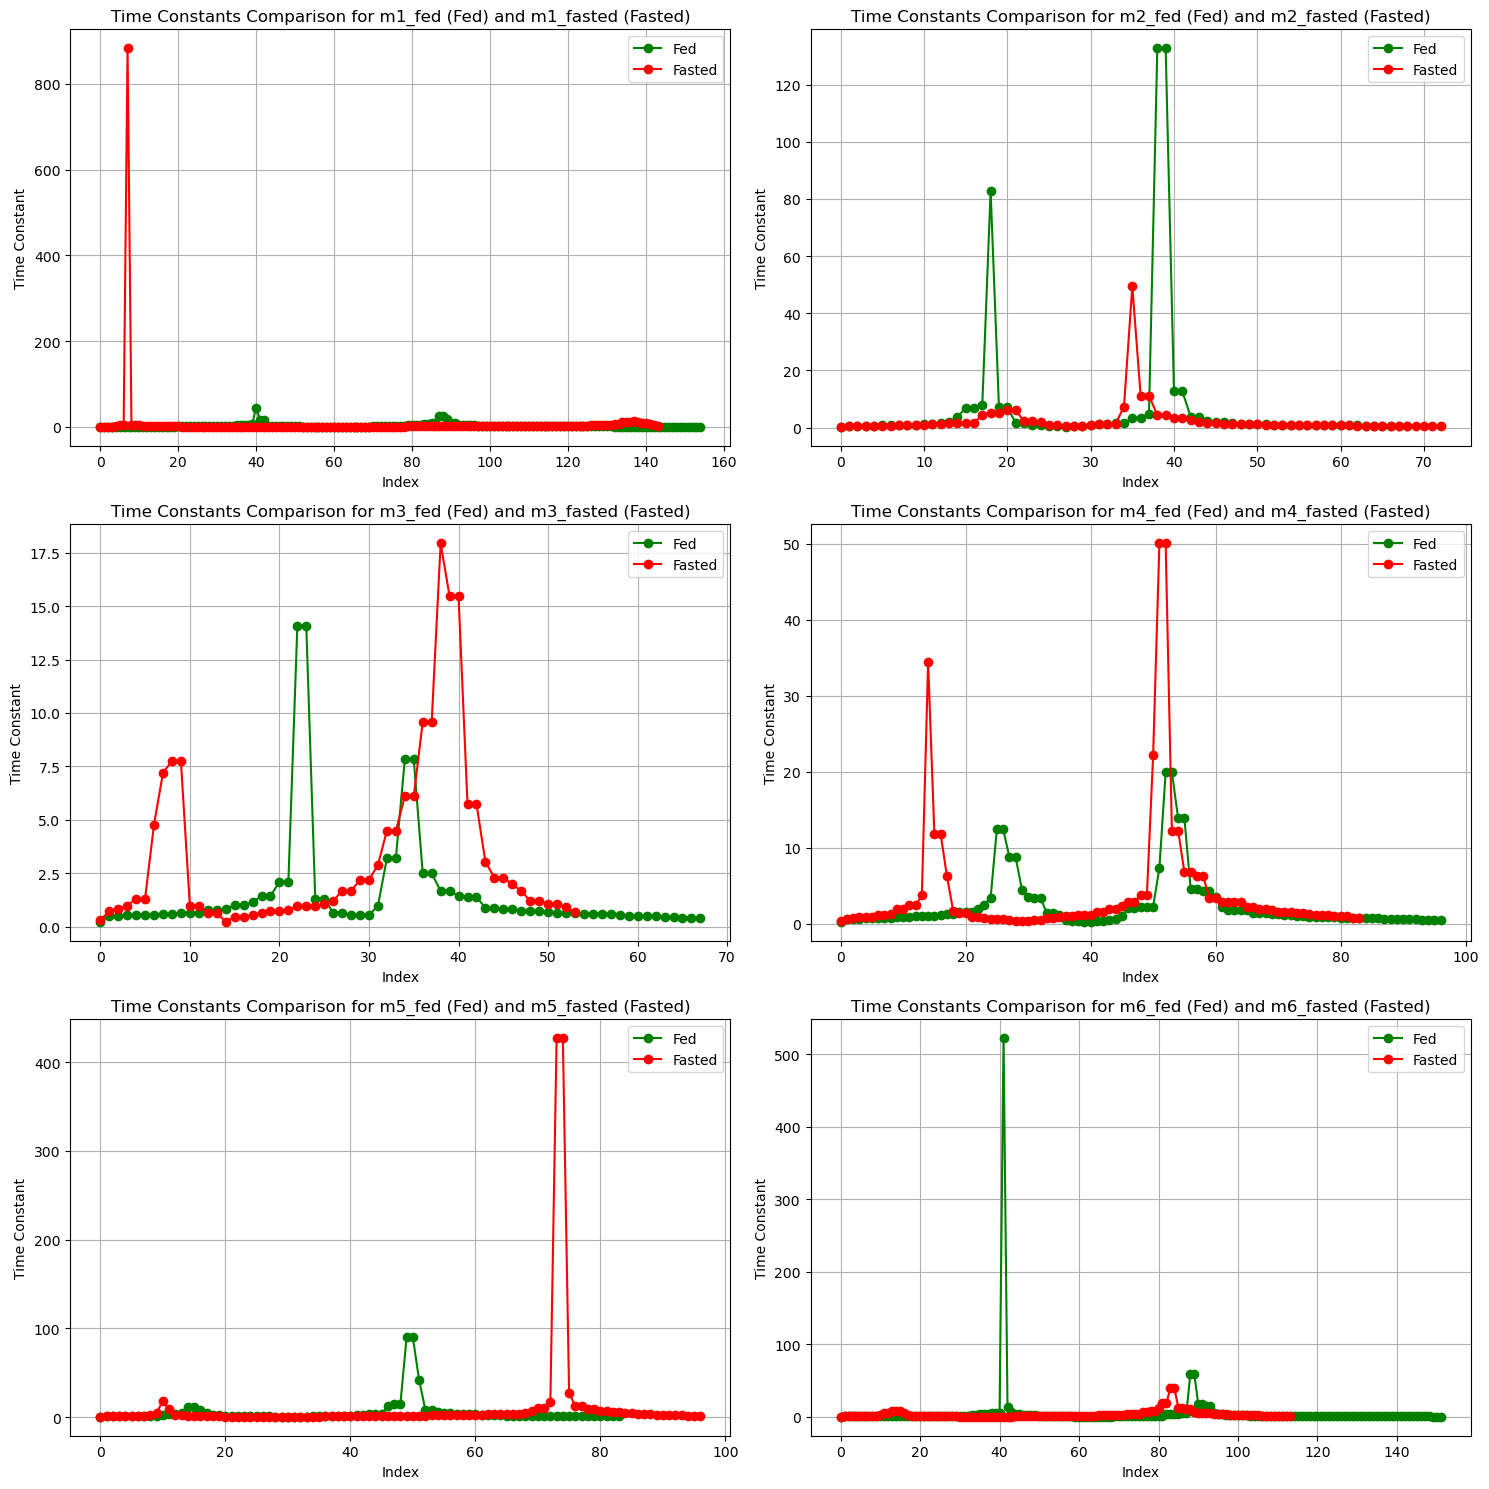

In [34]:
# List of animal keys for fed and fasted states
animal_keys_fed = list(time_constants_nn_fed.keys())
animal_keys_fasted = list(time_constants_nn_fasted.keys())

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each animal and plot the time constants
for i, (key_fed, key_fasted) in enumerate(zip(animal_keys_fed, animal_keys_fasted)):
    # Get the time constants for the current animal in fed and fasted states
    time_constants_fed_animal = time_constants_nn_fed[key_fed]
    time_constants_fasted_animal = time_constants_nn_fasted[key_fasted]
    
    # Plot the time constants for fed state
    axs[i].plot(time_constants_fed_animal, 'o-', color='g', label='Fed')
    
    # Plot the time constants for fasted state
    axs[i].plot(time_constants_fasted_animal, 'o-', color='r', label='Fasted')
    
    # Add title and labels
    axs[i].set_title(f'Time Constants Comparison for {key_fed} (Fed) and {key_fasted} (Fasted)')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Time Constant')
    axs[i].legend()
    axs[i].grid(True)
    
# Adjust layout
plt.tight_layout()
plt.show()

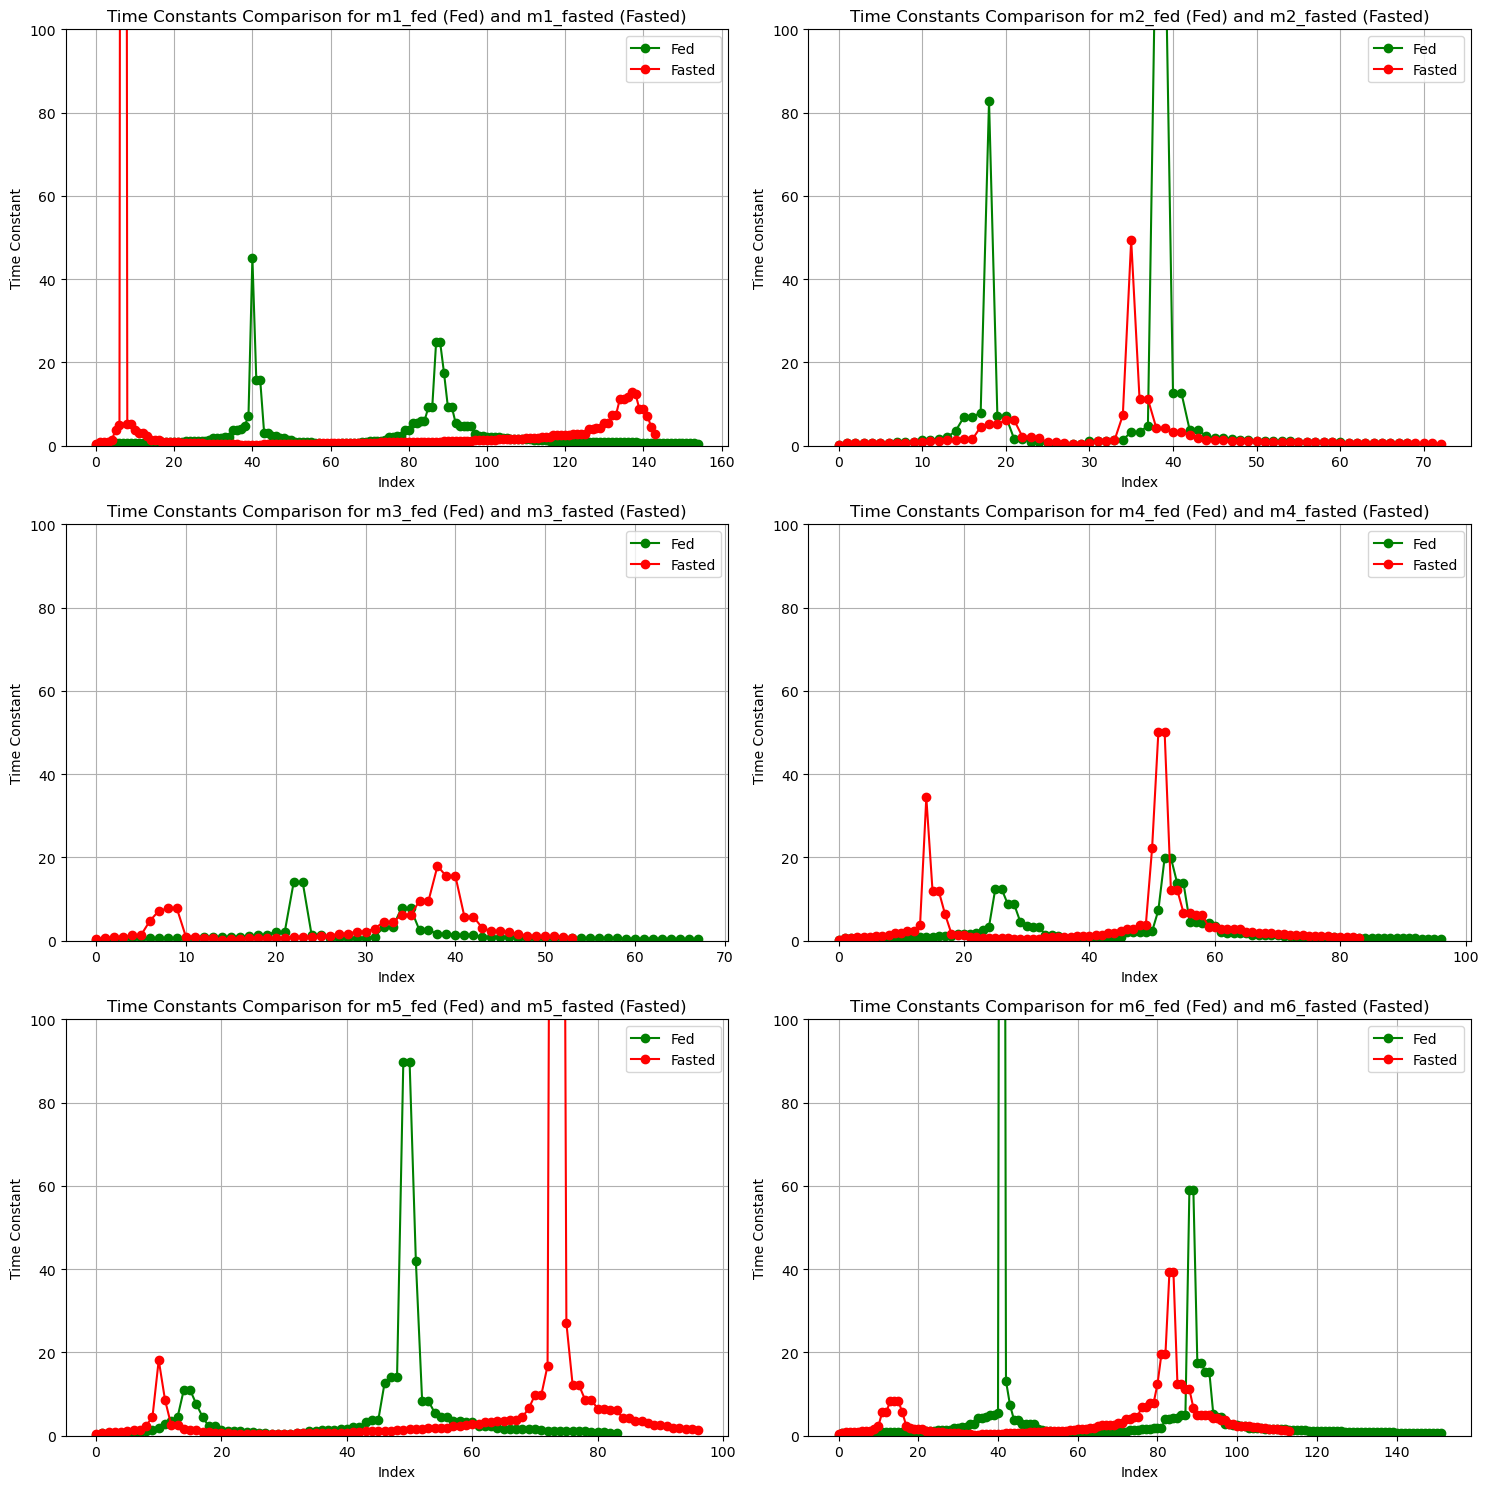

In [35]:
# List of animal keys for fed and fasted states
animal_keys_fed = list(time_constants_nn_fed.keys())
animal_keys_fasted = list(time_constants_nn_fasted.keys())

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each animal and plot the time constants
for i, (key_fed, key_fasted) in enumerate(zip(animal_keys_fed, animal_keys_fasted)):
    # Get the time constants for the current animal in fed and fasted states
    time_constants_fed_animal = time_constants_nn_fed[key_fed]
    time_constants_fasted_animal = time_constants_nn_fasted[key_fasted]
    
    # Plot the time constants for fed state
    axs[i].plot(time_constants_fed_animal, 'o-', color='g', label='Fed')
    
    # Plot the time constants for fasted state
    axs[i].plot(time_constants_fasted_animal, 'o-', color='r', label='Fasted')
    
    # Add title and labels
    axs[i].set_title(f'Time Constants Comparison for {key_fed} (Fed) and {key_fasted} (Fasted)')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Time Constant')
    axs[i].legend()
    axs[i].grid(True)
    
    # Set y-axis limits
    axs[i].set_ylim(0, 100)

# Adjust layout
plt.tight_layout()
plt.show()

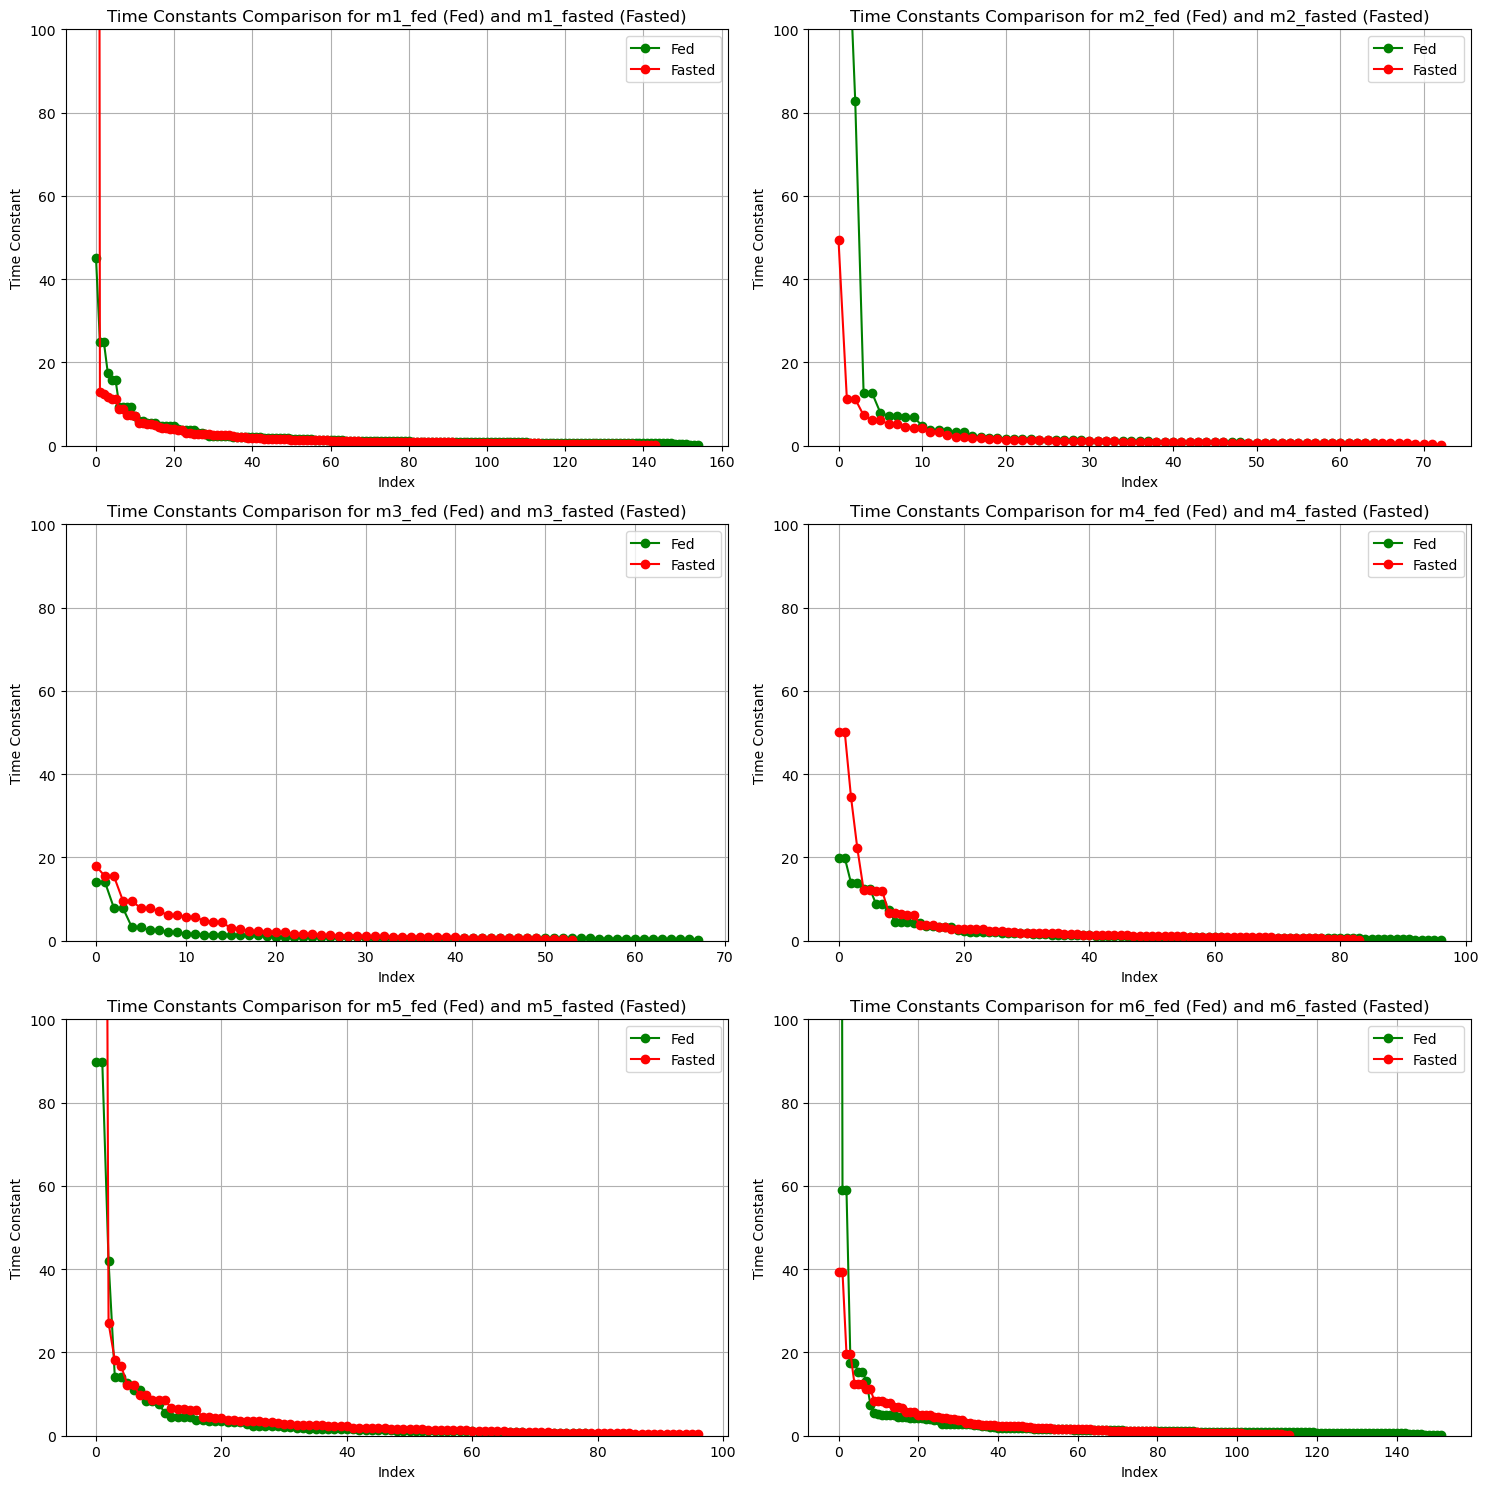

In [ ]:
# List of animal keys for fed and fasted states
animal_keys_fed = list(time_constants_nn_fed.keys())
animal_keys_fasted = list(time_constants_nn_fasted.keys())

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each animal and plot the time constants
for i, (key_fed, key_fasted) in enumerate(zip(animal_keys_fed, animal_keys_fasted)):
    # Get the time constants for the current animal in fed and fasted states
    time_constants_fed_animal = np.sort(time_constants_nn_fed[key_fed])[::-1]
    time_constants_fasted_animal = np.sort(time_constants_nn_fasted[key_fasted])[::-1]
    
    # Plot the time constants for fed state
    axs[i].plot(time_constants_fed_animal, 'o-', color='g', label='Fed')
    
    # Plot the time constants for fasted state
    axs[i].plot(time_constants_fasted_animal, 'o-', color='r', label='Fasted')
    
    # Add title and labels
    axs[i].set_title(f'Time Constants Comparison for {key_fed} (Fed) and {key_fasted} (Fasted)')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Time Constant')
    axs[i].legend()
    axs[i].grid(True)
    
    # Set y-axis limits
    axs[i].set_ylim(0, 100)

# Adjust layout
plt.tight_layout()
plt.show()

## Non-negative cell-coupled GLM using LASSO

In [38]:
connectivity_lasso_dir = '/home/charlesxu/local/data/JK_functionalConn/connectivity_matrices_pos_coef_lasso/connectivity_matrices'

# Load the non-negative connectivity matrices for the fed state
connectivity_matrices_lasso_fed = {}
for file_name in os.listdir(os.path.join(connectivity_lasso_dir, 'fed')):
    if file_name.endswith('.npy'):
        matrix_name = os.path.splitext(file_name)[0]
        matrix_key = '_'.join(matrix_name.split('_')[-4:-2])
        file_path = os.path.join(connectivity_lasso_dir, 'fed', file_name)
        connectivity_matrices_lasso_fed[matrix_key] = np.load(file_path)

# Sort the dictionary by the key
sorted_keys = sorted(connectivity_matrices_lasso_fed.keys(), key=lambda x: int(x.split('_')[0][1:]))
connectivity_matrices_lasso_fed = OrderedDict((key, connectivity_matrices_lasso_fed[key]) for key in sorted_keys)

# Load the non-negative connectivity matrices for the fasted state
connectivity_matrices_lasso_fasted = {}
for file_name in os.listdir(os.path.join(connectivity_lasso_dir, 'fasted')):
    if file_name.endswith('.npy'):
        matrix_name = os.path.splitext(file_name)[0]
        matrix_key = '_'.join(matrix_name.split('_')[-4:-2])
        file_path = os.path.join(connectivity_lasso_dir, 'fasted', file_name)
        connectivity_matrices_lasso_fasted[matrix_key] = np.load(file_path)

# Sort the dictionary by the key
sorted_keys = sorted(connectivity_matrices_lasso_fasted.keys(), key=lambda x: int(x.split('_')[0][1:]))
connectivity_matrices_lasso_fasted = OrderedDict((key, connectivity_matrices_lasso_fasted[key]) for key in sorted_keys)

### Individual distributions

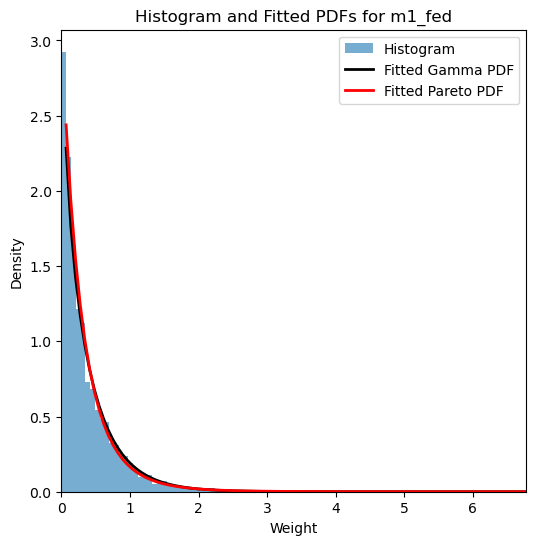

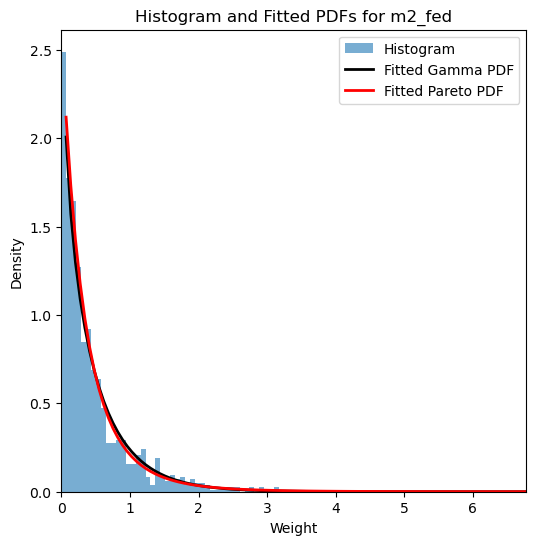

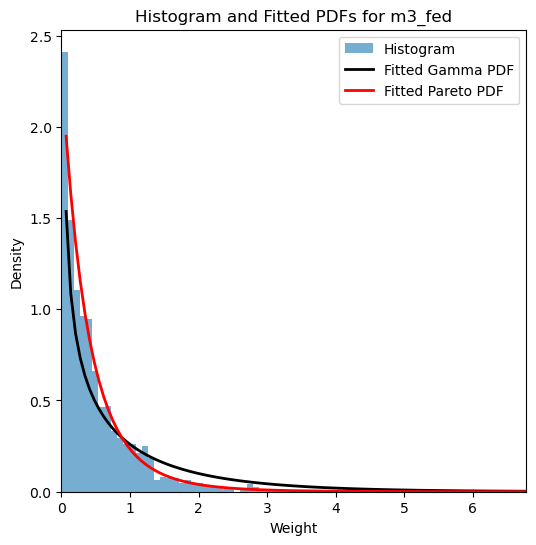

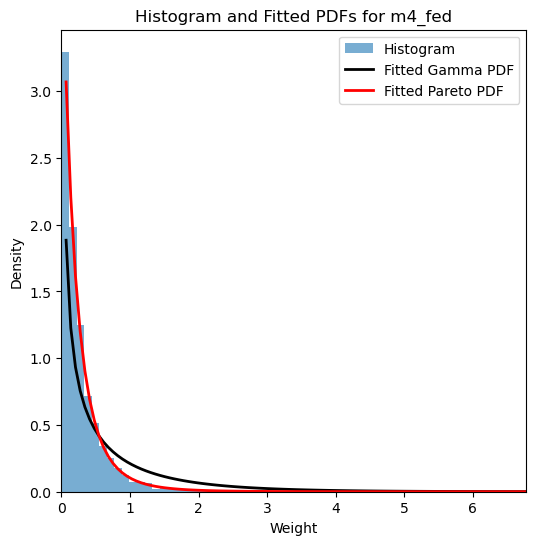

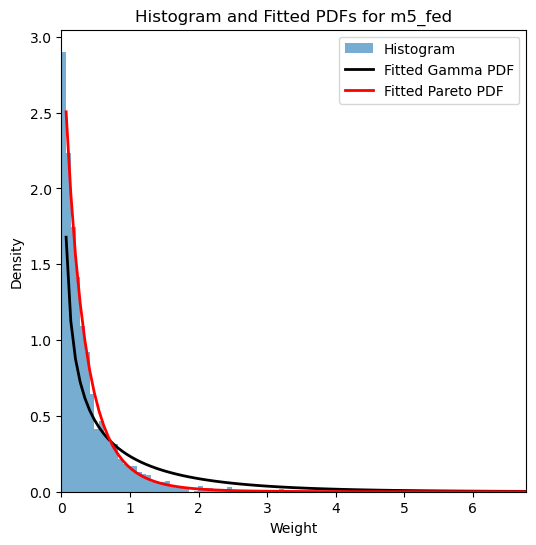

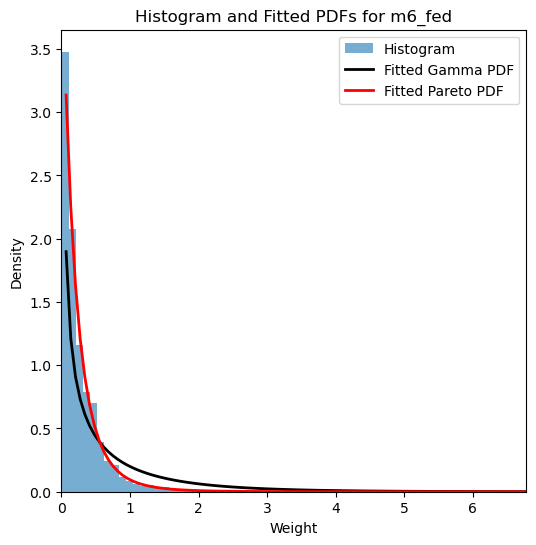

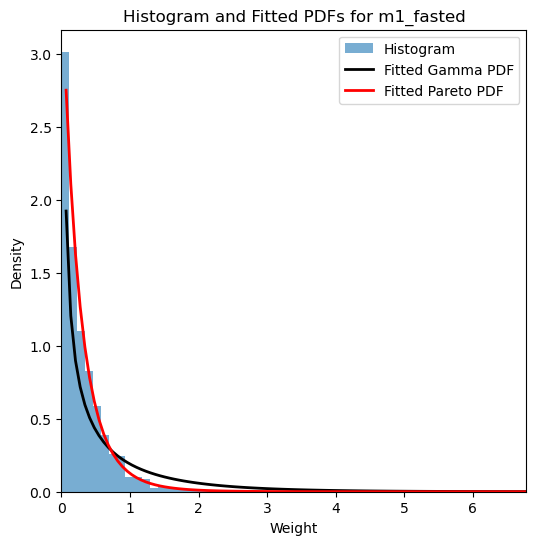

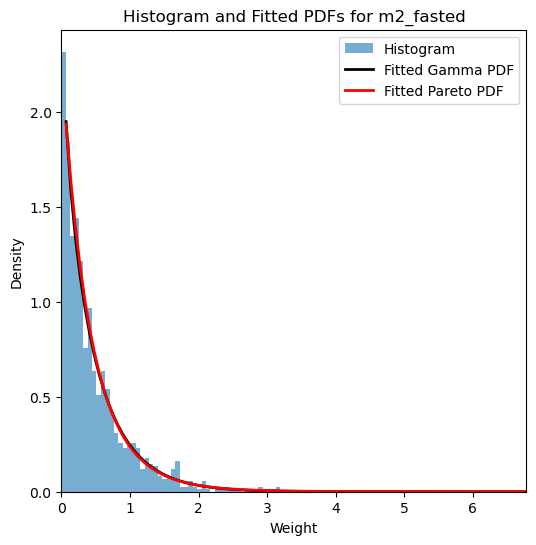

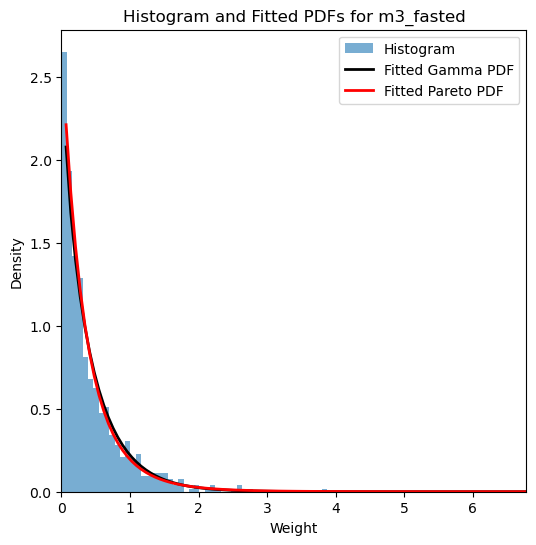

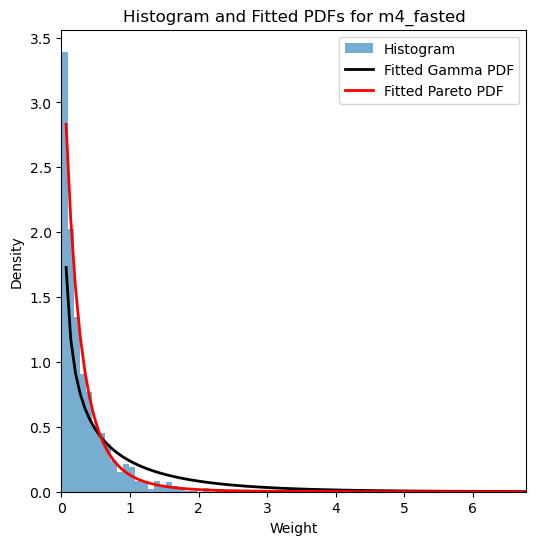

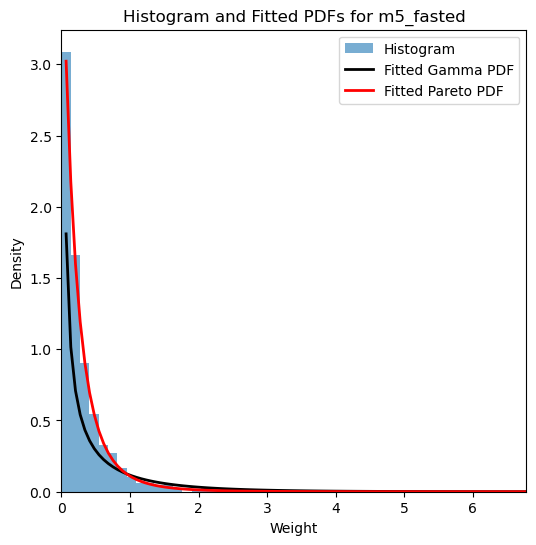

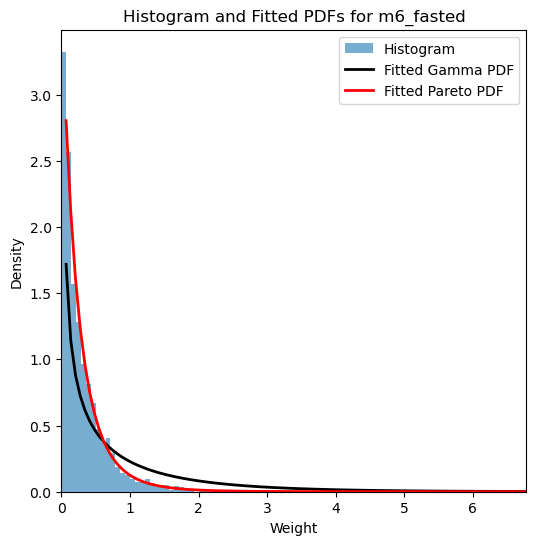

In [39]:
# Calculate global x-limits
all_weights_lasso = np.concatenate([matrix.flatten() for matrix in connectivity_matrices_lasso_fed.values()] + 
                                   [matrix.flatten() for matrix in connectivity_matrices_lasso_fasted.values()])
all_weights_lasso = all_weights_lasso[all_weights_lasso != 0]  # Remove zero weights
global_xmin_lasso, global_xmax_lasso = 0, max(all_weights_lasso)

fitted_params_lasso_fed = {}
for key, matrix in connectivity_matrices_lasso_fed.items():
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization
    
    # Fit a gamma distribution to the data
    params_gamma = gamma.fit(weights)
    fitted_params_lasso_fed[key] = {'gamma': params_gamma}
    
    # Fit a Pareto distribution to the data
    params_pareto = pareto.fit(weights)
    fitted_params_lasso_fed[key]['pareto'] = params_pareto
    
    x = np.linspace(global_xmin_lasso, global_xmax_lasso, 100)
    
    # Plot the histogram and fitted PDFs
    plt.figure(figsize=(6, 6))
    plt.hist(weights, bins=50, density=True, alpha=0.6, label='Histogram')
    
    p_gamma = gamma.pdf(x[1:], *params_gamma)
    plt.plot(x[1:], p_gamma, 'k', linewidth=2, label='Fitted Gamma PDF')
    
    p_pareto = pareto.pdf(x[1:], *params_pareto)
    plt.plot(x[1:], p_pareto, 'r', linewidth=2, label='Fitted Pareto PDF')
    
    plt.title(f'Histogram and Fitted PDFs for {key}')
    plt.xlabel('Weight')
    plt.ylabel('Density')
    plt.xlim(global_xmin_lasso, global_xmax_lasso)
    plt.legend()
    plt.show()

fitted_params_lasso_fasted = {}
for key, matrix in connectivity_matrices_lasso_fasted.items():
    weights = matrix.flatten()
    weights = weights[weights != 0]  # Remove zero weights for better visualization
    
    # Fit a gamma distribution to the data
    params_gamma = gamma.fit(weights)
    fitted_params_lasso_fasted[key] = {'gamma': params_gamma}
    
    # Fit a Pareto distribution to the data
    params_pareto = pareto.fit(weights)
    fitted_params_lasso_fasted[key]['pareto'] = params_pareto
    
    x = np.linspace(global_xmin_lasso, global_xmax_lasso, 100)
    
    # Plot the histogram and fitted PDFs
    plt.figure(figsize=(6, 6))
    plt.hist(weights, bins=50, density=True, alpha=0.6, label='Histogram')
    
    p_gamma = gamma.pdf(x[1:], *params_gamma)
    plt.plot(x[1:], p_gamma, 'k', linewidth=2, label='Fitted Gamma PDF')
    
    p_pareto = pareto.pdf(x[1:], *params_pareto)
    plt.plot(x[1:], p_pareto, 'r', linewidth=2, label='Fitted Pareto PDF')
    
    plt.title(f'Histogram and Fitted PDFs for {key}')
    plt.xlabel('Weight')
    plt.ylabel('Density')
    plt.xlim(global_xmin_lasso, global_xmax_lasso)
    plt.legend()
    plt.show()


### Distribution by condition

#### Gamma distribution

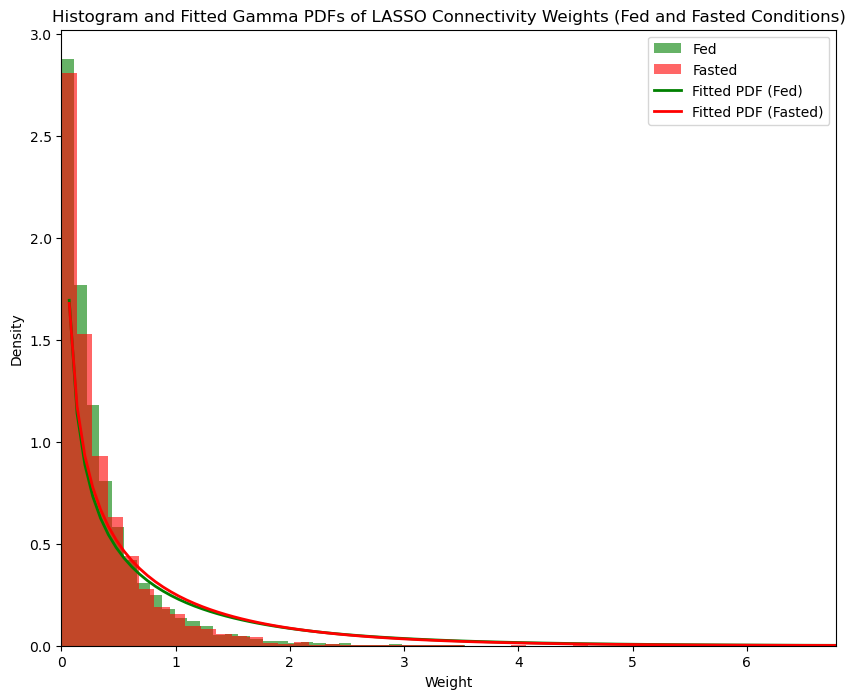

In [40]:
# Aggregate the connectivity weights for fed and fasted conditions
weights_lasso_fed = np.concatenate([matrix.flatten() for matrix in connectivity_matrices_lasso_fed.values()])
weights_lasso_fed = weights_lasso_fed[weights_lasso_fed != 0]  # Remove zero weights

weights_lasso_fasted = np.concatenate([matrix.flatten() for matrix in connectivity_matrices_lasso_fasted.values()])
weights_lasso_fasted = weights_lasso_fasted[weights_lasso_fasted != 0]  # Remove zero weights

# Fit a gamma distribution to the data
params_gamma_fed = gamma.fit(weights_lasso_fed)
params_gamma_fasted = gamma.fit(weights_lasso_fasted)

# Generate the x values for the PDF
xmin, xmax = min(min(weights_lasso_fed), min(weights_lasso_fasted)), max(max(weights_lasso_fed), max(weights_lasso_fasted))
x = np.linspace(xmin, xmax, 100)
p_gamma_fed = gamma.pdf(x[1:], *params_gamma_fed)
p_gamma_fasted = gamma.pdf(x[1:], *params_gamma_fasted)

# Plot histograms for both conditions
plt.figure(figsize=(10, 8))
plt.hist(weights_lasso_fed, bins=50, density=True, alpha=0.6, color='g', label='Fed')
plt.hist(weights_lasso_fasted, bins=50, density=True, alpha=0.6, color='r', label='Fasted')

# Plot the fitted PDFs
plt.plot(x[1:], p_gamma_fed, 'g', linewidth=2, label='Fitted PDF (Fed)')
plt.plot(x[1:], p_gamma_fasted, 'r', linewidth=2, label='Fitted PDF (Fasted)')
plt.title('Histogram and Fitted Gamma PDFs of LASSO Connectivity Weights (Fed and Fasted Conditions)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, global_xmax_lasso)
plt.show()


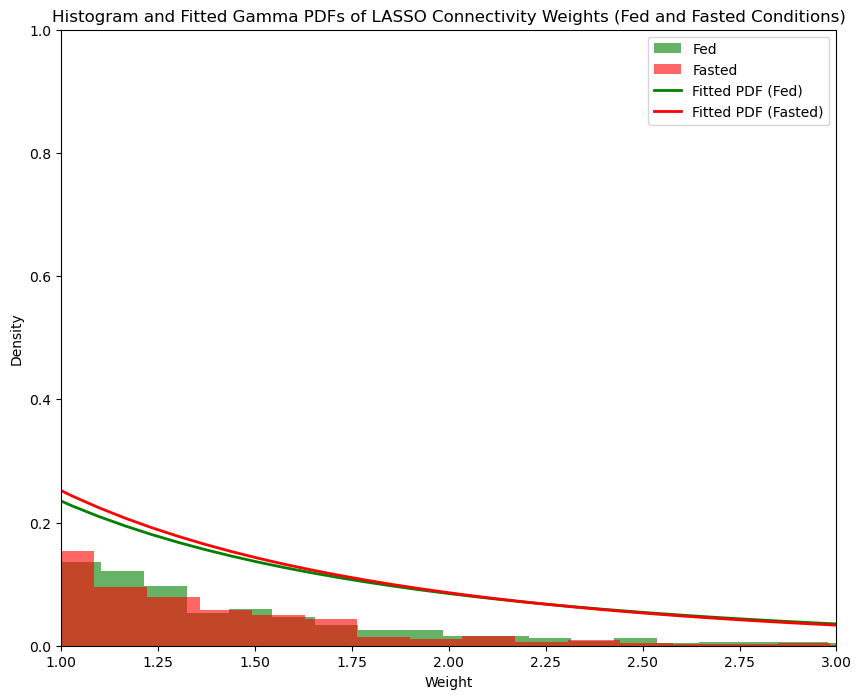

In [41]:
# Plot histograms for both conditions
plt.figure(figsize=(10, 8))
plt.hist(weights_lasso_fed, bins=50, density=True, alpha=0.6, color='g', label='Fed')
plt.hist(weights_lasso_fasted, bins=50, density=True, alpha=0.6, color='r', label='Fasted')

# Plot the fitted PDFs
plt.plot(x[1:], p_gamma_fed, 'g', linewidth=2, label='Fitted PDF (Fed)')
plt.plot(x[1:], p_gamma_fasted, 'r', linewidth=2, label='Fitted PDF (Fasted)')
plt.title('Histogram and Fitted Gamma PDFs of LASSO Connectivity Weights (Fed and Fasted Conditions)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()

# Set the x and y limits to zoom in
plt.xlim(1, 3)
plt.ylim(0, 1)

plt.show()

#### Power law distribution

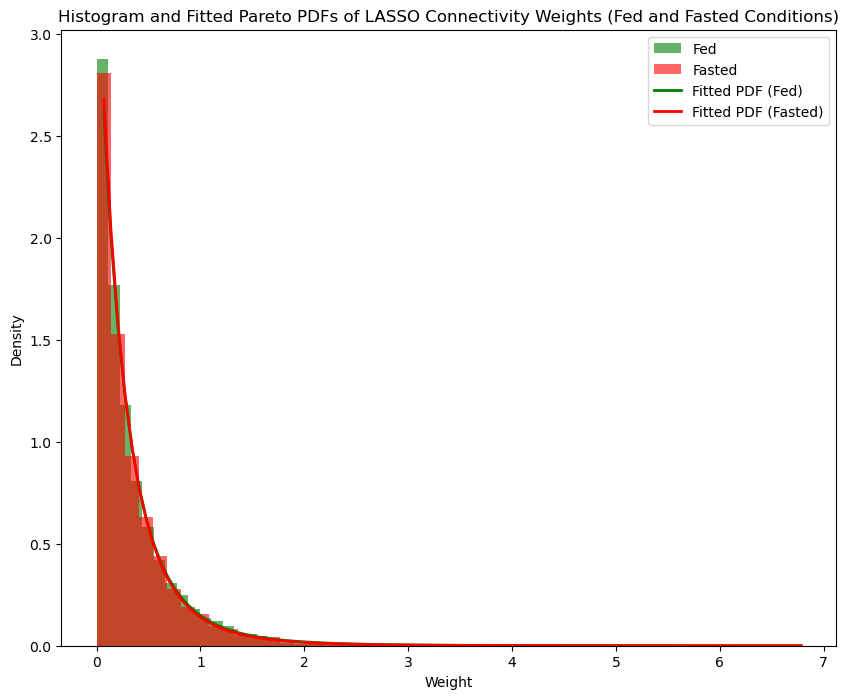

In [42]:
# Fit a Pareto distribution to the data
params_pareto_fed = pareto.fit(weights_lasso_fed)
params_pareto_fasted = pareto.fit(weights_lasso_fasted)

# Generate the x values for the PDF
xmin, xmax = min(min(weights_lasso_fed), min(weights_lasso_fasted)), max(max(weights_lasso_fed), max(weights_lasso_fasted))
x = np.linspace(xmin, xmax, 100)
p_pareto_fed = pareto.pdf(x[1:], *params_pareto_fed)
p_pareto_fasted = pareto.pdf(x[1:], *params_pareto_fasted)

# Plot histograms for both conditions
plt.figure(figsize=(10, 8))
plt.hist(weights_lasso_fed, bins=50, density=True, alpha=0.6, color='g', label='Fed')
plt.hist(weights_lasso_fasted, bins=50, density=True, alpha=0.6, color='r', label='Fasted')

# Plot the fitted PDFs
plt.plot(x[1:], p_pareto_fed, 'g', linewidth=2, label='Fitted PDF (Fed)')
plt.plot(x[1:], p_pareto_fasted, 'r', linewidth=2, label='Fitted PDF (Fasted)')
plt.title('Histogram and Fitted Pareto PDFs of LASSO Connectivity Weights (Fed and Fasted Conditions)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()
plt.show()


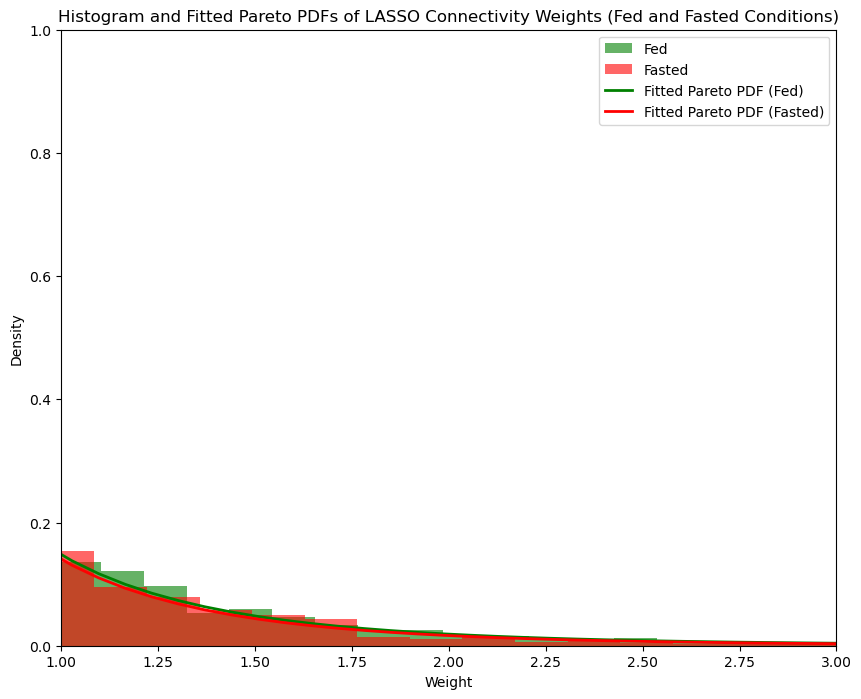

In [43]:
# Plot histograms for both conditions
plt.figure(figsize=(10, 8))
plt.hist(weights_lasso_fed, bins=50, density=True, alpha=0.6, color='g', label='Fed')
plt.hist(weights_lasso_fasted, bins=50, density=True, alpha=0.6, color='r', label='Fasted')

# Plot the fitted Pareto PDFs
plt.plot(x[1:], p_pareto_fed, 'g', linewidth=2, label='Fitted Pareto PDF (Fed)')
plt.plot(x[1:], p_pareto_fasted, 'r', linewidth=2, label='Fitted Pareto PDF (Fasted)')
plt.title('Histogram and Fitted Pareto PDFs of LASSO Connectivity Weights (Fed and Fasted Conditions)')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.legend()

# Set the x and y limits to zoom in
plt.xlim(1, 3)
plt.ylim(0, 1)

plt.show()

### Connectivity

In [44]:
# Show the sizes of the LASSO connectivity matrices for the fed state
for key, matrix in connectivity_matrices_lasso_fed.items():
    print(f'Size of {key}: {matrix.shape}')

# Show the sizes of the LASSO connectivity matrices for the fasted state
for key, matrix in connectivity_matrices_lasso_fasted.items():
    print(f'Size of {key}: {matrix.shape}')

Size of m1_fed: (155, 155)
Size of m2_fed: (69, 69)
Size of m3_fed: (68, 68)
Size of m4_fed: (97, 97)
Size of m5_fed: (84, 84)
Size of m6_fed: (152, 152)
Size of m1_fasted: (144, 144)
Size of m2_fasted: (73, 73)
Size of m3_fasted: (54, 54)
Size of m4_fasted: (84, 84)
Size of m5_fasted: (97, 97)
Size of m6_fasted: (114, 114)


In [45]:
def is_diagonalizable(matrix):
    """
    A matrix is diagonalizable if the sum of the geometric multiplicities 
    of its eigenvalues equals the size of the matrix (full set of linearly independent eigenvectors).
    """
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    rank = np.linalg.matrix_rank(eigenvectors)
    return rank == matrix.shape[0]

# Check diagonalizability for each LASSO connectivity matrix in the fed state
diagonalizable_lasso_fed = {}
for key, matrix in connectivity_matrices_lasso_fed.items():
    diagonalizable_lasso_fed[key] = is_diagonalizable(matrix)
    print(f'{key} is diagonalizable: {diagonalizable_lasso_fed[key]}')

# Check diagonalizability for each LASSO connectivity matrix in the fasted state
diagonalizable_lasso_fasted = {}
for key, matrix in connectivity_matrices_lasso_fasted.items():
    diagonalizable_lasso_fasted[key] = is_diagonalizable(matrix)
    print(f'{key} is diagonalizable: {diagonalizable_lasso_fasted[key]}')

m1_fed is diagonalizable: True
m2_fed is diagonalizable: True
m3_fed is diagonalizable: True
m4_fed is diagonalizable: True
m5_fed is diagonalizable: True
m6_fed is diagonalizable: True
m1_fasted is diagonalizable: True
m2_fasted is diagonalizable: True
m3_fasted is diagonalizable: True
m4_fasted is diagonalizable: True
m5_fasted is diagonalizable: True
m6_fasted is diagonalizable: True


In [46]:
# Compute the rank for each connectivity matrix in the fed state and check if it's full rank
ranks_fed = {}
full_rank_fed = {}
for key, matrix in connectivity_matrices_fed.items():
    rank = np.linalg.matrix_rank(matrix)
    ranks_fed[key] = rank
    full_rank_fed[key] = rank == matrix.shape[1]
    print(f'Rank of {key} (Fed): {rank}, Full Rank: {full_rank_fed[key]}')

# Compute the rank for each connectivity matrix in the fasted state and check if it's full rank
ranks_fasted = {}
full_rank_fasted = {}
for key, matrix in connectivity_matrices_fasted.items():
    rank = np.linalg.matrix_rank(matrix)
    ranks_fasted[key] = rank
    full_rank_fasted[key] = rank == matrix.shape[1]
    print(f'Rank of {key} (Fasted): {rank}, Full Rank: {full_rank_fasted[key]}')

Rank of m1_fed (Fed): 155, Full Rank: True
Rank of m2_fed (Fed): 69, Full Rank: True
Rank of m3_fed (Fed): 68, Full Rank: True
Rank of m4_fed (Fed): 97, Full Rank: True
Rank of m5_fed (Fed): 84, Full Rank: True
Rank of m6_fed (Fed): 152, Full Rank: True
Rank of m1_fasted (Fasted): 144, Full Rank: True
Rank of m2_fasted (Fasted): 73, Full Rank: True
Rank of m3_fasted (Fasted): 54, Full Rank: True
Rank of m4_fasted (Fasted): 84, Full Rank: True
Rank of m5_fasted (Fasted): 97, Full Rank: True
Rank of m6_fasted (Fasted): 114, Full Rank: True


In [47]:
def is_normal_matrix(matrix):
    """
    Check if a matrix is a normal matrix.
    A matrix A is normal if A * A^H = A^H * A, where A^H is the conjugate transpose of A.
    """
    return np.allclose(matrix @ matrix.T.conj(), matrix.T.conj() @ matrix)

# Check normality for each LASSO connectivity matrix in the fed state
normal_matrices_lasso_fed = {}
for key, matrix in connectivity_matrices_lasso_fed.items():
    normal_matrices_lasso_fed[key] = is_normal_matrix(matrix)
    print(f'{key} is a normal matrix: {normal_matrices_lasso_fed[key]}')

# Check normality for each LASSO connectivity matrix in the fasted state
normal_matrices_lasso_fasted = {}
for key, matrix in connectivity_matrices_lasso_fasted.items():
    normal_matrices_lasso_fasted[key] = is_normal_matrix(matrix)
    print(f'{key} is a normal matrix: {normal_matrices_lasso_fasted[key]}')

m1_fed is a normal matrix: False
m2_fed is a normal matrix: False
m3_fed is a normal matrix: False
m4_fed is a normal matrix: False
m5_fed is a normal matrix: False
m6_fed is a normal matrix: False
m1_fasted is a normal matrix: False
m2_fasted is a normal matrix: False
m3_fasted is a normal matrix: False
m4_fasted is a normal matrix: False
m5_fasted is a normal matrix: False
m6_fasted is a normal matrix: False


#### Eigendecomposition

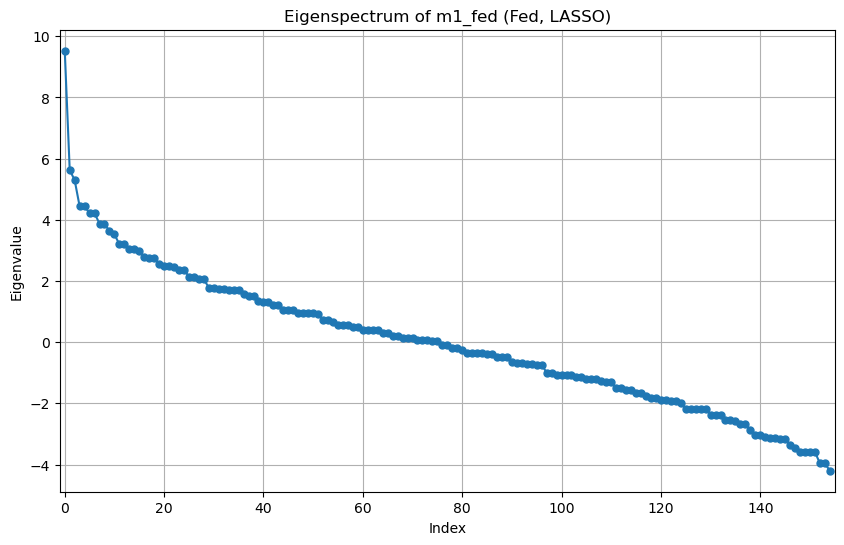

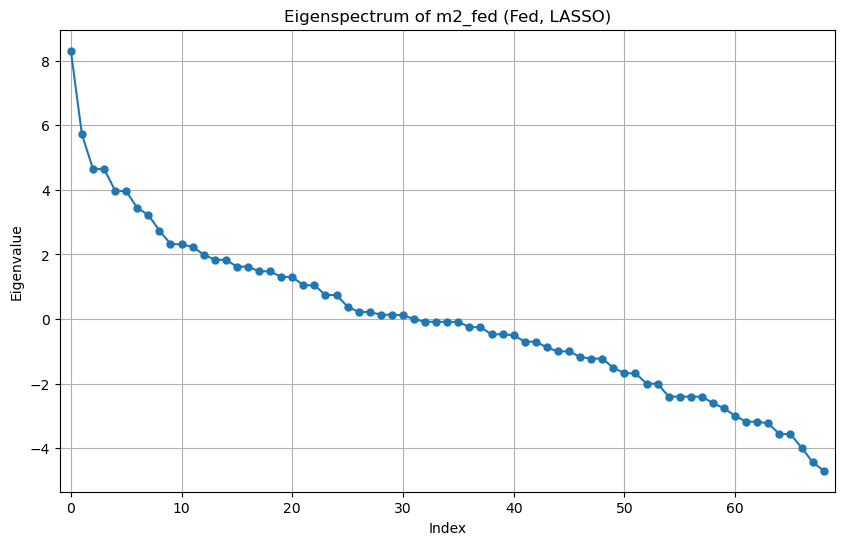

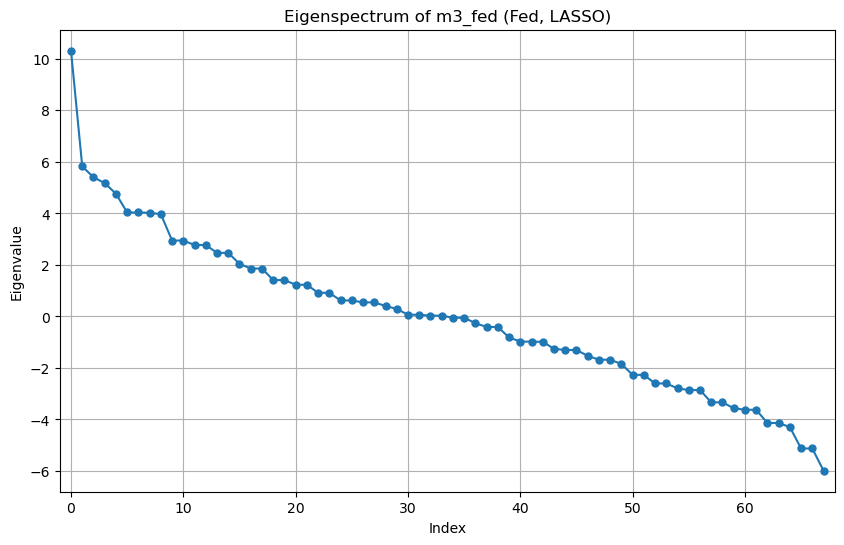

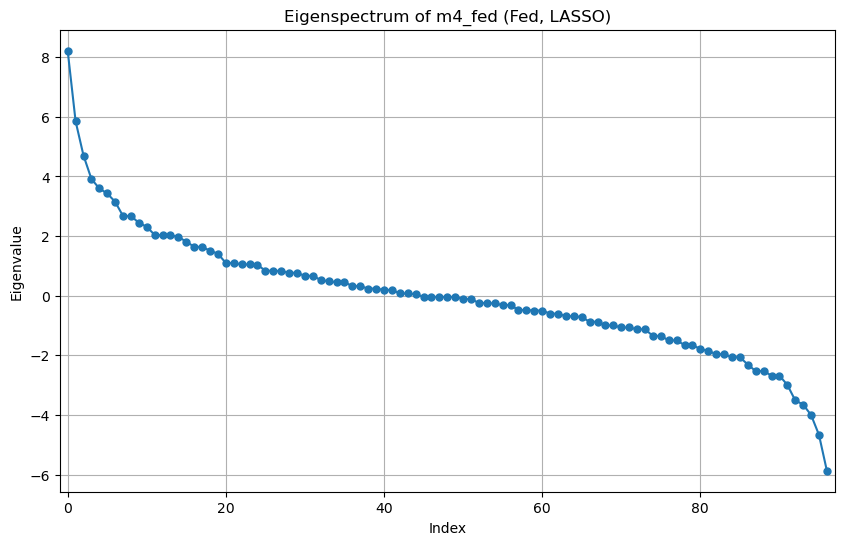

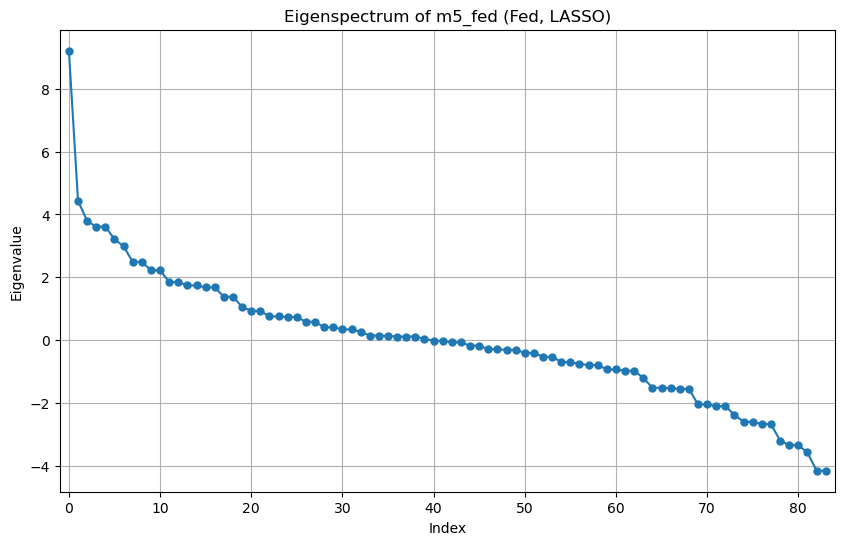

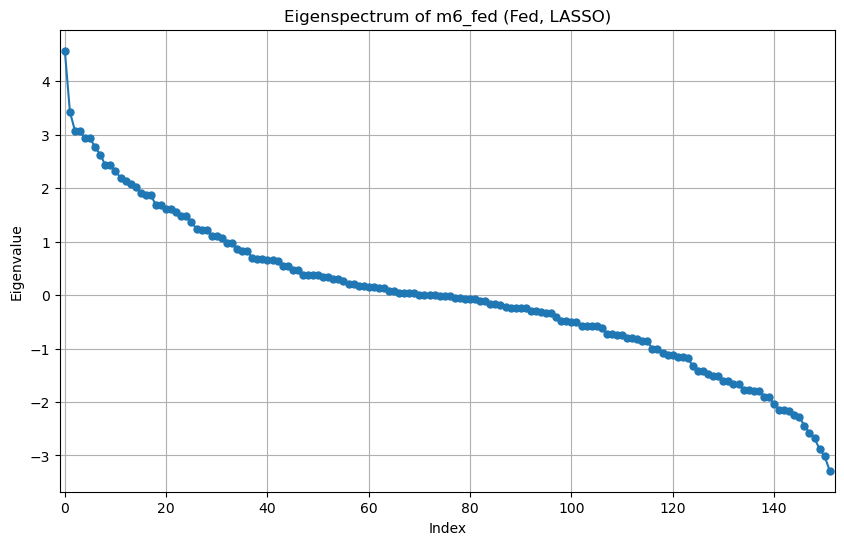

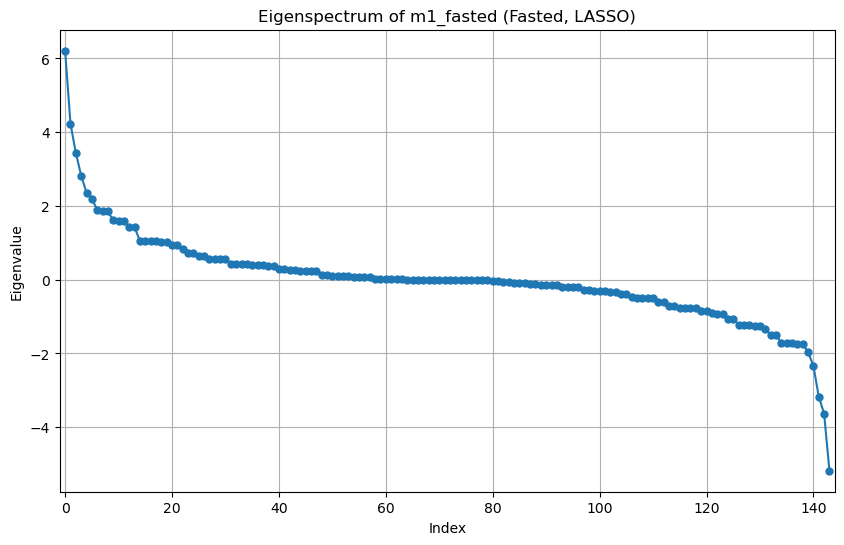

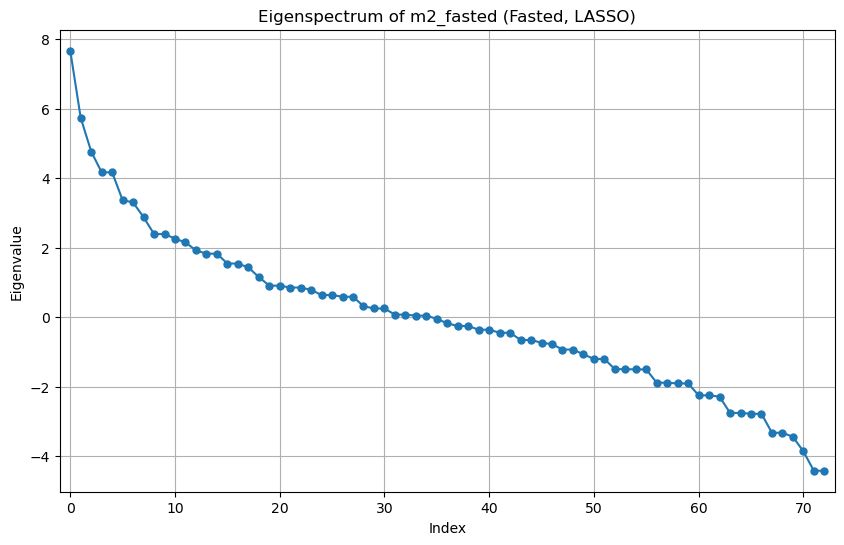

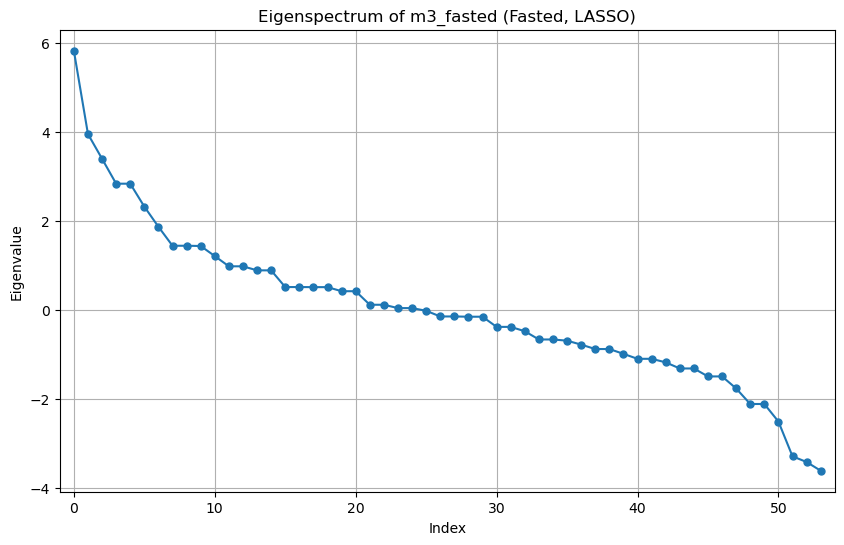

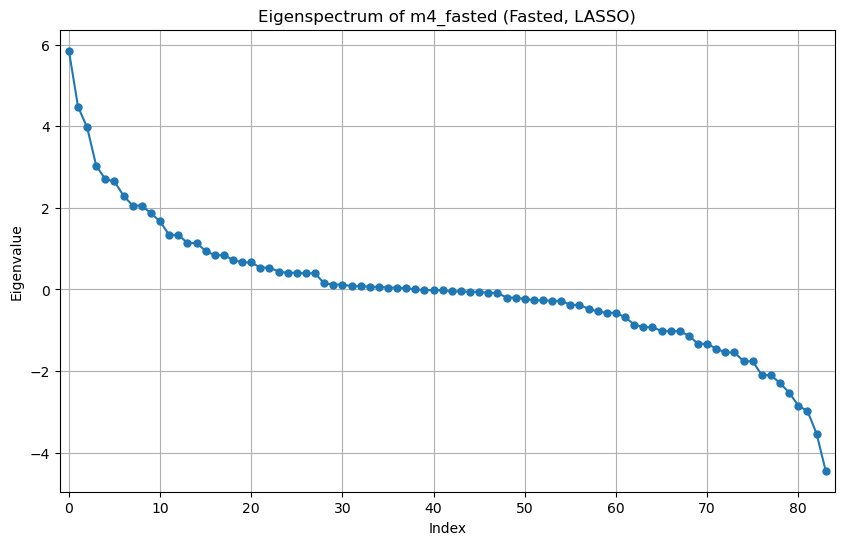

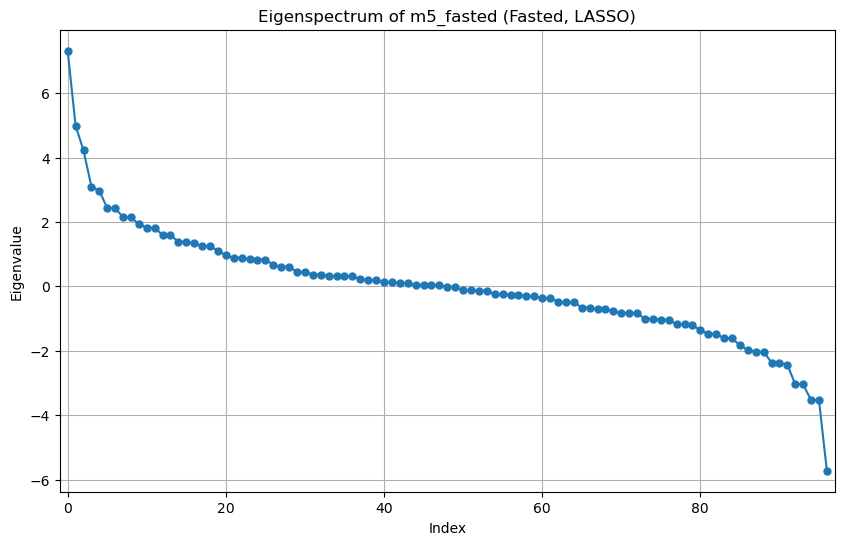

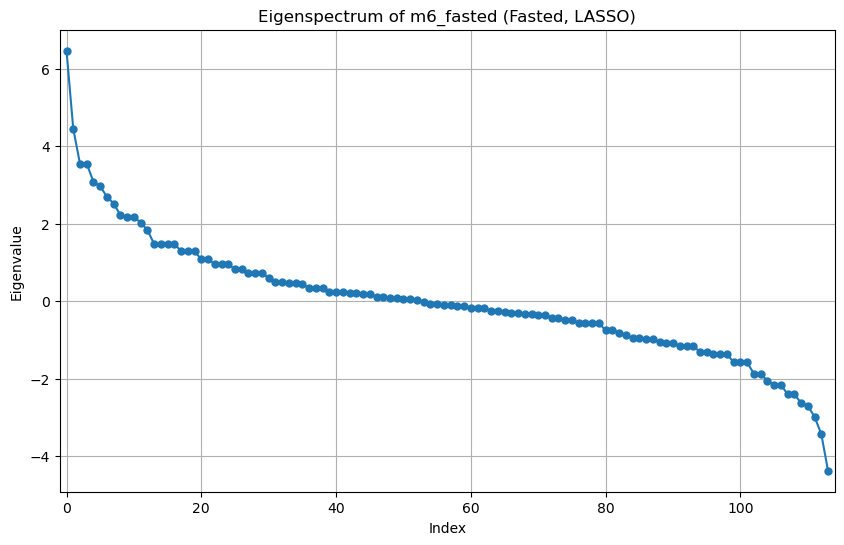

In [48]:
def plot_eigenspectrum(matrix, title):
    # Perform eigendocomposition
    eigenvalues, _ = np.linalg.eig(matrix)
    
    # Sort eigenvalues in descending order
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    # Plot the eigenspectrum
    plt.figure(figsize=(10, 6))
    plt.plot(eigenvalues, 'o-', markersize=5)
    plt.title(f'Eigenspectrum of {title}')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.xlim(-1, len(eigenvalues))  # Set x-axis limits
    plt.grid(True)
    plt.show()

# Plot eigenspectrum for each LASSO connectivity matrix in the fed state
for key, matrix in connectivity_matrices_lasso_fed.items():
    plot_eigenspectrum(matrix, f'{key} (Fed, LASSO)')

# Plot eigenspectrum for each LASSO connectivity matrix in the fasted state
for key, matrix in connectivity_matrices_lasso_fasted.items():
    plot_eigenspectrum(matrix, f'{key} (Fasted, LASSO)')

/home/charlesxu/anaconda3/envs/neuraldynamics/lib/python3.9/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/charlesxu/anaconda3/envs/neuraldynamics/lib/python3.9/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/charlesxu/anaconda3/envs/neuraldynamics/lib/python3.9/site-packages/matplotlib/transforms.py:2855: ComplexWarning: Casting complex values to real discards the imaginary part
  vmin, vmax = map(float, [vmin, vmax])


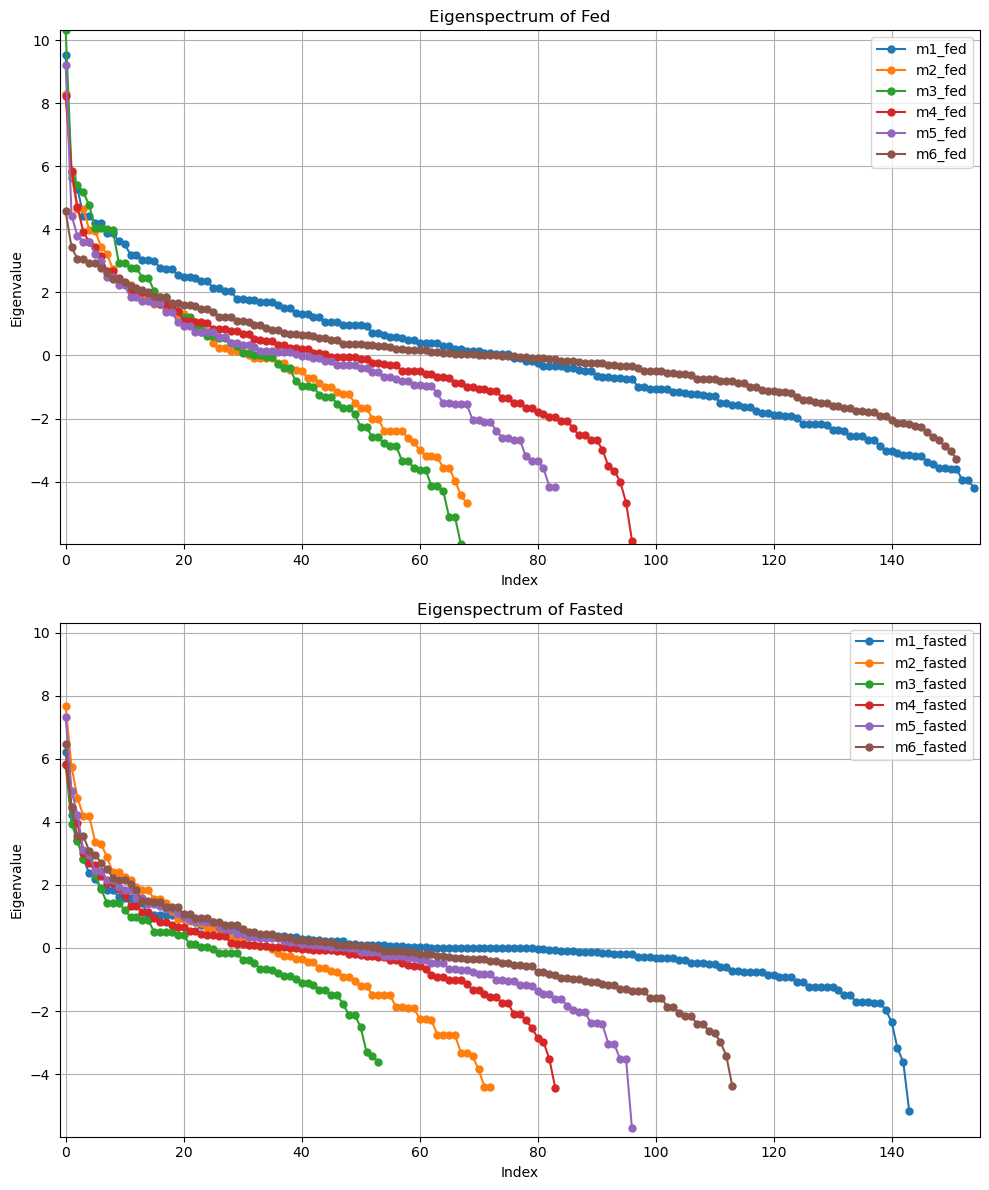

In [58]:
def plot_eigenspectrum(matrix, title, ax, label):
    # Perform eigendocomposition
    eigenvalues, _ = np.linalg.eig(matrix)
    
    # Sort eigenvalues in descending order
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    # Plot the eigenspectrum
    ax.plot(eigenvalues, 'o-', markersize=5, label=label)
    ax.set_title(f'Eigenspectrum of {title}')
    ax.set_xlabel('Index')
    ax.set_ylabel('Eigenvalue')
    ax.grid(True)
    return eigenvalues

# Initialize the figure and axes
fig, axs = plt.subplots(2, 1, figsize=(10, 12))

# Collect all eigenvalues to determine global min and max
all_eigenvalues = []
max_length = 0

# Plot eigenspectrum for each LASSO connectivity matrix in the fed state
for key, matrix in connectivity_matrices_lasso_fed.items():
    eigenvalues = plot_eigenspectrum(matrix, f'Fed', axs[0], key)
    all_eigenvalues.extend(eigenvalues)
    max_length = max(max_length, len(eigenvalues))

# Plot eigenspectrum for each LASSO connectivity matrix in the fasted state
for key, matrix in connectivity_matrices_lasso_fasted.items():
    eigenvalues = plot_eigenspectrum(matrix, f'Fasted', axs[1], key)
    all_eigenvalues.extend(eigenvalues)
    max_length = max(max_length, len(eigenvalues))

# Determine global min and max for eigenvalues
global_ymin, global_ymax = min(all_eigenvalues), max(all_eigenvalues)

# Set the same x and y limits for both subplots
for ax in axs:
    ax.set_xlim(-1, max_length)
    ax.set_ylim(global_ymin, global_ymax)

# Add legends
axs[0].legend()
axs[1].legend()

plt.tight_layout()
plt.show()

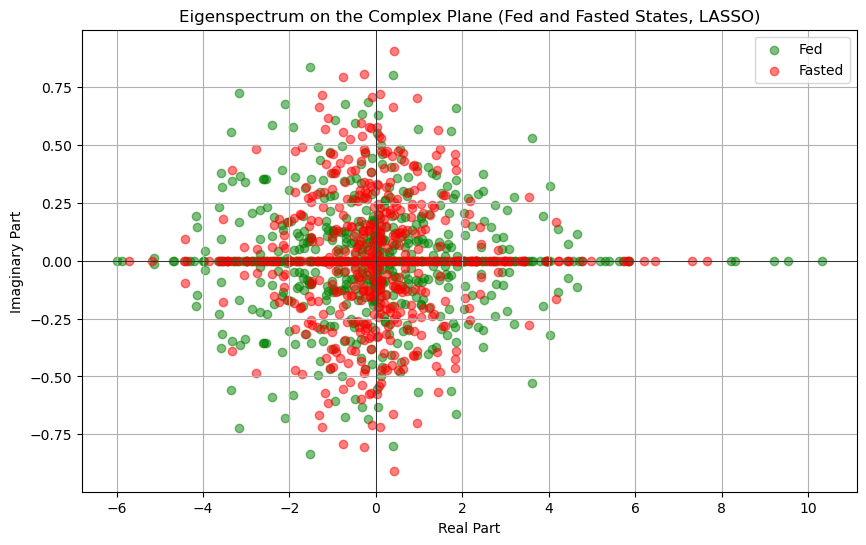

In [49]:
# Initialize a figure for the plot
plt.figure(figsize=(10, 6))

# Scatter all the eigenvalues for fed in green
for key, matrix in connectivity_matrices_lasso_fed.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    plt.scatter(eigenvalues.real, eigenvalues.imag, color='g', alpha=0.5, label='Fed' if key == 'm1_fed' else "")

# Scatter all the eigenvalues for fasted in red
for key, matrix in connectivity_matrices_lasso_fasted.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    plt.scatter(eigenvalues.real, eigenvalues.imag, color='r', alpha=0.5, label='Fasted' if key == 'm1_fasted' else "")

# Add title and labels
plt.title('Eigenspectrum on the Complex Plane (Fed and Fasted States, LASSO)')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.show()

##### Time constants

In [50]:
def calculate_time_constants(eigenvalues):
    """
    Calculate the time constants for each eigenmode.
    
    Parameters:
    eigenvalues (numpy.ndarray): Array of eigenvalues.
    
    Returns:
    numpy.ndarray: Array of time constants.
    """
    real_parts = np.real(eigenvalues)
    time_constants = np.abs(1 / np.log(np.abs(real_parts)))
    return time_constants

# Calculate time constants for each LASSO connectivity matrix in the fed state
time_constants_lasso_fed = {}
for key, matrix in connectivity_matrices_lasso_fed.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
    time_constants_lasso_fed[key] = calculate_time_constants(eigenvalues)

# Calculate time constants for each LASSO connectivity matrix in the fasted state
time_constants_lasso_fasted = {}
for key, matrix in connectivity_matrices_lasso_fasted.items():
    eigenvalues, _ = np.linalg.eig(matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
    time_constants_lasso_fasted[key] = calculate_time_constants(eigenvalues)

/tmp/ipykernel_1571941/4123831720.py:12: RuntimeWarning: divide by zero encountered in log
  time_constants = np.abs(1 / np.log(np.abs(real_parts)))


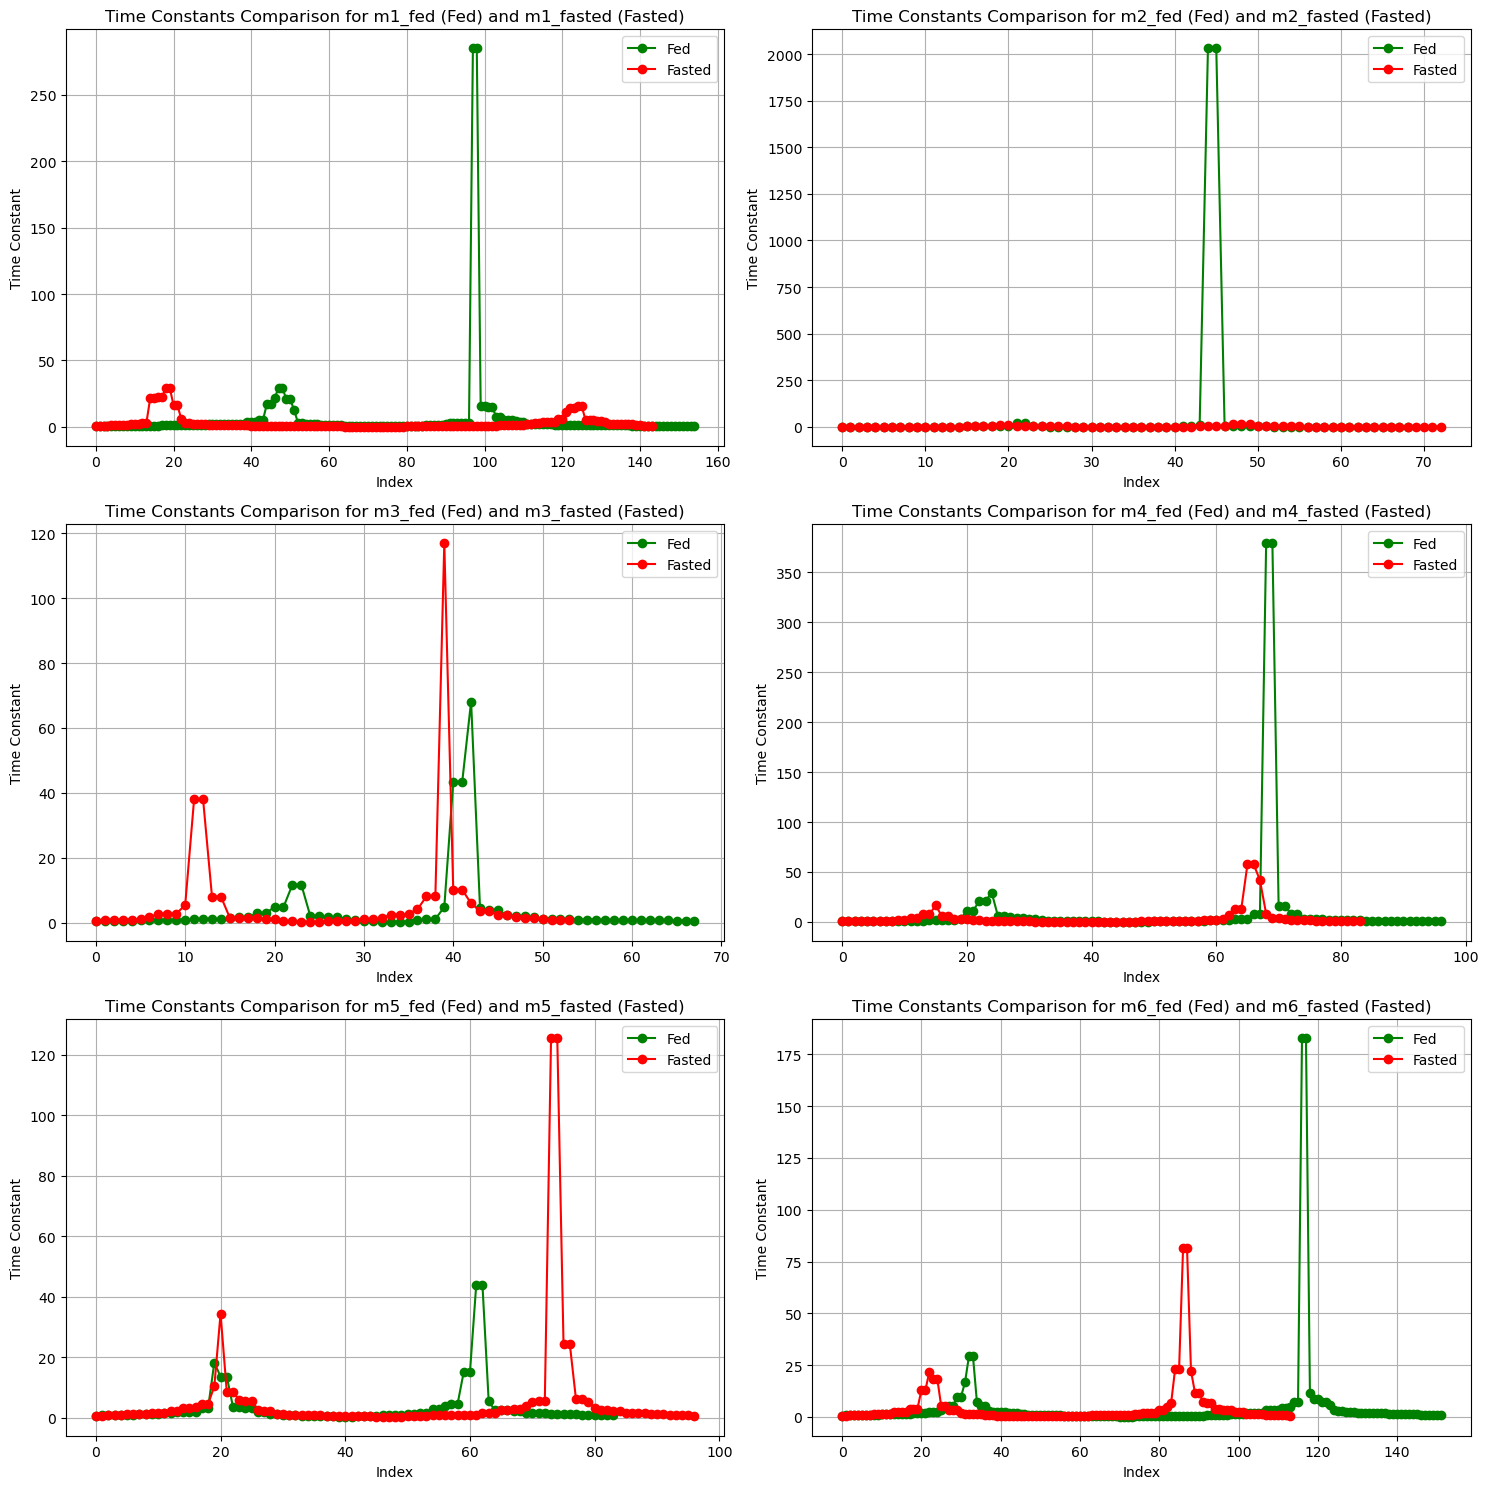

In [51]:
# List of animal keys for fed and fasted states
animal_keys_fed = list(time_constants_lasso_fed.keys())
animal_keys_fasted = list(time_constants_lasso_fasted.keys())

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each animal and plot the time constants
for i, (key_fed, key_fasted) in enumerate(zip(animal_keys_fed, animal_keys_fasted)):
    # Get the time constants for the current animal in fed and fasted states
    time_constants_fed_animal = time_constants_lasso_fed[key_fed]
    time_constants_fasted_animal = time_constants_lasso_fasted[key_fasted]
    
    # Plot the time constants for fed state
    axs[i].plot(time_constants_fed_animal, 'o-', color='g', label='Fed')
    
    # Plot the time constants for fasted state
    axs[i].plot(time_constants_fasted_animal, 'o-', color='r', label='Fasted')
    
    # Add title and labels
    axs[i].set_title(f'Time Constants Comparison for {key_fed} (Fed) and {key_fasted} (Fasted)')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Time Constant')
    axs[i].legend()
    axs[i].grid(True)
    
# Adjust layout
plt.tight_layout()
plt.show()

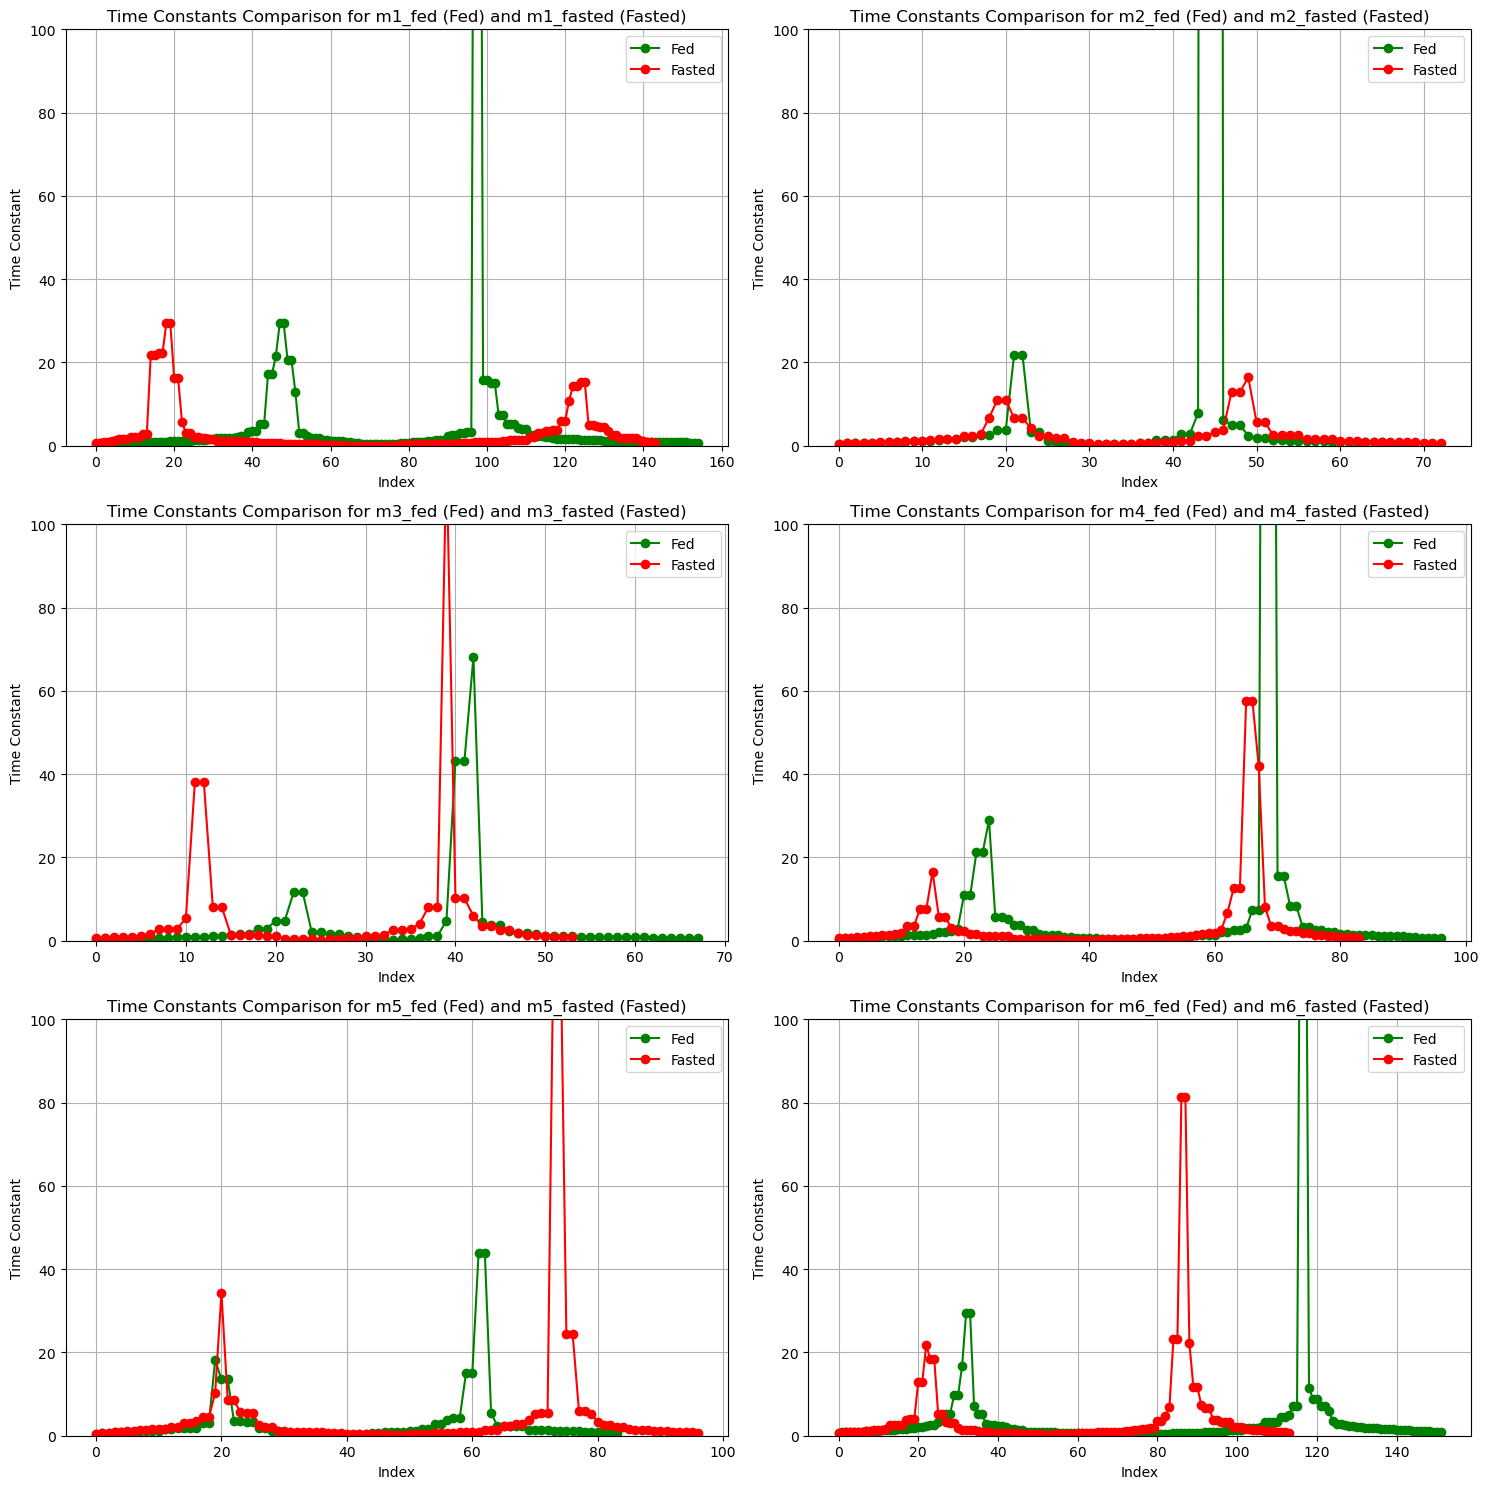

In [52]:
# List of animal keys for fed and fasted states
animal_keys_fed = list(time_constants_lasso_fed.keys())
animal_keys_fasted = list(time_constants_lasso_fasted.keys())

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each animal and plot the time constants
for i, (key_fed, key_fasted) in enumerate(zip(animal_keys_fed, animal_keys_fasted)):
    # Get the time constants for the current animal in fed and fasted states
    time_constants_fed_animal = time_constants_lasso_fed[key_fed]
    time_constants_fasted_animal = time_constants_lasso_fasted[key_fasted]
    
    # Plot the time constants for fed state
    axs[i].plot(time_constants_fed_animal, 'o-', color='g', label='Fed')
    
    # Plot the time constants for fasted state
    axs[i].plot(time_constants_fasted_animal, 'o-', color='r', label='Fasted')
    
    # Add title and labels
    axs[i].set_title(f'Time Constants Comparison for {key_fed} (Fed) and {key_fasted} (Fasted)')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Time Constant')
    axs[i].legend()
    axs[i].grid(True)
    
    # Set y-axis limits
    axs[i].set_ylim(0, 100)

# Adjust layout
plt.tight_layout()
plt.show()

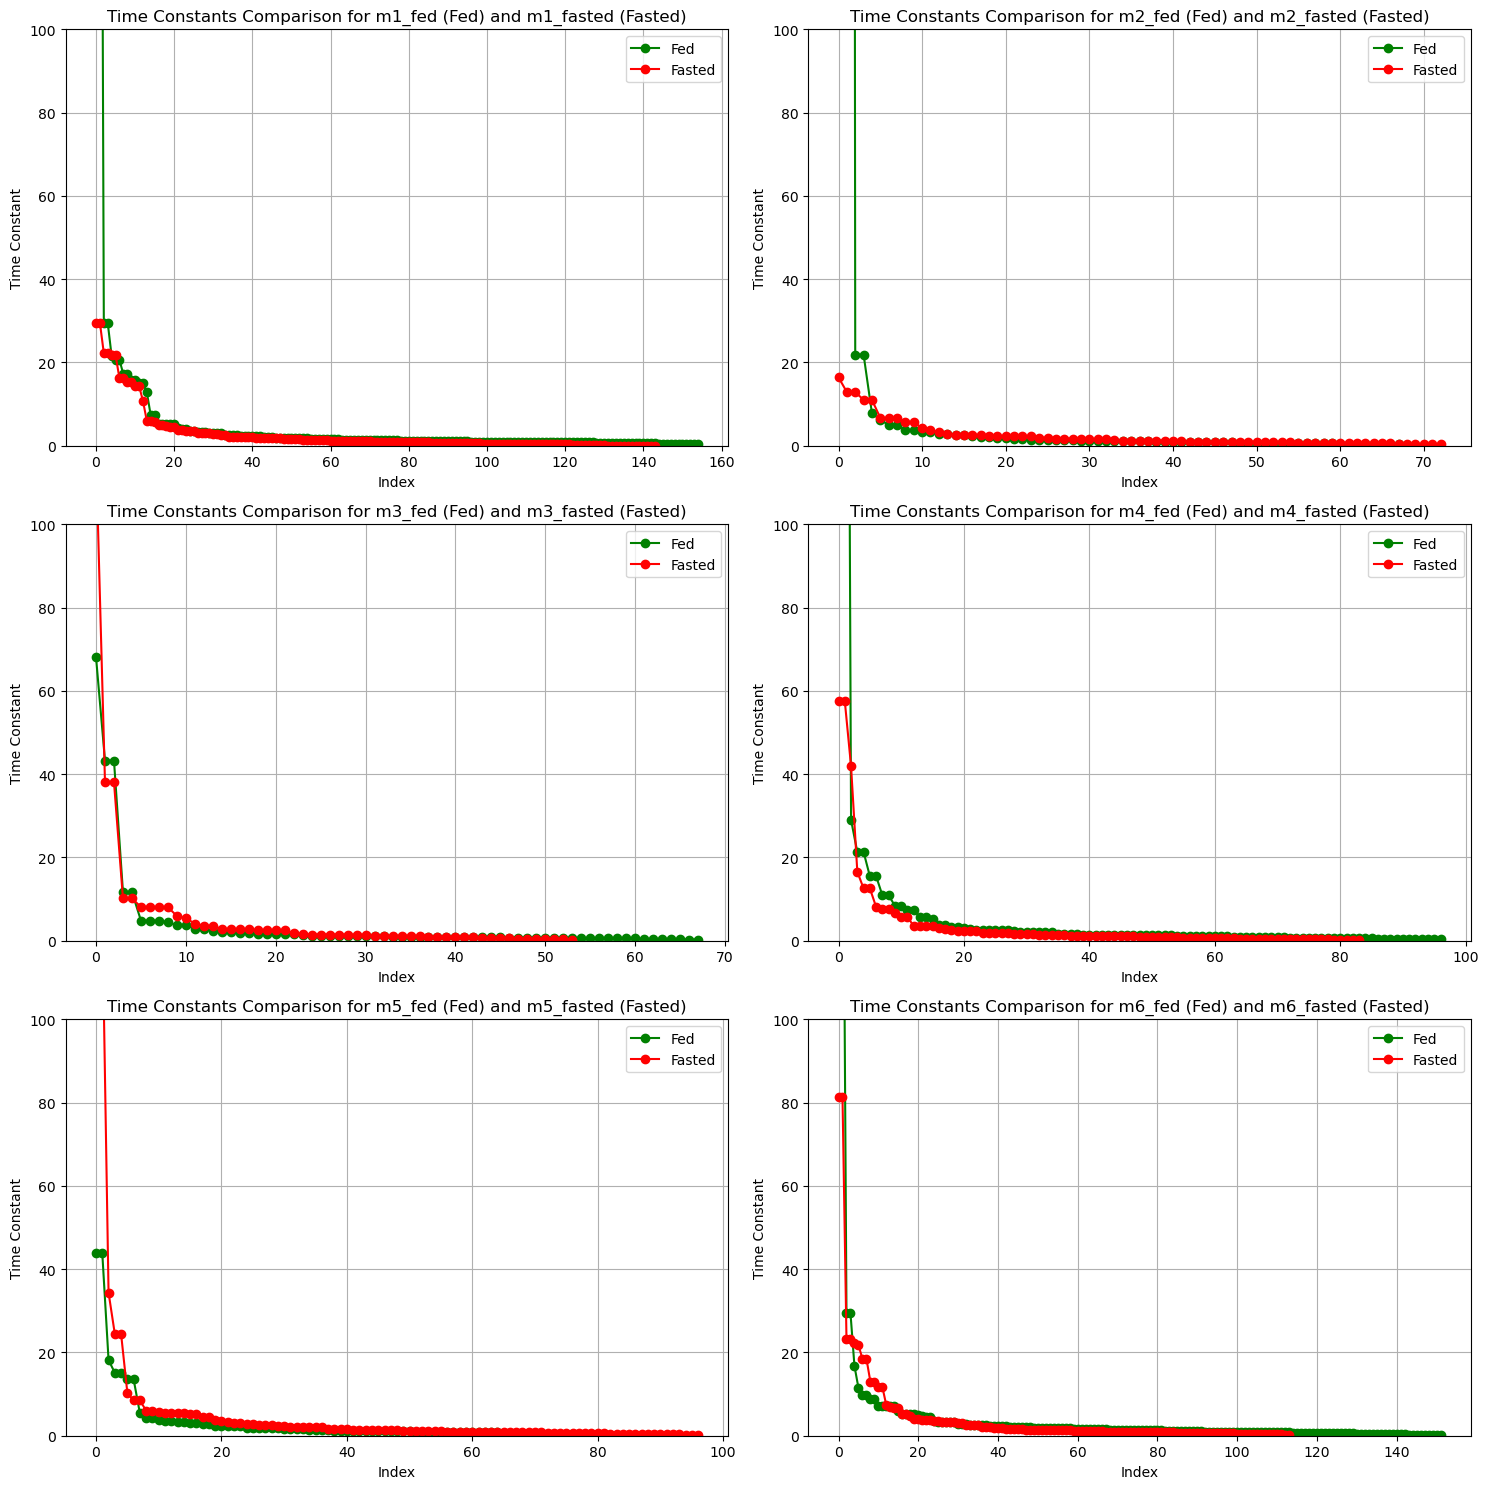

In [53]:
# List of animal keys for fed and fasted states
animal_keys_fed = list(time_constants_lasso_fed.keys())
animal_keys_fasted = list(time_constants_lasso_fasted.keys())

# Create a 3 by 2 subplot
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each animal and plot the time constants
for i, (key_fed, key_fasted) in enumerate(zip(animal_keys_fed, animal_keys_fasted)):
    # Get the time constants for the current animal in fed and fasted states
    time_constants_fed_animal = np.sort(time_constants_lasso_fed[key_fed])[::-1]
    time_constants_fasted_animal = np.sort(time_constants_lasso_fasted[key_fasted])[::-1]
    
    # Plot the time constants for fed state
    axs[i].plot(time_constants_fed_animal, 'o-', color='g', label='Fed')
    
    # Plot the time constants for fasted state
    axs[i].plot(time_constants_fasted_animal, 'o-', color='r', label='Fasted')
    
    # Add title and labels
    axs[i].set_title(f'Time Constants Comparison for {key_fed} (Fed) and {key_fasted} (Fasted)')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Time Constant')
    axs[i].legend()
    axs[i].grid(True)
    
    # Set y-axis limits
    axs[i].set_ylim(0, 100)

# Adjust layout
plt.tight_layout()
plt.show()

### RNN simulation

In [54]:
from vmhvlsnn import SNN

np.random.seed(42)  # For reproducibility
T = 100e3

# Define input pattern
pattern = np.zeros(int(T), dtype=bool)
for i in range(4):
    start = int((i * 10 + 9) * 1e3)
    end = int((i * 10 + 10) * 1e3)
    pattern[start:end] = True

Results for m1_fed:


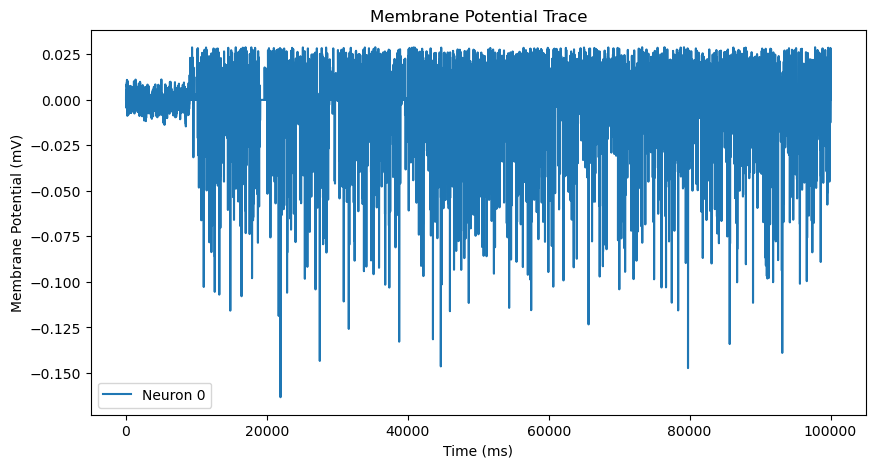

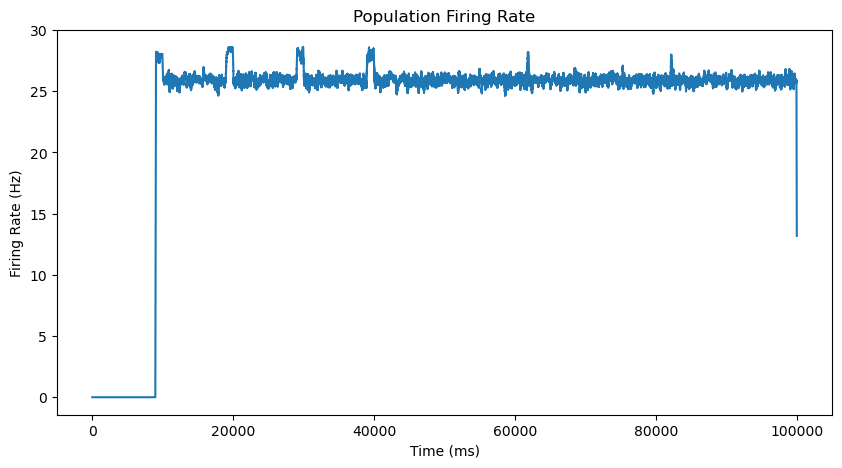

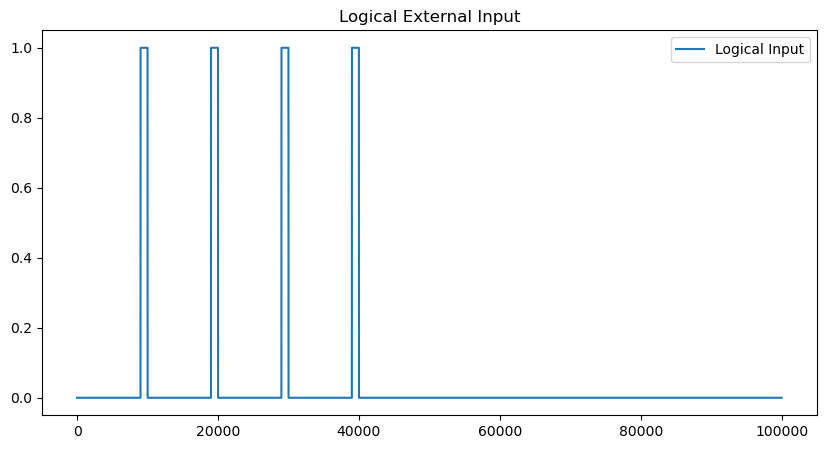

Results for m2_fed:


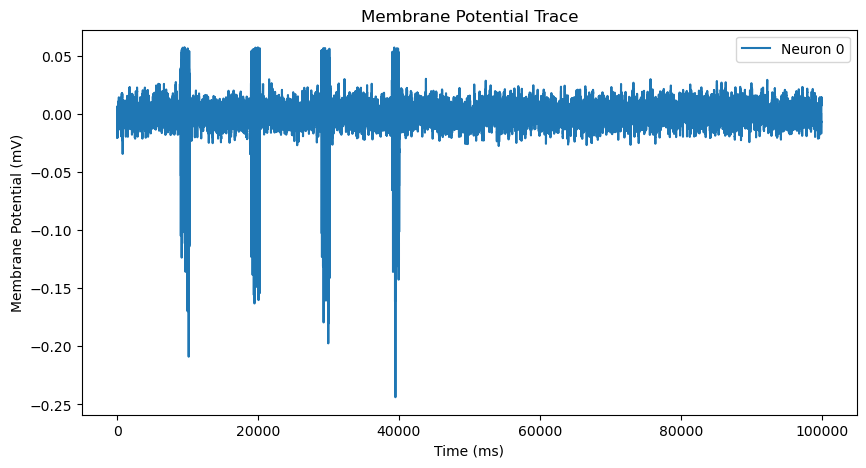

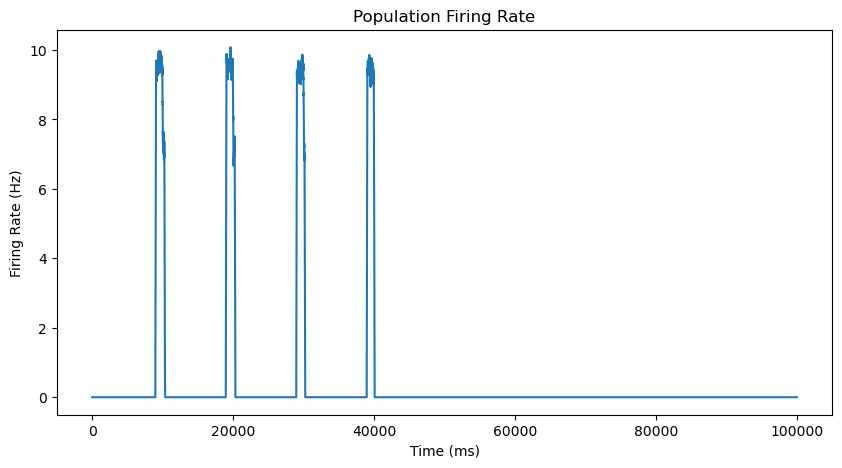

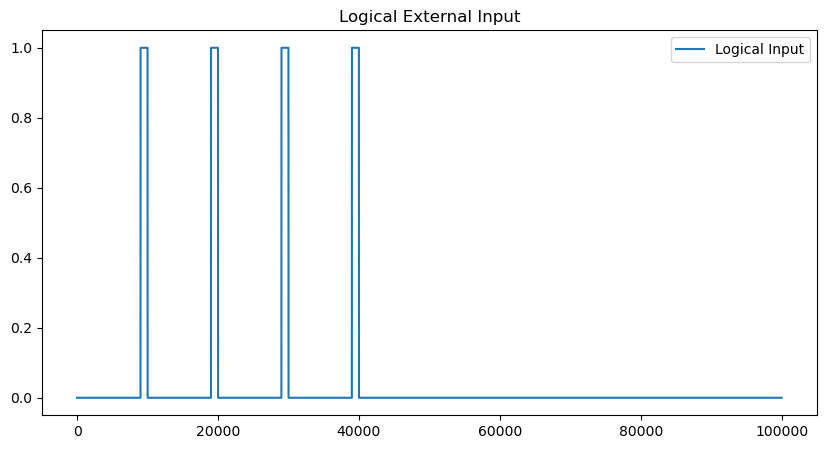

Results for m3_fed:


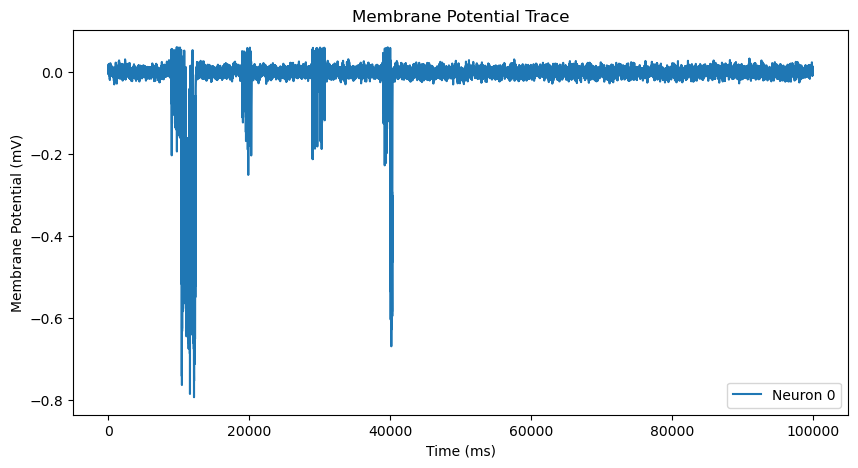

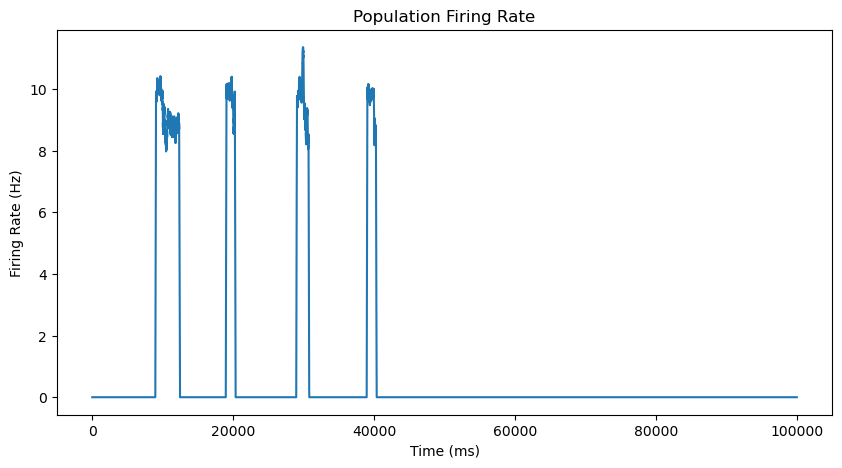

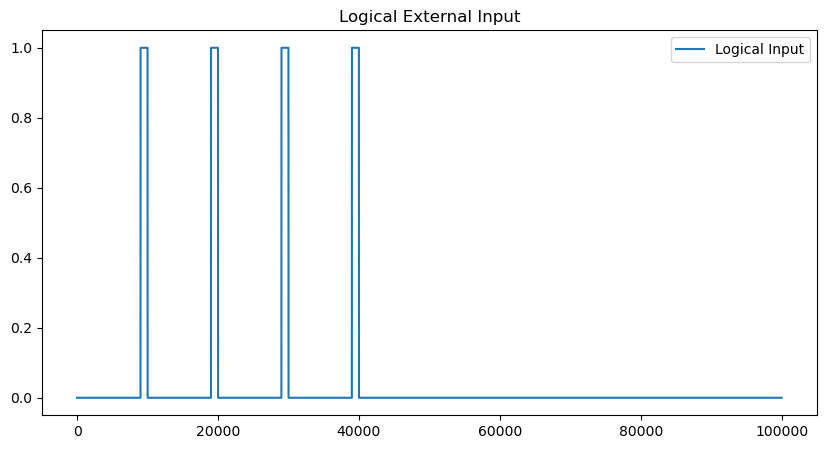

Results for m4_fed:


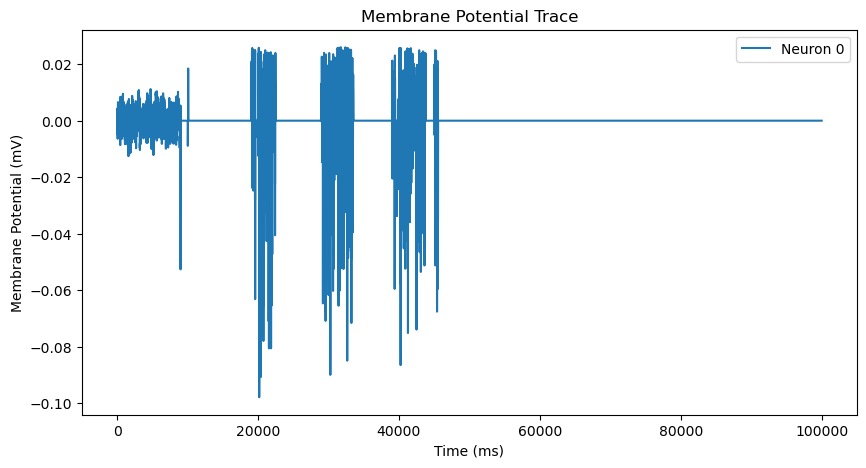

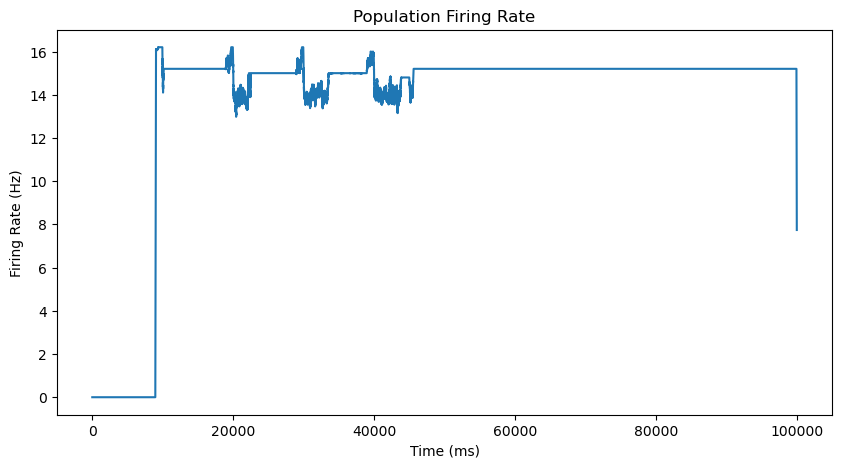

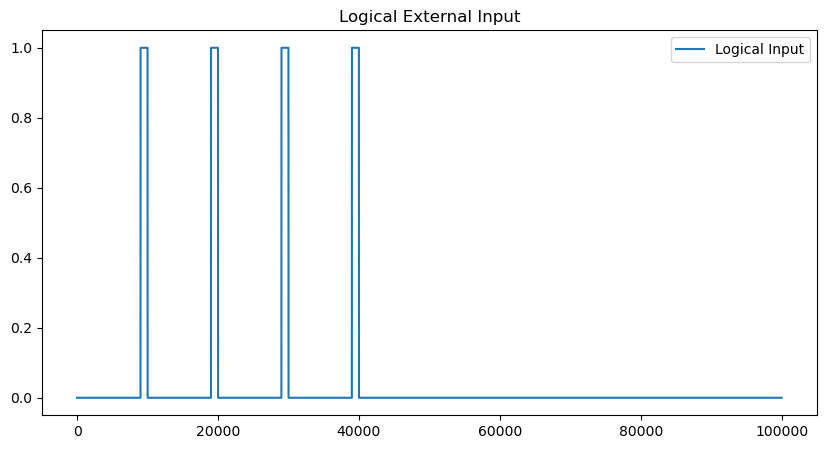

Results for m5_fed:


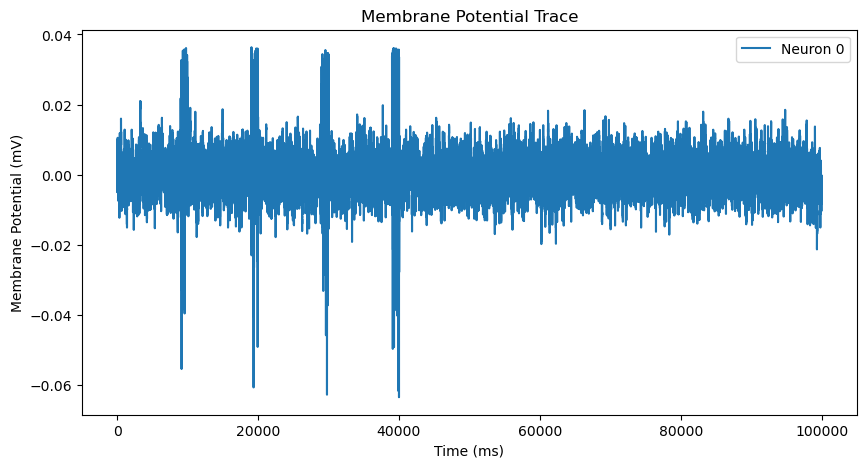

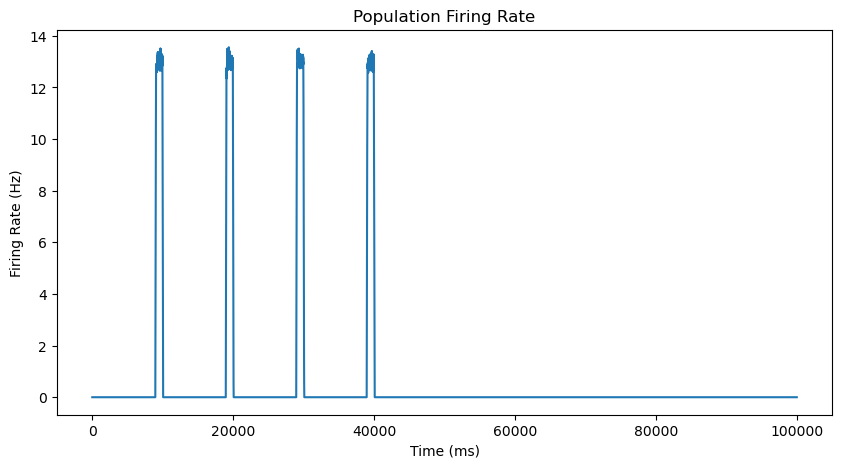

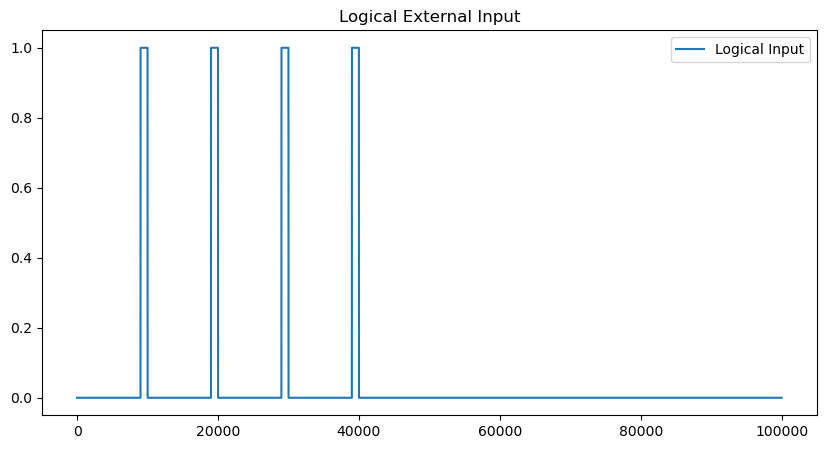

Results for m6_fed:


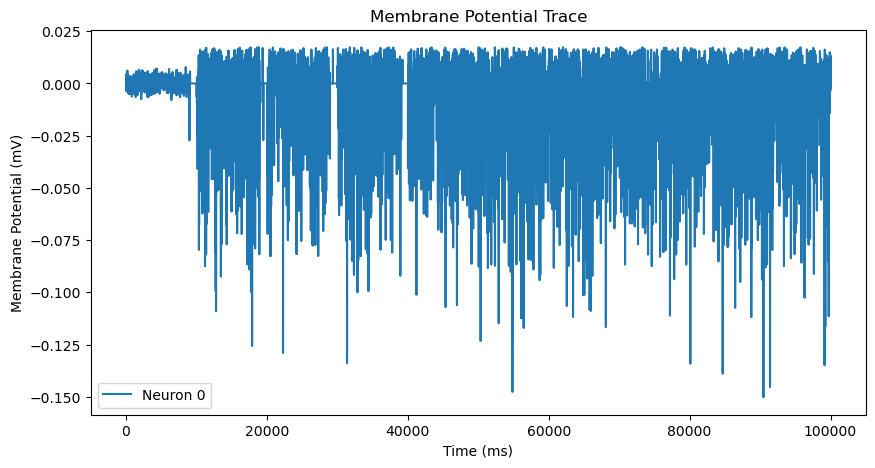

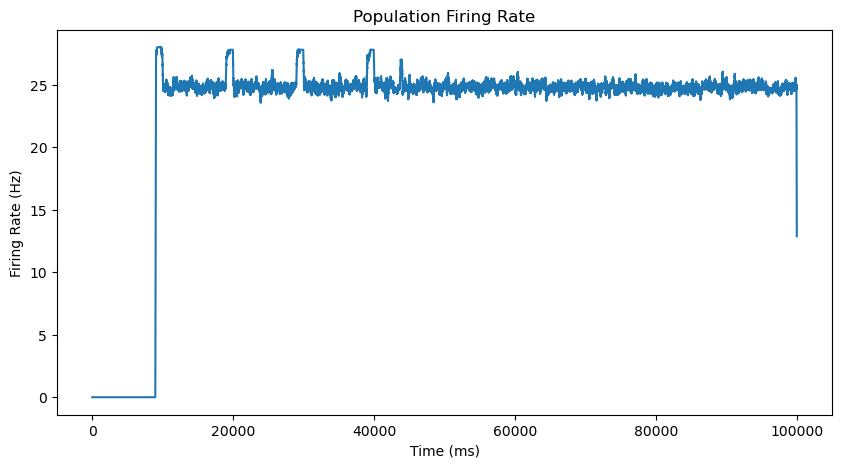

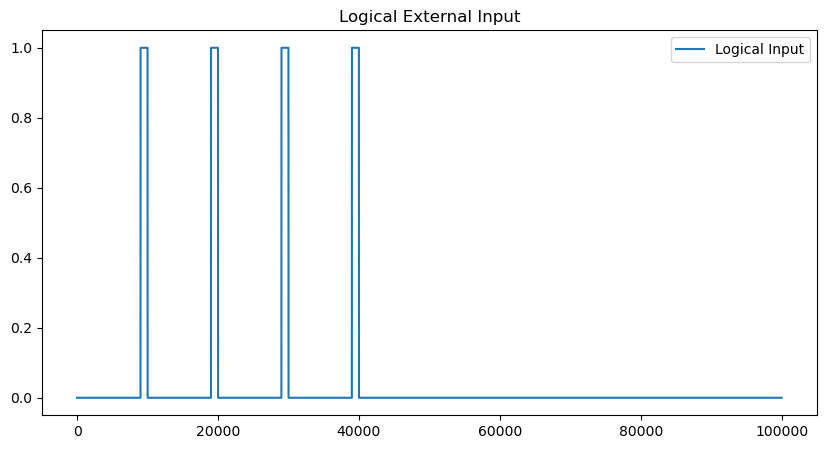

In [55]:
for key, W in connectivity_matrices_fed.items():
    num_neurons = W.shape[0]
    num_targets = int(0.2 * num_neurons)
    targets = np.random.choice(num_neurons, num_targets, replace=False)

    # Define input
    input = {
        'type': 'logical',
        'pattern': pattern,
        'strength': 1,
        'targets': targets
    }

    V_th = np.mean(W)

    # Create an instance of the simulation class
    snn = SNN(W=W, tau_m=20.0, V_rest=0.0, V_th=V_th*1.2, V_reset=0.0, refractory_period=5.0, noise=V_th)
    snn.run(T=T, external_input=input)

    # Plot results for the current matrix
    print(f"Results for {key}:")
    # snn.plot_raster()
    snn.plot_trace([0])
    snn.plot_rate(window=100)
    snn.plot_input()

Results for m1_fasted:


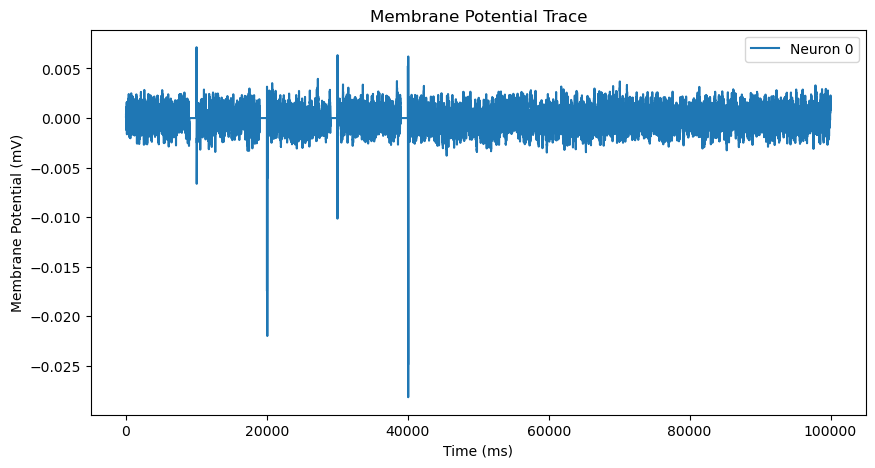

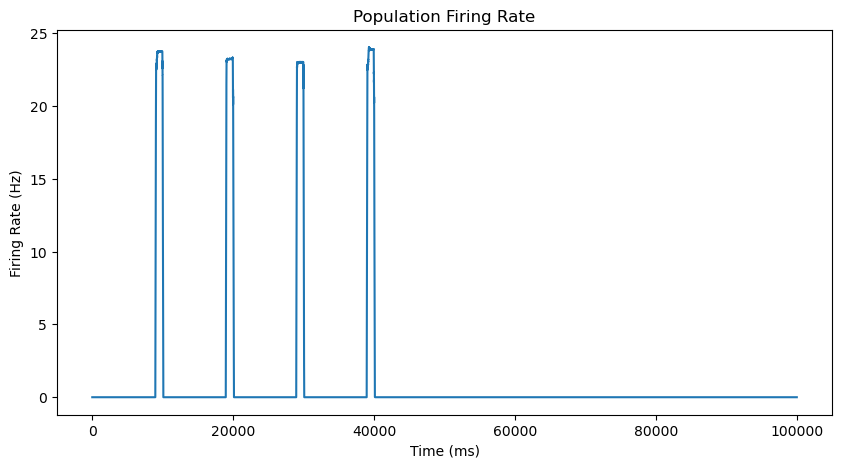

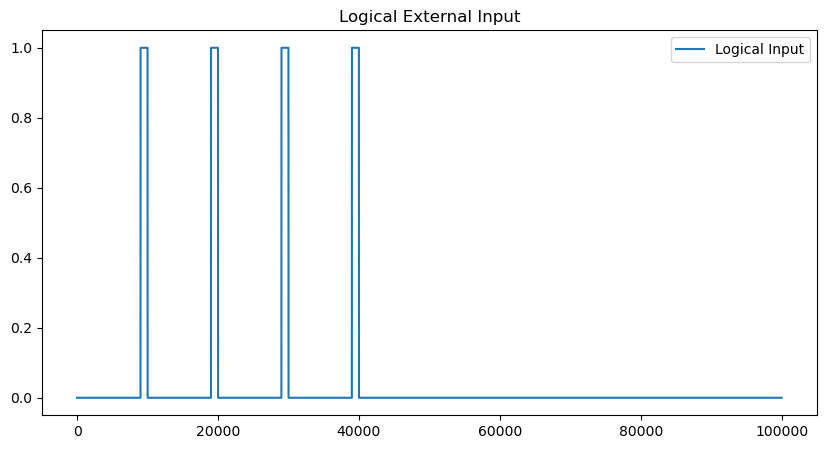

Results for m2_fasted:


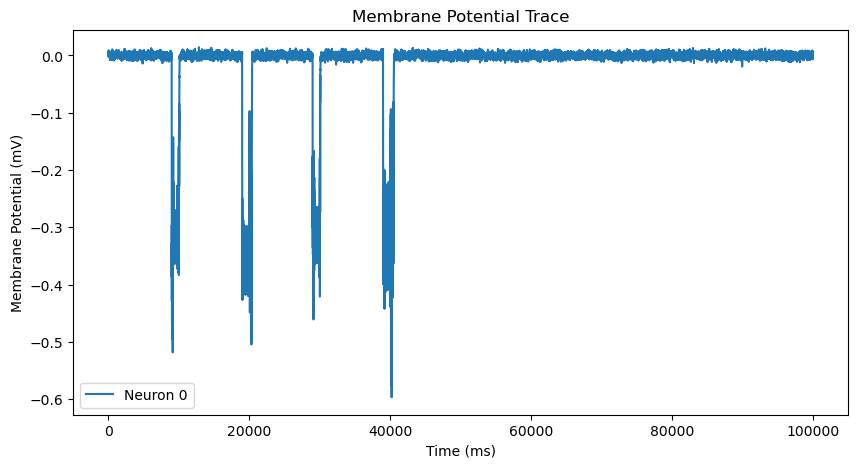

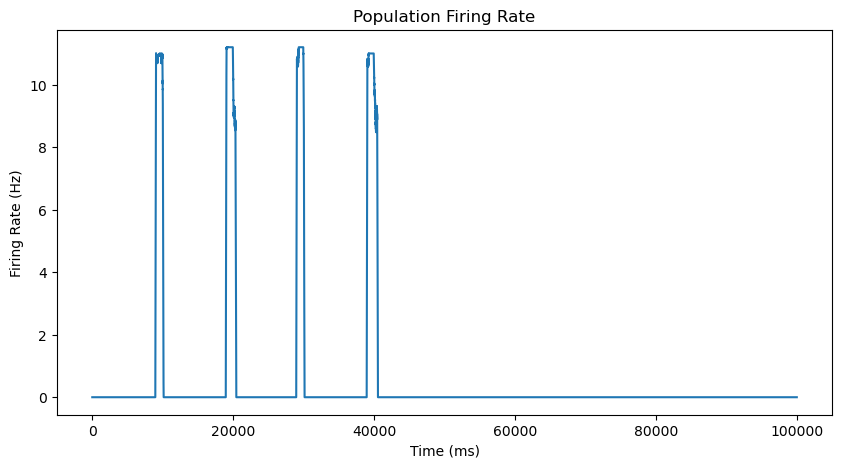

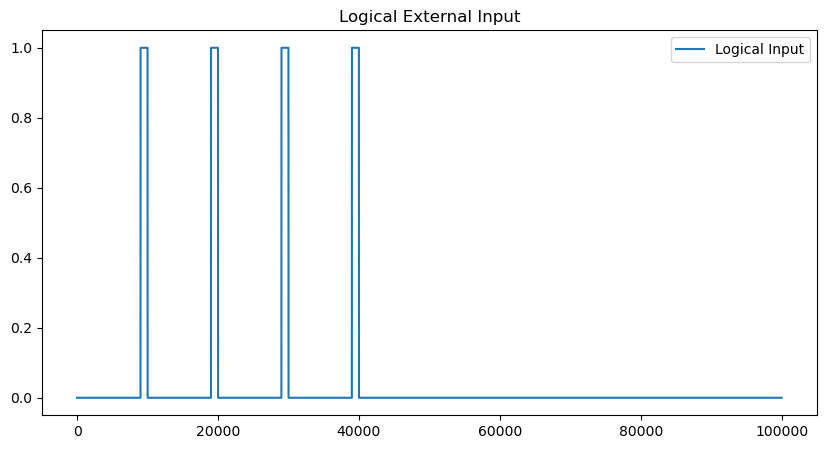

Results for m3_fasted:


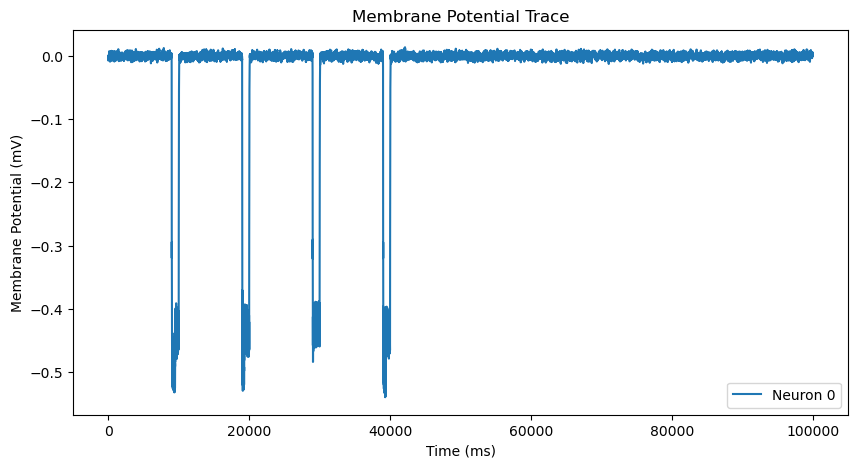

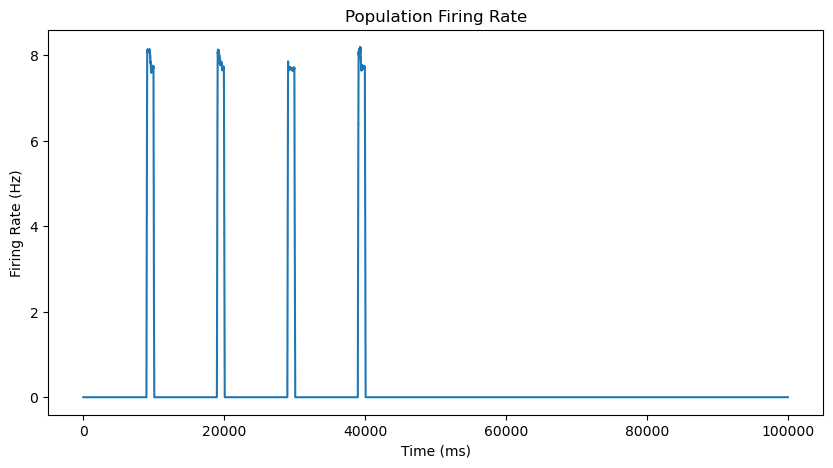

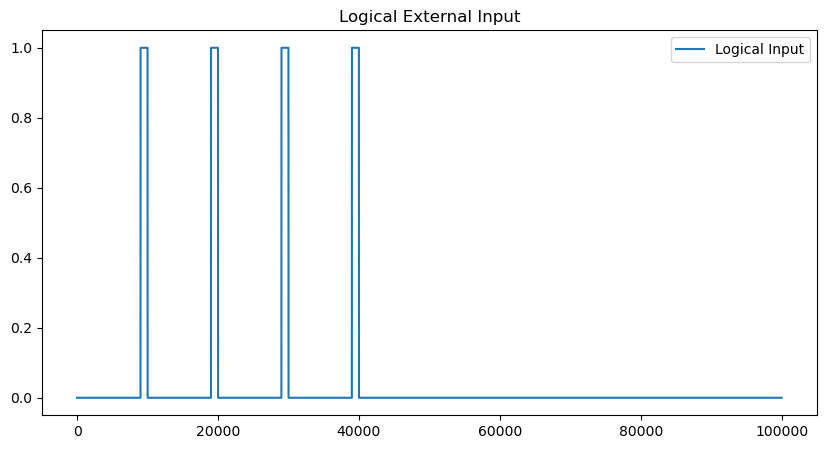

Results for m4_fasted:


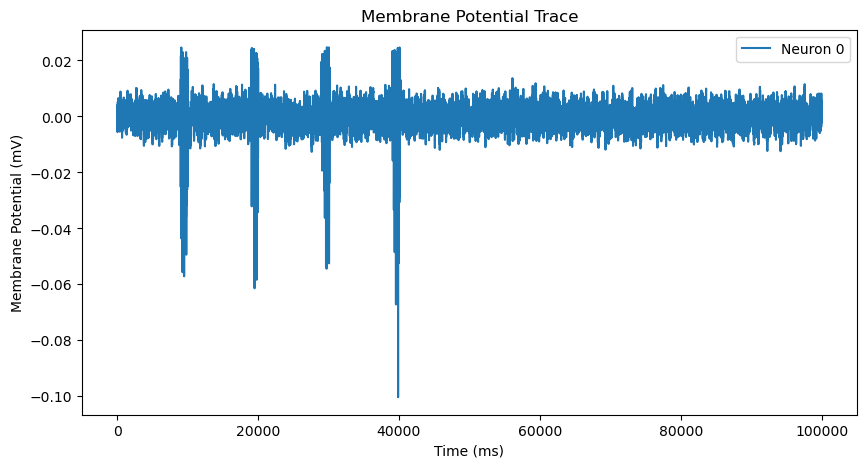

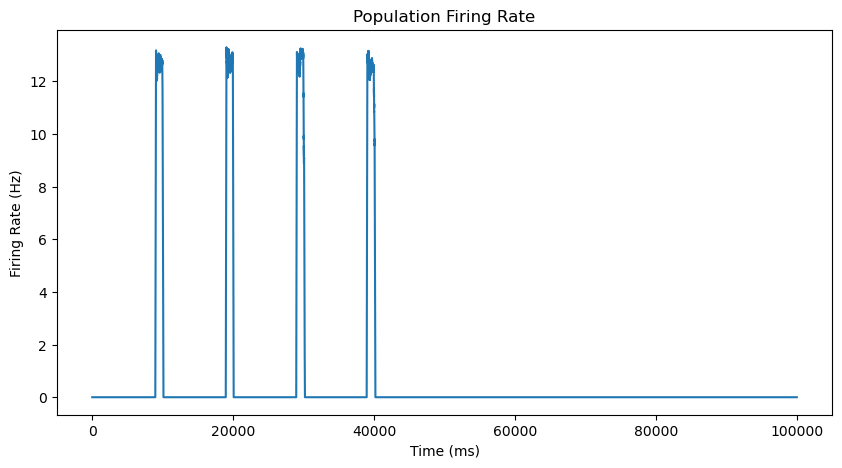

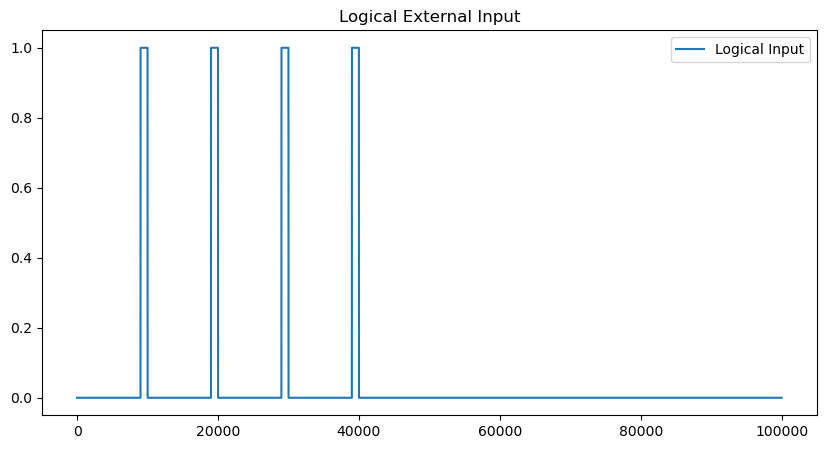

Results for m5_fasted:


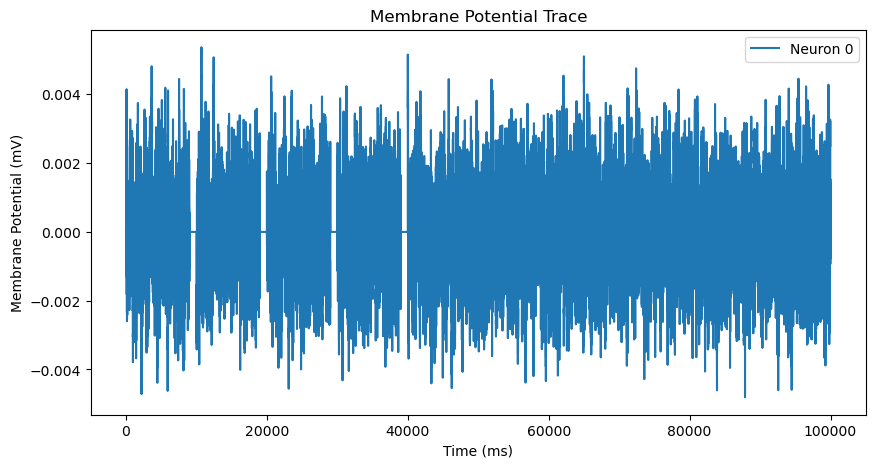

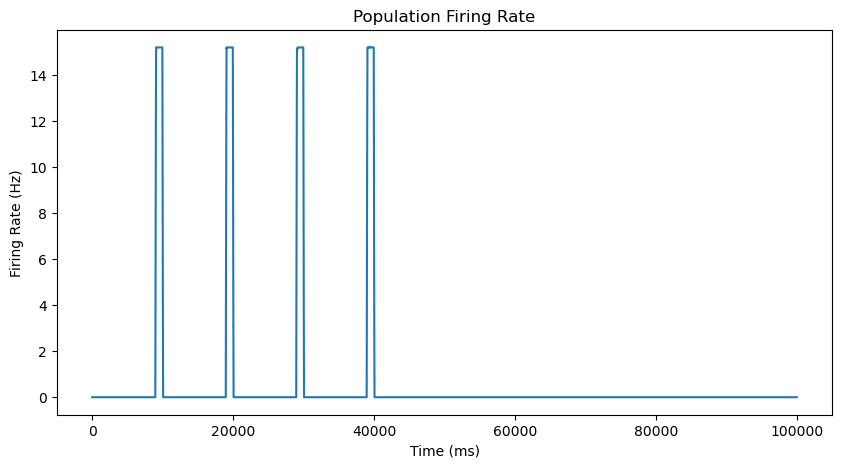

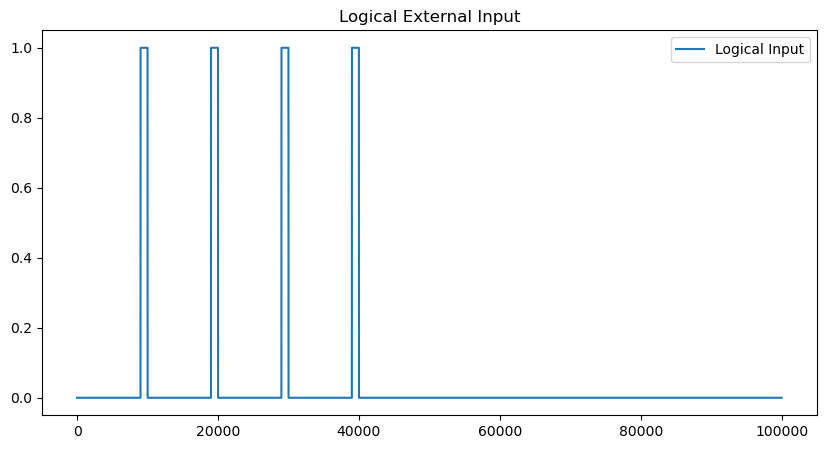

Results for m6_fasted:


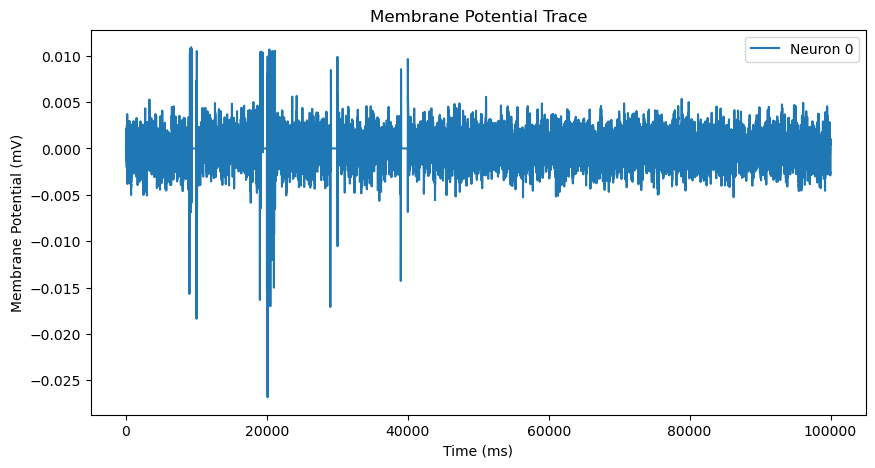

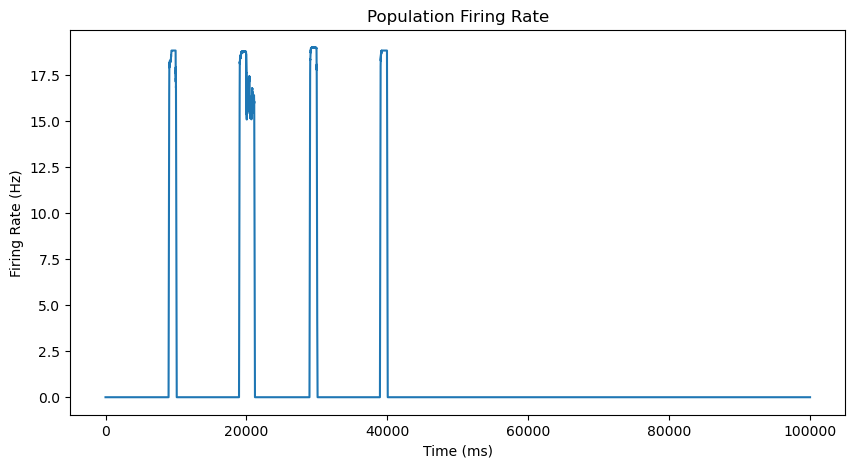

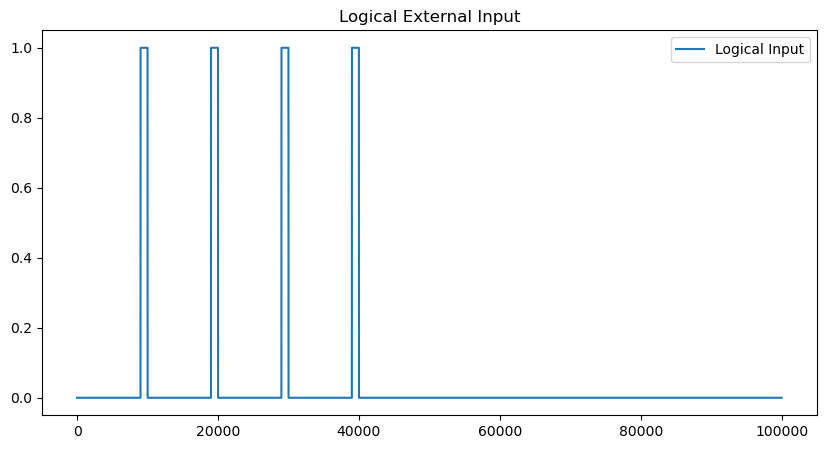

In [56]:
for key, W in connectivity_matrices_fasted.items():
    num_neurons = W.shape[0]
    num_targets = int(0.2 * num_neurons)
    targets = np.random.choice(num_neurons, num_targets, replace=False)

    # Define input
    input = {
        'type': 'logical',
        'pattern': pattern,
        'strength': 1,
        'targets': targets
    }

    V_th = np.mean(W)

    # Create an instance of the simulation class
    snn = SNN(W=W, tau_m=20.0, V_rest=0.0, V_th=V_th*1.2, V_reset=0.0, refractory_period=5.0, noise=V_th)
    snn.run(T=T, external_input=input)

    # Plot results for the current matrix
    print(f"Results for {key}:")
    # snn.plot_raster()
    snn.plot_trace([0])
    snn.plot_rate(window=100)
    snn.plot_input()